In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# [1] Cấu hình thư mục gốc 
DATA_DIR = "/Users/nguyenminhtri/FinalYearPro/data/raw"

# Nhóm Bảng chính (Main Tables)
MAIN_TRAIN_FILE = os.path.join(DATA_DIR, "application_train.csv")
MAIN_TEST_FILE  = os.path.join(DATA_DIR, "application_test.csv")

# Nhóm Luồng lịch sử BÊN NGOÀI Home Credit (Credit Bureau Stream)
BUREAU_FILE      = os.path.join(DATA_DIR, "bureau.csv")
BUREAU_BAL_FILE  = os.path.join(DATA_DIR, "bureau_balance.csv")

# Nhóm Luồng lịch sử BÊN TRONG Home Credit (Internal Behavioral Stream)
PREV_APP_FILE    = os.path.join(DATA_DIR, "previous_application.csv")
INS_PAYMENT_FILE = os.path.join(DATA_DIR, "installments_payments.csv")
POS_CASH_FILE    = os.path.join(DATA_DIR, "POS_CASH_balance.csv")
CREDIT_CARD_FILE = os.path.join(DATA_DIR, "credit_card_balance.csv")

# File phụ bổ sung thông tin mô tả
COL_DESC_FILE    = os.path.join(DATA_DIR, "HomeCredit_columns_description.csv")

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def eda_categorical_feature(df, column_name):
    """[QUY CHUẨN GV]: Phân tích Đơn biến chữ -> df.nunique() -> Bar + Pie"""
    if column_name not in df.columns: return
    
    # 🚨 TÍNH TOÁN VÀ HIỂN THỊ TỶ LỆ TRỐNG NGAY TẠI ĐÂY
    missing_count = df[column_name].isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    
    print(f"📊 [CATEGORICAL] Feature: {column_name} | Unique Groups: {df[column_name].nunique()}")
    print(f"⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: {missing_count:,} dòng | Tỷ lệ khuyết: {missing_pct:.2f}%")
    print("-" * 65)
    
    # 2. Output Bảng thống kê mô tả (Tần suất & Tỷ lệ %)
    counts = df[column_name].value_counts(dropna=False)
    pct = df[column_name].value_counts(dropna=False, normalize=True) * 100
    stats_df = pd.DataFrame({'Counts': counts, 'Percentage (%)': pct})
    
    stats_df.index = stats_df.index.map(lambda x: "Missing (Trống)" if pd.isna(x) else str(x))
    display(stats_df.apply(lambda s: s.apply('{:,.2f}'.format) if s.name == 'Percentage (%)' else s.apply('{:,}'.format)))
    
    plot_labels = counts.index.map(lambda x: "Missing" if pd.isna(x) else str(x))
    
    # 3. Output cặp biểu đồ Bar + Pie song song
    if df[column_name].nunique() > 10:
        plt.figure(figsize=(10, 5))
        sns.barplot(x=counts.values, y=plot_labels, hue=plot_labels, palette='viridis', legend=False)
        plt.title(f'Bar Chart: {column_name} (Missing: {missing_pct:.2f}%)')
        plt.xlabel('Counts')
        plt.tight_layout()
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        
        sns.barplot(x=plot_labels, y=counts.values, ax=axes[0], hue=plot_labels, palette='Set2', legend=False)
        axes[0].set_xticks(range(len(counts)))
        axes[0].set_xticklabels(plot_labels, rotation=30, ha='right')
        axes[0].set_title(f'Bar Chart: {column_name}')
        axes[0].set_ylabel('Counts')
        
        axes[1].pie(counts.values, labels=plot_labels, autopct='%1.1f%%', 
                    startangle=90, colors=sns.color_palette('Set2', len(counts)))
        axes[1].set_title(f'Pie Chart: {column_name} (Missing: {missing_pct:.2f}%)')
        plt.tight_layout()
        plt.show()

def eda_numerical_feature(df, column_name):
    """[QUY CHUẨN GV]: Phân tích Đơn biến số -> Descriptive Stats -> Hist + Box"""
    if column_name not in df.columns: return
    
    # 🚨 TÍNH TOÁN VÀ HIỂN THỊ TỶ LỆ TRỐNG
    missing_count = df[column_name].isnull().sum()
    missing_pct = (missing_count / len(df)) * 100
    
    print(f"📈 [NUMERICAL] Feature: {column_name}")
    print(f"⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: {missing_count:,} dòng | Tỷ lệ khuyết: {missing_pct:.2f}%")
    print("-" * 65)
    
    # 1. Tính toán các chỉ số thống kê mô tả
    desc = df[column_name].describe()
    mode_series = df[column_name].mode()
    mode_val = mode_series.iloc[0] if not mode_series.empty else np.nan
    iqr_val = desc['75%'] - desc['25%']
    
    stats_df = pd.DataFrame({
        column_name: [desc['count'], desc['mean'], desc['50%'], mode_val, desc['std'], desc['min'], desc['max'], iqr_val]},
        index=['Count (Số lượng dòng thực tế)', 'Mean (Trung bình)', 'Median (Trung vị)', 'Mode (Yếu vị)', 'Std Dev (Độ lệch chuẩn)', 'Min', 'Max', 'IQR (Tứ phân vị)']
    )
    
    # FIX LỖI PANDAS: Ép kiểu bảng copy sang 'object' để thoải mái nhận chuỗi định dạng (String) mà không bị lỗi dtype
    formatted_df = stats_df.copy().astype(object)
    
    for idx in formatted_df.index:
        val = stats_df.loc[idx, column_name]  # Lấy giá trị gốc từ stats_df để tính toán chuẩn xác
        if 'Count' in idx:
            formatted_df.loc[idx, column_name] = f"{int(val):,}"
        else:
            formatted_df.loc[idx, column_name] = f"{val:,.2f}" if not pd.isna(val) else "NaN"
            
    display(formatted_df)
    
    # 2. Output cặp biểu đồ Histogram + Boxplot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.histplot(df[column_name].dropna(), bins=40, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram: {column_name} (Missing: {missing_pct:.2f}%)')
    
    sns.boxplot(x=df[column_name].dropna(), ax=axes[1], color='salmon')
    axes[1].set_title(f'Boxplot: {column_name}')
    plt.tight_layout()
    plt.show()

In [62]:
df_main = pd.read_csv(MAIN_TRAIN_FILE)

print(f"✅ Đã nạp thành công bảng chính application_train.csv vào bộ nhớ!")
print(f"   Kích thước dữ liệu thô: {df_main.shape[0]:,} dòng | {df_main.shape[1]} cột.")


✅ Đã nạp thành công bảng chính application_train.csv vào bộ nhớ!
   Kích thước dữ liệu thô: 307,511 dòng | 122 cột.


📊 [CATEGORICAL] Feature: TARGET | Unique Groups: 2
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
TARGET,,
0,"282,686",91.93
1,"24,825",8.07


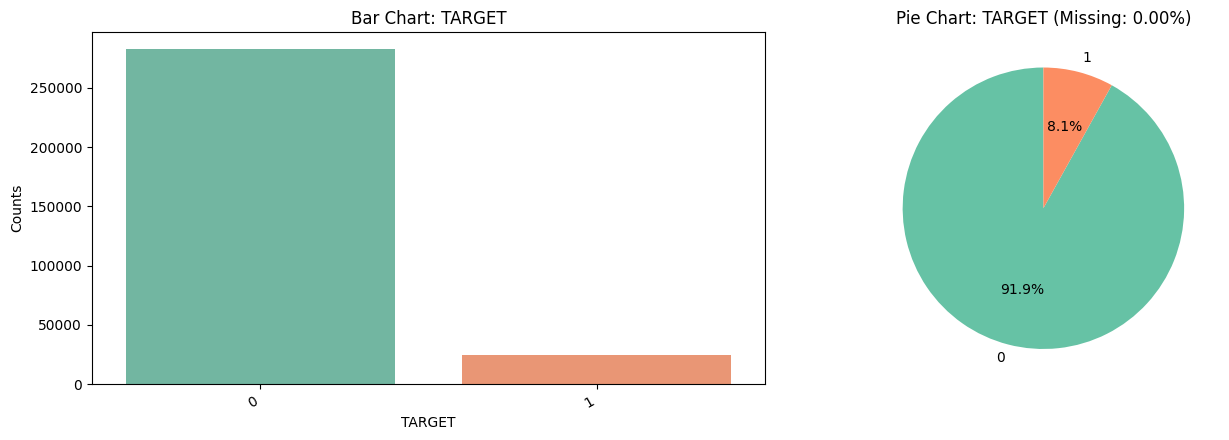

In [20]:
eda_categorical_feature(df_main, 'TARGET')

📊 [CATEGORICAL] Feature: CODE_GENDER | Unique Groups: 3
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
CODE_GENDER,,
F,"202,448",65.83
M,"105,059",34.16
XNA,4,0.00


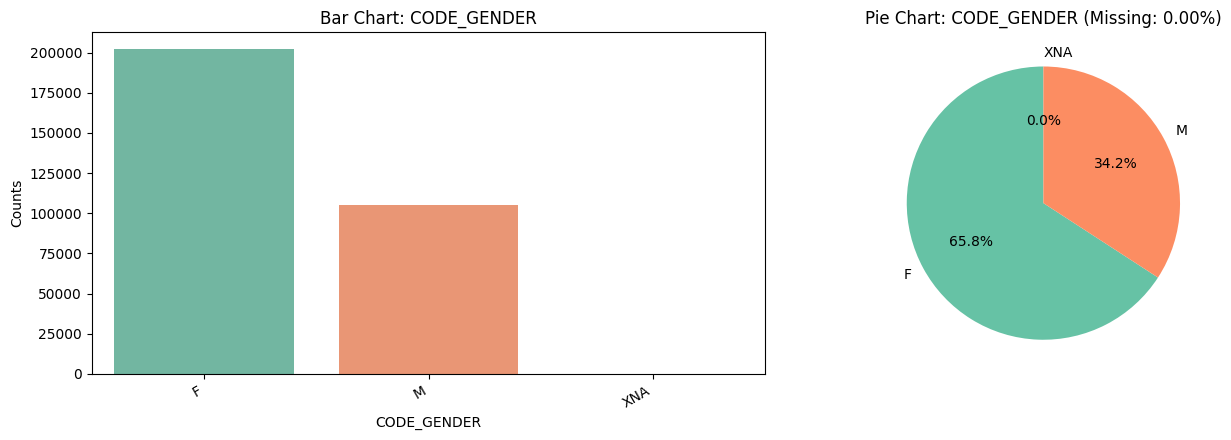

In [21]:
eda_categorical_feature(df_main, 'CODE_GENDER')

📈 [NUMERICAL] Feature: CNT_CHILDREN
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,CNT_CHILDREN
Count (Số lượng dòng thực tế),"307,511"
Mean (Trung bình),0.42
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.72
Min,0.00
Max,19.00
IQR (Tứ phân vị),1.00


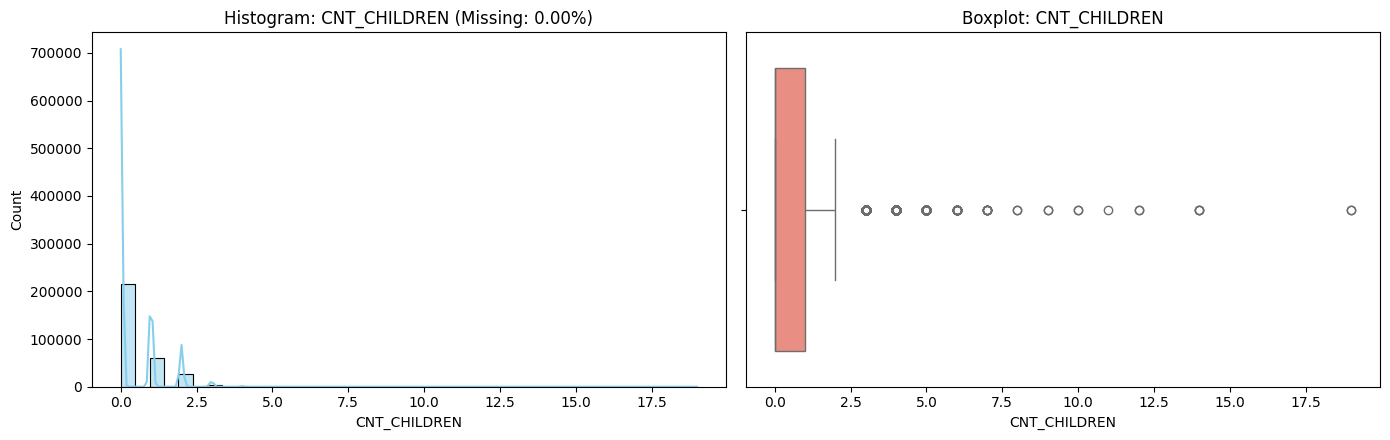

In [25]:
eda_numerical_feature(df_main, 'CNT_CHILDREN')


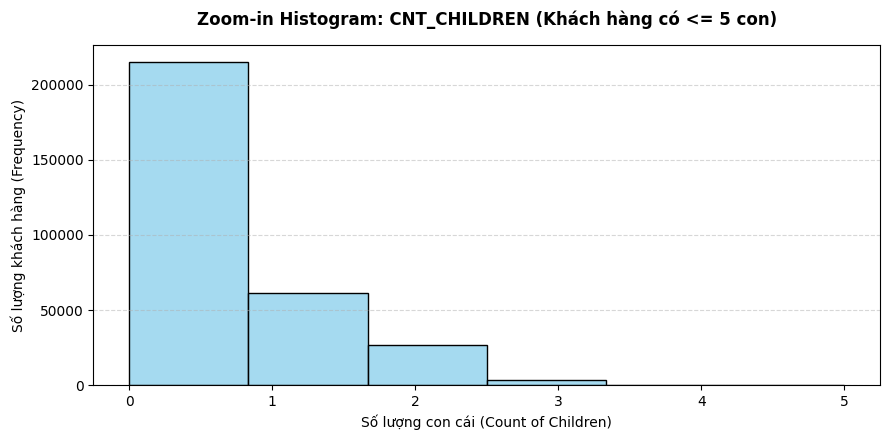

In [29]:


# Biểu đồ phụ: Phân tích cận cảnh (Zoom-in) chỉ nhìn rõ phân phối số lượng con cái thực tế
plt.figure(figsize=(9, 4.5))

# Lọc nhanh các hộ gia đình có từ 5 con trở xuống để loại bỏ nhiễu dị biệt (11, 19 con) khi xem phân phối
normal_children = df_main[df_main['CNT_CHILDREN'] <= 5]['CNT_CHILDREN']

# Vẽ Histogram đơn lẻ (Không kèm Boxplot) bằng cách cấu hình số bins bằng đúng số nhóm dữ liệu
sns.histplot(normal_children, bins=6, kde=False, color='skyblue', edgecolor='black')

# Định dạng đồ thị chuyên nghiệp cho đồ án
plt.title('Zoom-in Histogram: CNT_CHILDREN (Khách hàng có <= 5 con)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số lượng con cái (Count of Children)', fontsize=10)
plt.ylabel('Số lượng khách hàng (Frequency)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_INCOME_TOTAL
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_INCOME_TOTAL
Count (Số lượng dòng thực tế),"307,511"
Mean (Trung bình),"168,797.92"
Median (Trung vị),"147,150.00"
Mode (Yếu vị),"135,000.00"
Std Dev (Độ lệch chuẩn),"237,123.15"
Min,"25,650.00"
Max,"117,000,000.00"
IQR (Tứ phân vị),"90,000.00"


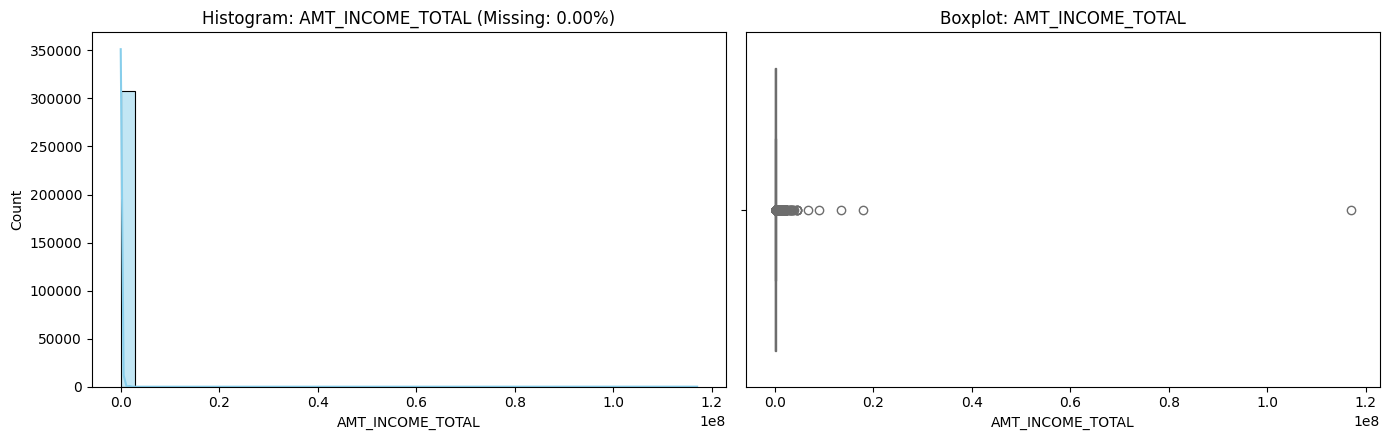

In [27]:
eda_numerical_feature(df_main, 'AMT_INCOME_TOTAL')


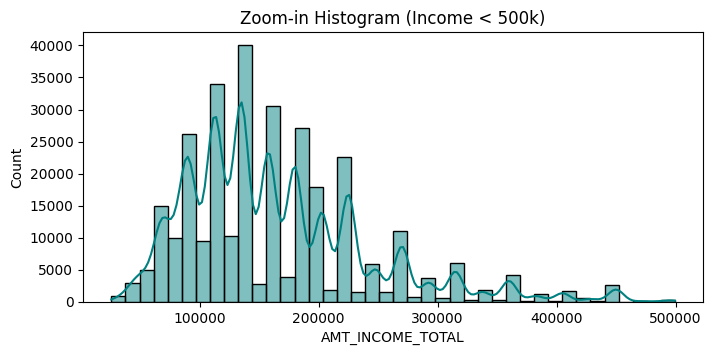

In [28]:
# Code zoom-in lọc bỏ tạm thời siêu ngoại lai để nhìn rõ đường cong phân phối
normal_data = df_main[df_main['AMT_INCOME_TOTAL'] < 500000]['AMT_INCOME_TOTAL']
plt.figure(figsize=(8, 3.5))
sns.histplot(normal_data, bins=40, kde=True, color='teal')
plt.title('Zoom-in Histogram (Income < 500k)')
plt.show()


📈 [NUMERICAL] Feature: AMT_CREDIT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_CREDIT
Count (Số lượng dòng thực tế),"307,511"
Mean (Trung bình),"599,026.00"
Median (Trung vị),"513,531.00"
Mode (Yếu vị),"450,000.00"
Std Dev (Độ lệch chuẩn),"402,490.78"
Min,"45,000.00"
Max,"4,050,000.00"
IQR (Tứ phân vị),"538,650.00"


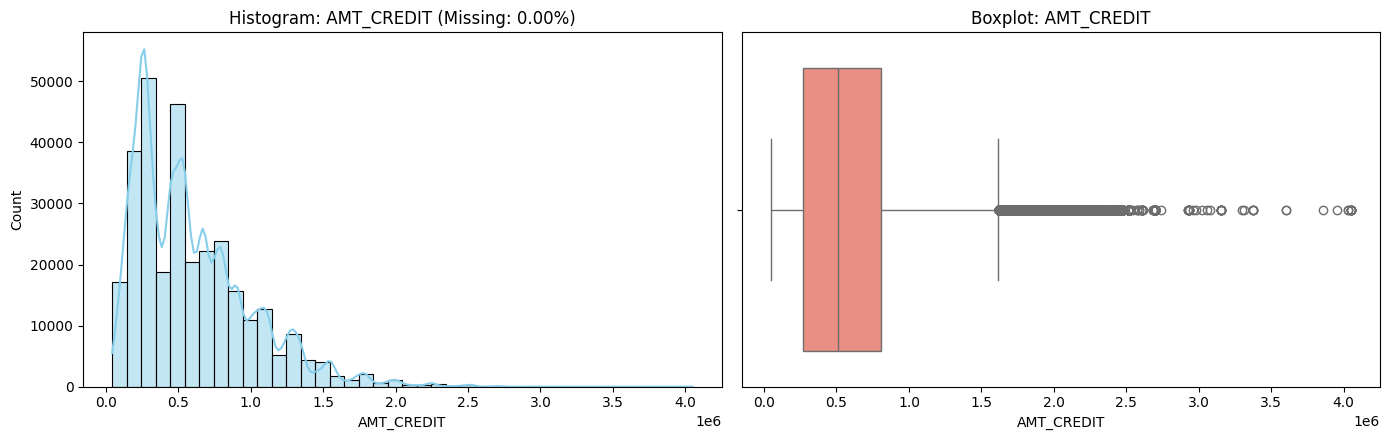

In [30]:
eda_numerical_feature(df_main, 'AMT_CREDIT')


📈 [NUMERICAL] Feature: AMT_ANNUITY
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 12 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_ANNUITY
Count (Số lượng dòng thực tế),"307,499"
Mean (Trung bình),"27,108.57"
Median (Trung vị),"24,903.00"
Mode (Yếu vị),"9,000.00"
Std Dev (Độ lệch chuẩn),"14,493.74"
Min,"1,615.50"
Max,"258,025.50"
IQR (Tứ phân vị),"18,072.00"


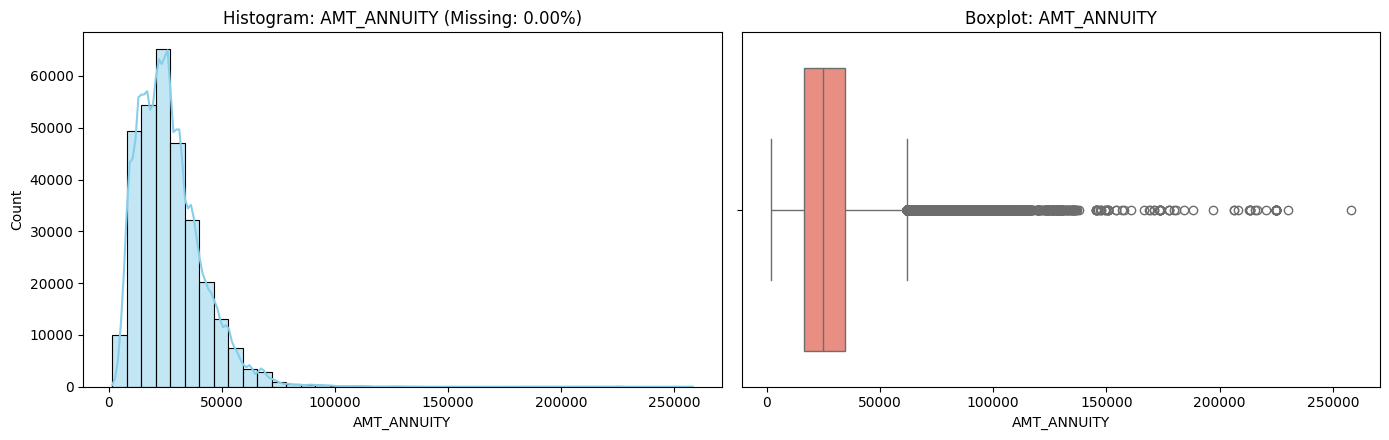

In [31]:
eda_numerical_feature(df_main, 'AMT_ANNUITY')


📈 [NUMERICAL] Feature: AMT_GOODS_PRICE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 278 dòng | Tỷ lệ khuyết: 0.09%
-----------------------------------------------------------------


,AMT_GOODS_PRICE
Count (Số lượng dòng thực tế),"307,233"
Mean (Trung bình),"538,396.21"
Median (Trung vị),"450,000.00"
Mode (Yếu vị),"450,000.00"
Std Dev (Độ lệch chuẩn),"369,446.46"
Min,"40,500.00"
Max,"4,050,000.00"
IQR (Tứ phân vị),"441,000.00"


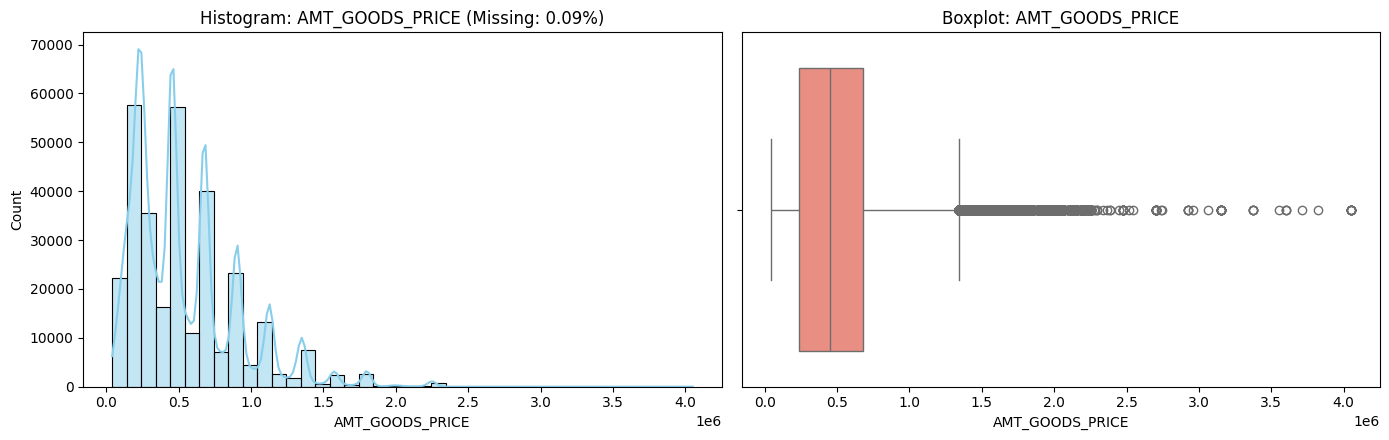

In [32]:
eda_numerical_feature(df_main, 'AMT_GOODS_PRICE')


📊 [CATEGORICAL] Feature: NAME_INCOME_TYPE | Unique Groups: 8
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
NAME_INCOME_TYPE,,
Working,"158,774",51.63
Commercial associate,"71,617",23.29
Pensioner,"55,362",18.00
State servant,"21,703",7.06
Unemployed,22,0.01
Student,18,0.01
Businessman,10,0.00
Maternity leave,5,0.00


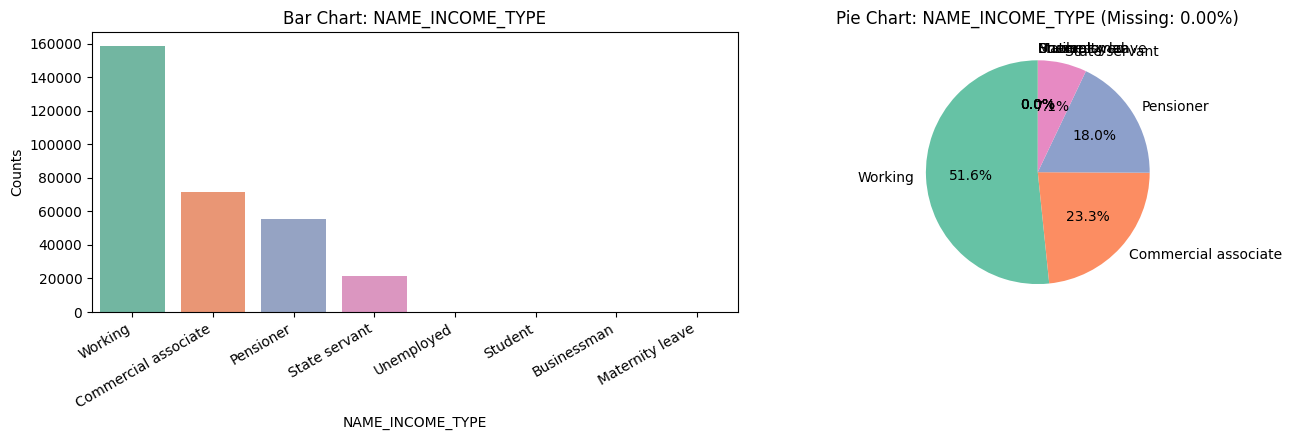

In [33]:
eda_categorical_feature(df_main, 'NAME_INCOME_TYPE')

📊 [CATEGORICAL] Feature: NAME_EDUCATION_TYPE | Unique Groups: 5
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
NAME_EDUCATION_TYPE,,
Secondary / secondary special,"218,391",71.02
Higher education,"74,863",24.34
Incomplete higher,"10,277",3.34
Lower secondary,"3,816",1.24
Academic degree,164,0.05


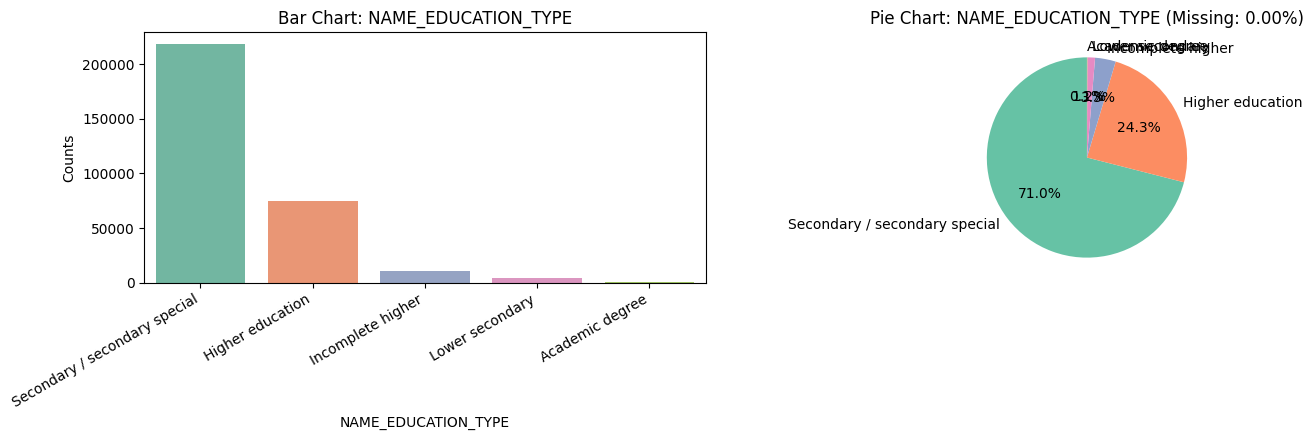

In [34]:
eda_categorical_feature(df_main, 'NAME_EDUCATION_TYPE')

📊 [CATEGORICAL] Feature: NAME_FAMILY_STATUS | Unique Groups: 6
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
NAME_FAMILY_STATUS,,
Married,"196,432",63.88
Single / not married,"45,444",14.78
Civil marriage,"29,775",9.68
Separated,"19,770",6.43
Widow,"16,088",5.23
Unknown,2,0.00


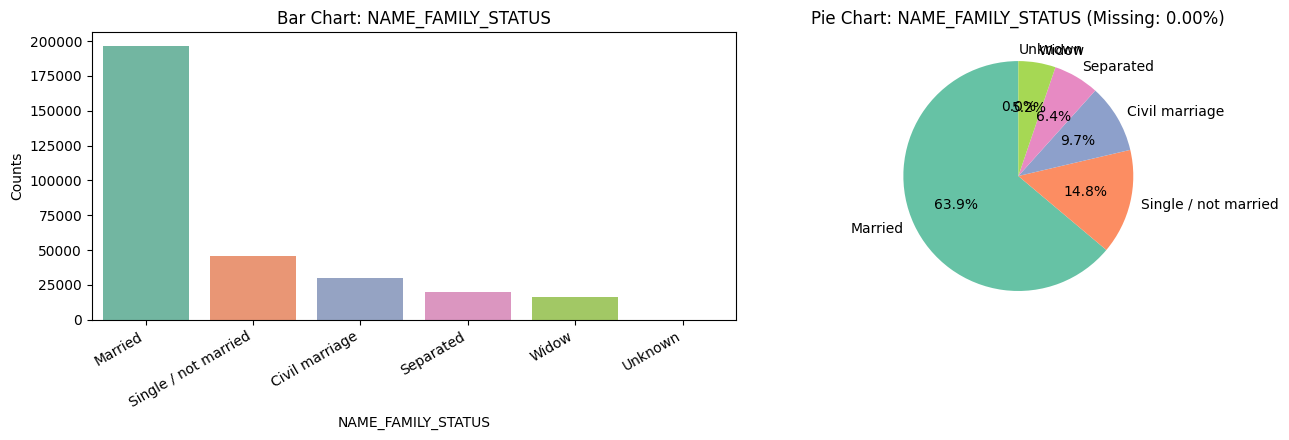

In [35]:
eda_categorical_feature(df_main, 'NAME_FAMILY_STATUS')

📈 [NUMERICAL] Feature: DAYS_BIRTH
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,DAYS_BIRTH
Count (Số lượng dòng thực tế),"307,511"
Mean (Trung bình),"-16,037.00"
Median (Trung vị),"-15,750.00"
Mode (Yếu vị),"-13,749.00"
Std Dev (Độ lệch chuẩn),"4,363.99"
Min,"-25,229.00"
Max,"-7,489.00"
IQR (Tứ phân vị),"7,269.00"


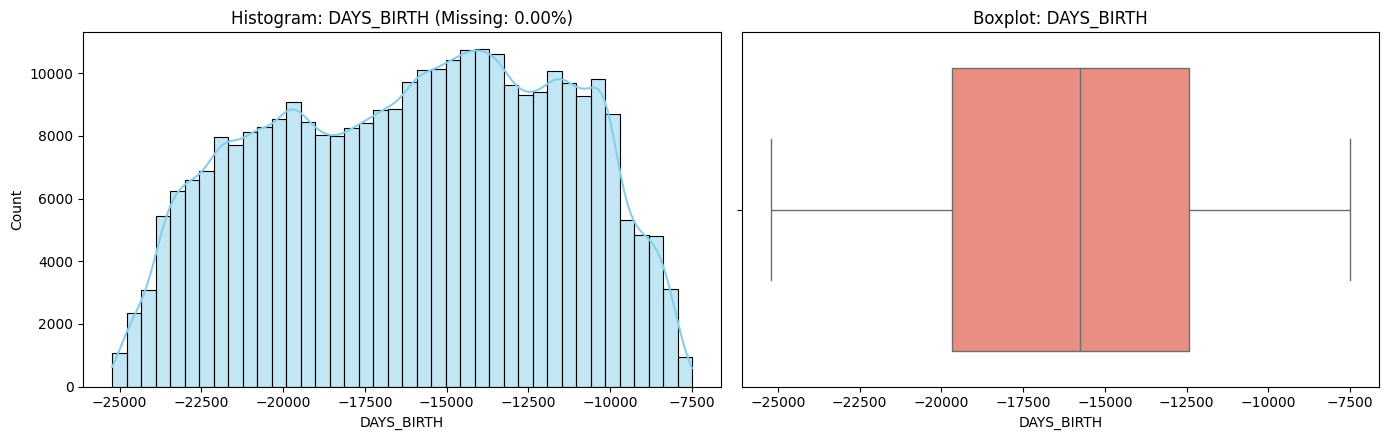

In [36]:
eda_numerical_feature(df_main, 'DAYS_BIRTH')


📈 [NUMERICAL] Feature: DAYS_EMPLOYED
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,DAYS_EMPLOYED
Count (Số lượng dòng thực tế),"307,511"
Mean (Trung bình),"63,815.05"
Median (Trung vị),"-1,213.00"
Mode (Yếu vị),"365,243.00"
Std Dev (Độ lệch chuẩn),"141,275.77"
Min,"-17,912.00"
Max,"365,243.00"
IQR (Tứ phân vị),"2,471.00"


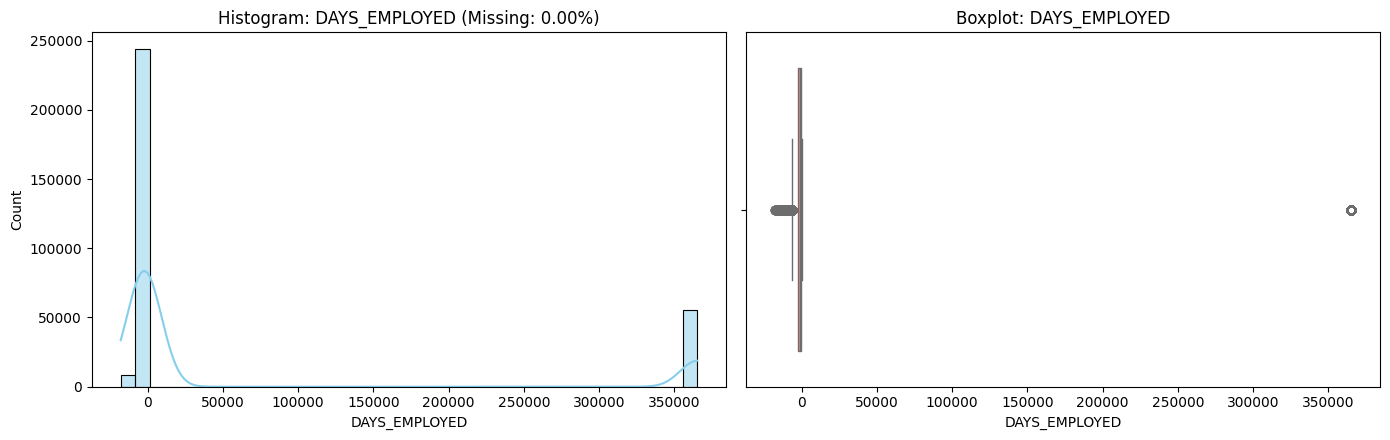

In [37]:
eda_numerical_feature(df_main, 'DAYS_EMPLOYED')


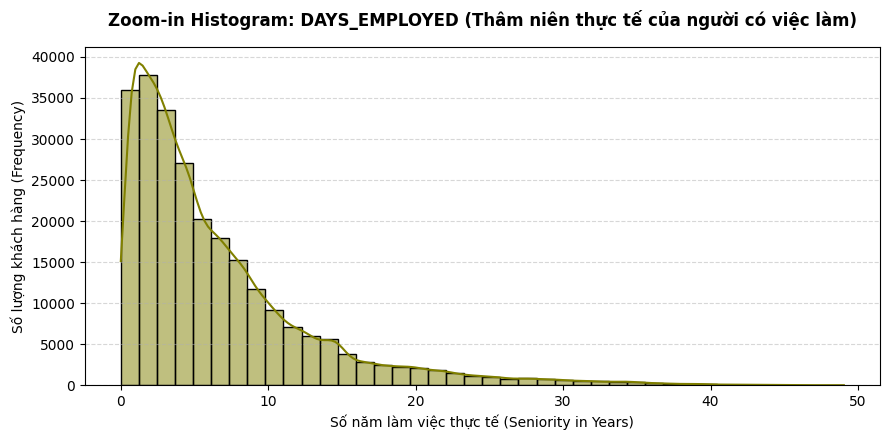

In [38]:


# Biểu đồ phụ: Lọc bỏ giá trị rác 365243 và quy đổi sang Số năm thâm niên thực tế
plt.figure(figsize=(9, 4.5))

# 1. Lọc bỏ hoàn toàn giá trị rác 365243 kỹ thuật
working_people = df_main[df_main['DAYS_EMPLOYED'] != 365243]['DAYS_EMPLOYED']

# 2. Quy đổi số ngày âm thành số năm dương thực tế
seniority_years = working_people.abs() / 365.25

# 3. Vẽ biểu đồ Histogram cận cảnh với đường cong mật độ KDE
sns.histplot(seniority_years, bins=40, kde=True, color='olive', edgecolor='black')

# Định dạng đồ thị chuẩn mực đồ án tốt nghiệp
plt.title('Zoom-in Histogram: DAYS_EMPLOYED (Thâm niên thực tế của người có việc làm)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số năm làm việc thực tế (Seniority in Years)', fontsize=10)
plt.ylabel('Số lượng khách hàng (Frequency)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

📊 [CATEGORICAL] Feature: OCCUPATION_TYPE | Unique Groups: 18
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 96,391 dòng | Tỷ lệ khuyết: 31.35%
-----------------------------------------------------------------


,Counts,Percentage (%)
OCCUPATION_TYPE,,
Missing (Trống),"96,391",31.35
Laborers,"55,186",17.95
Sales staff,"32,102",10.44
Core staff,"27,570",8.97
Managers,"21,371",6.95
Drivers,"18,603",6.05
High skill tech staff,"11,380",3.70
Accountants,"9,813",3.19
Medicine staff,"8,537",2.78


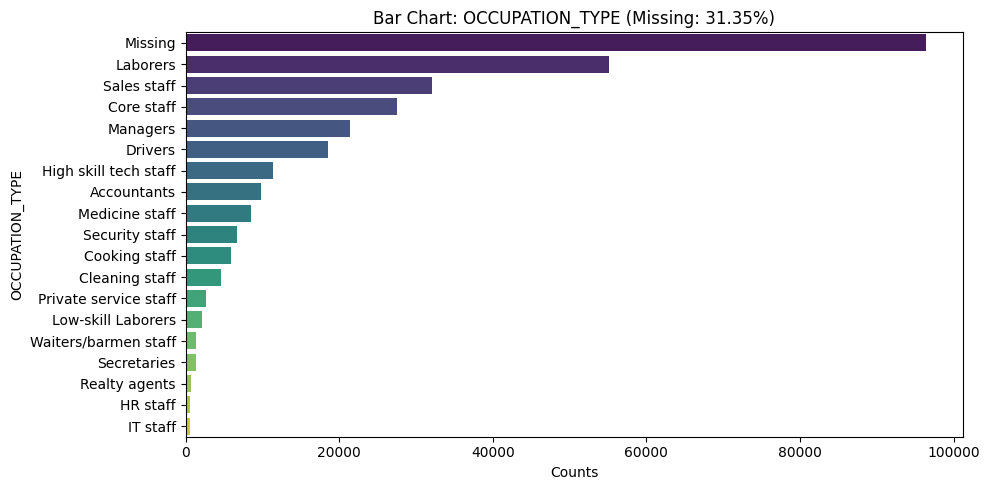

In [40]:
eda_categorical_feature(df_main, 'OCCUPATION_TYPE')

📈 [NUMERICAL] Feature: CNT_FAM_MEMBERS
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 2 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,CNT_FAM_MEMBERS
Count (Số lượng dòng thực tế),"307,509"
Mean (Trung bình),2.15
Median (Trung vị),2.00
Mode (Yếu vị),2.00
Std Dev (Độ lệch chuẩn),0.91
Min,1.00
Max,20.00
IQR (Tứ phân vị),1.00


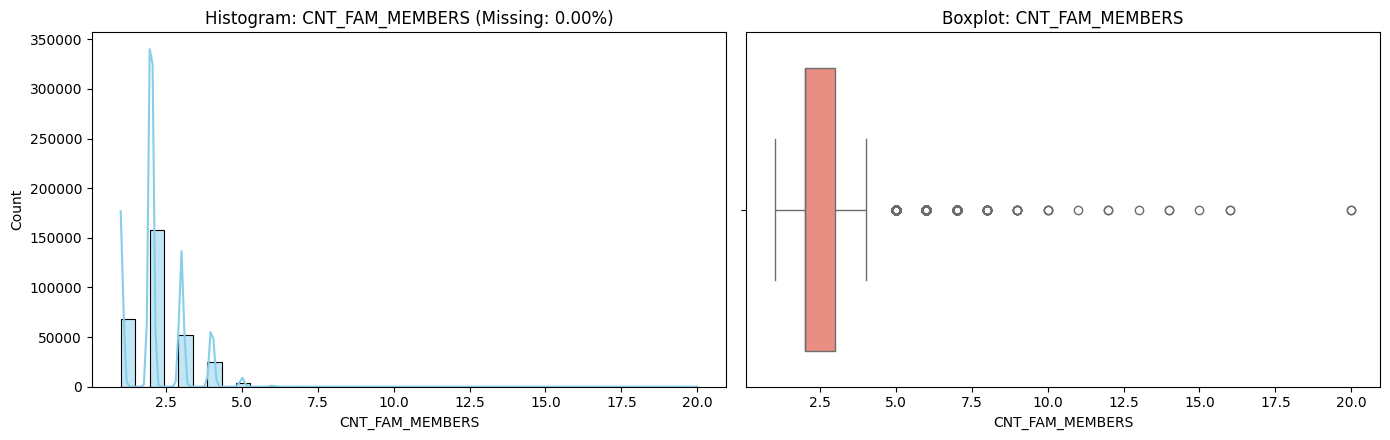

In [41]:
eda_numerical_feature(df_main, 'CNT_FAM_MEMBERS')


📊 [CATEGORICAL] Feature: ORGANIZATION_TYPE | Unique Groups: 58
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
ORGANIZATION_TYPE,,
Business Entity Type 3,"67,992",22.11
XNA,"55,374",18.01
Self-employed,"38,412",12.49
Other,"16,683",5.43
Medicine,"11,193",3.64
Business Entity Type 2,"10,553",3.43
Government,"10,404",3.38
School,"8,893",2.89
Trade: type 7,"7,831",2.55


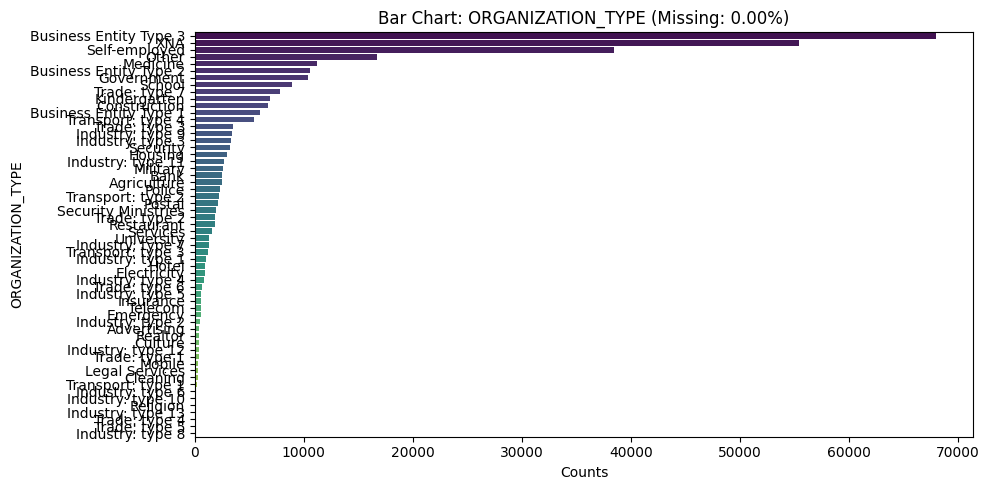

In [42]:
eda_categorical_feature(df_main, 'ORGANIZATION_TYPE')

📈 [NUMERICAL] Feature: EXT_SOURCE_1
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 173,378 dòng | Tỷ lệ khuyết: 56.38%
-----------------------------------------------------------------


,EXT_SOURCE_1
Count (Số lượng dòng thực tế),"134,133"
Mean (Trung bình),0.50
Median (Trung vị),0.51
Mode (Yếu vị),0.36
Std Dev (Độ lệch chuẩn),0.21
Min,0.01
Max,0.96
IQR (Tứ phân vị),0.34


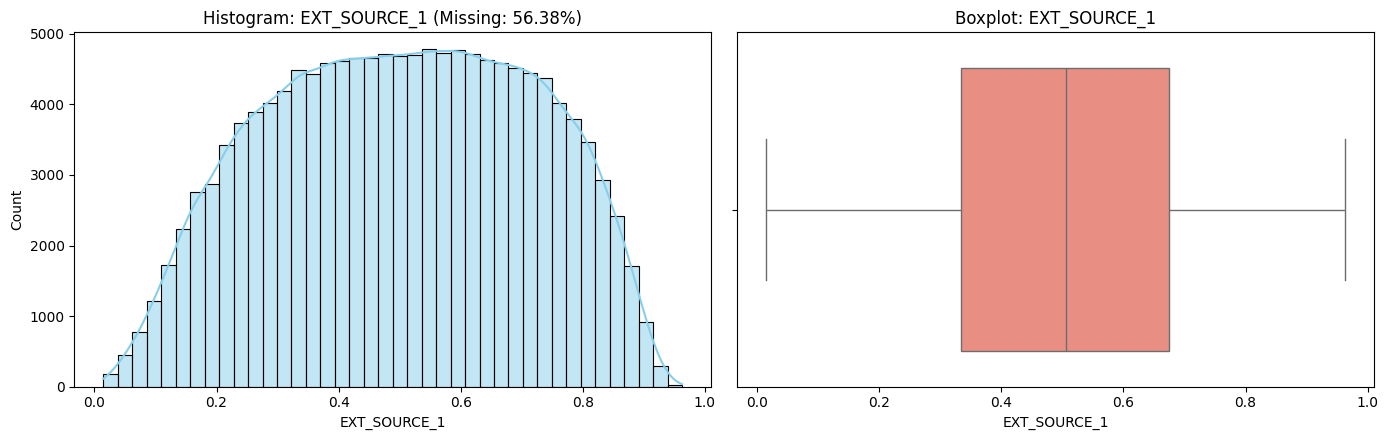

In [43]:
eda_numerical_feature(df_main, 'EXT_SOURCE_1')


📈 [NUMERICAL] Feature: EXT_SOURCE_2
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 660 dòng | Tỷ lệ khuyết: 0.21%
-----------------------------------------------------------------


,EXT_SOURCE_2
Count (Số lượng dòng thực tế),"306,851"
Mean (Trung bình),0.51
Median (Trung vị),0.57
Mode (Yếu vị),0.29
Std Dev (Độ lệch chuẩn),0.19
Min,0.00
Max,0.85
IQR (Tứ phân vị),0.27


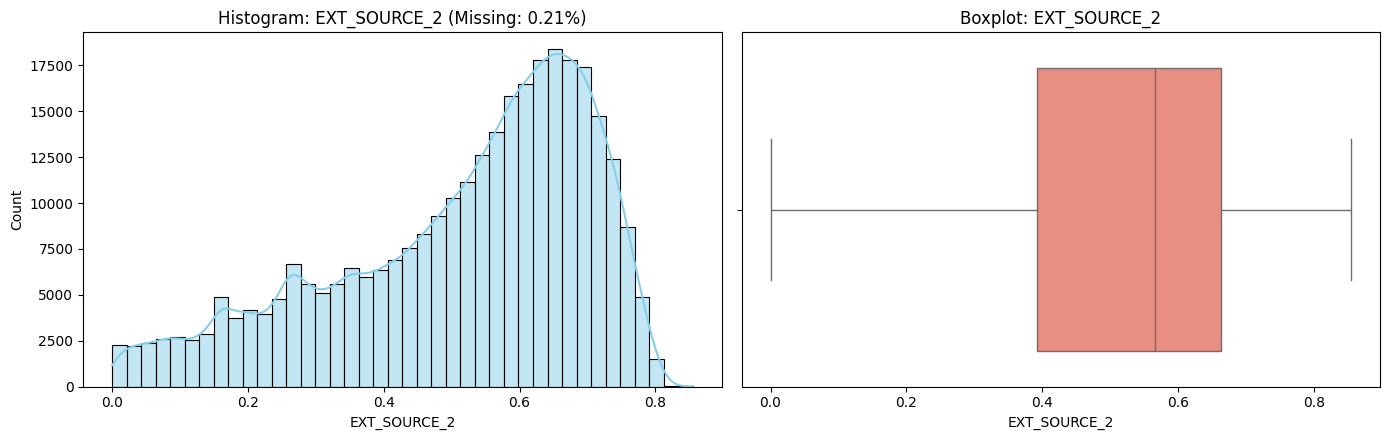

In [44]:
eda_numerical_feature(df_main, 'EXT_SOURCE_2')


📈 [NUMERICAL] Feature: EXT_SOURCE_3
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 60,965 dòng | Tỷ lệ khuyết: 19.83%
-----------------------------------------------------------------


,EXT_SOURCE_3
Count (Số lượng dòng thực tế),"246,546"
Mean (Trung bình),0.51
Median (Trung vị),0.54
Mode (Yếu vị),0.75
Std Dev (Độ lệch chuẩn),0.19
Min,0.00
Max,0.90
IQR (Tứ phân vị),0.30


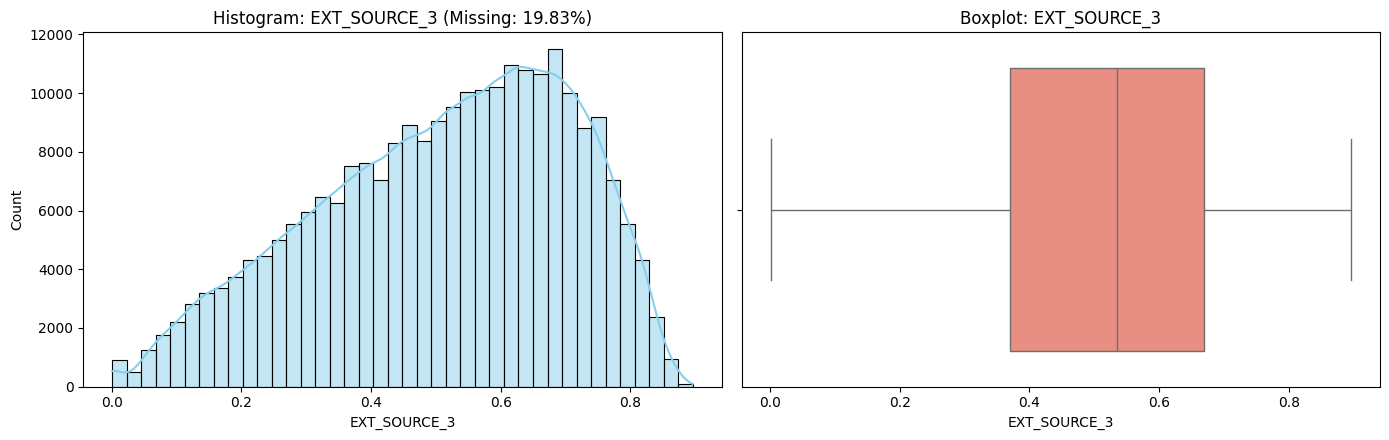

In [45]:
eda_numerical_feature(df_main, 'EXT_SOURCE_3')


📈 [NUMERICAL] Feature: EXT_SOURCE_3
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 60,965 dòng | Tỷ lệ khuyết: 19.83%
-----------------------------------------------------------------


,EXT_SOURCE_3
Count (Số lượng dòng thực tế),"246,546"
Mean (Trung bình),0.51
Median (Trung vị),0.54
Mode (Yếu vị),0.75
Std Dev (Độ lệch chuẩn),0.19
Min,0.00
Max,0.90
IQR (Tứ phân vị),0.30


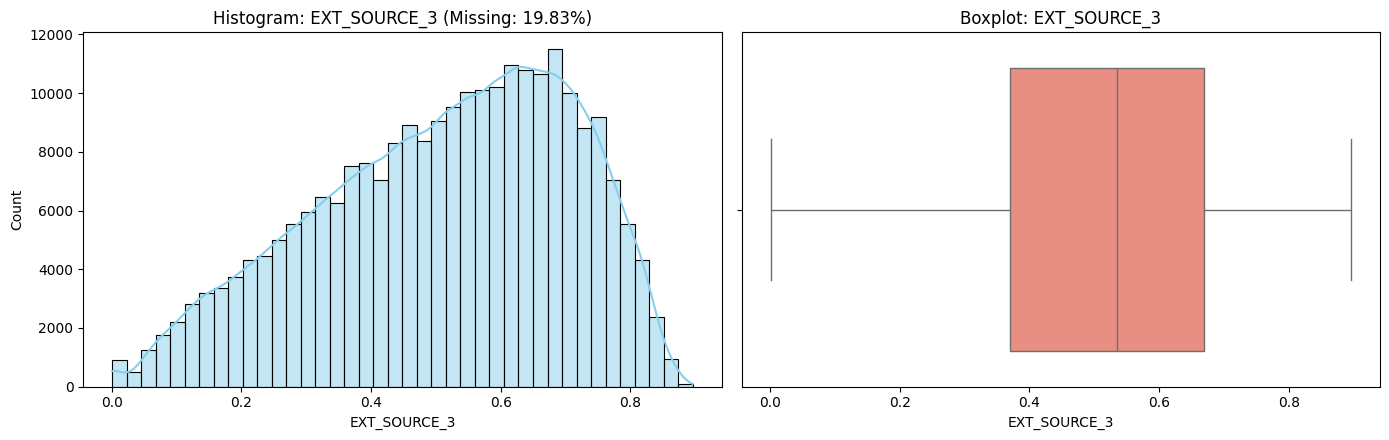

In [46]:
eda_numerical_feature(df_main, 'EXT_SOURCE_3')


📈 [NUMERICAL] Feature: OBS_30_CNT_SOCIAL_CIRCLE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,021 dòng | Tỷ lệ khuyết: 0.33%
-----------------------------------------------------------------


,OBS_30_CNT_SOCIAL_CIRCLE
Count (Số lượng dòng thực tế),"306,490"
Mean (Trung bình),1.42
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),2.40
Min,0.00
Max,348.00
IQR (Tứ phân vị),2.00


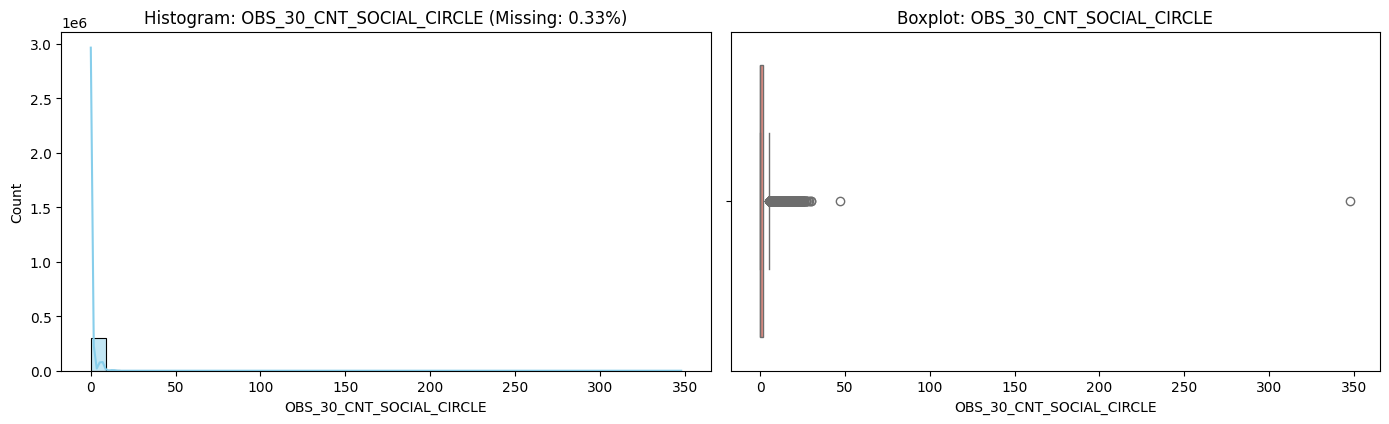

In [47]:
eda_numerical_feature(df_main, 'OBS_30_CNT_SOCIAL_CIRCLE')


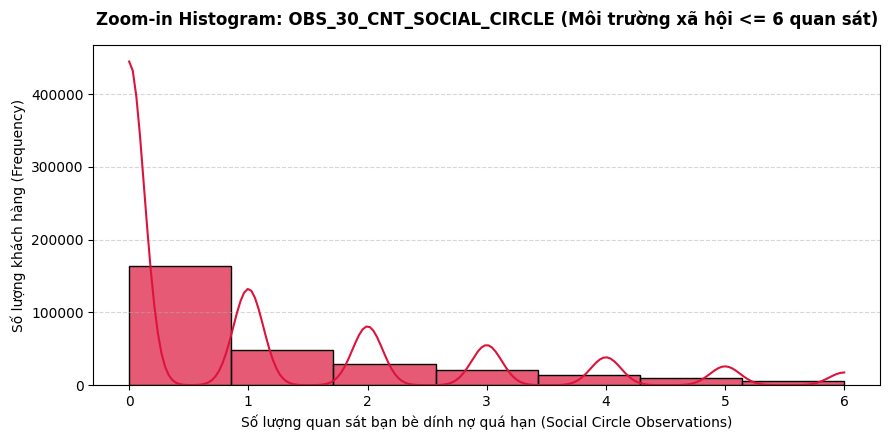

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ chuẩn cho báo cáo đồ án
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Áp dụng cẩm nang lọc dữ liệu sạch - chỉ lấy nhóm từ 6 quan sát trở xuống
# Đồng thời loại bỏ các dòng khuyết NaN để đường cong KDE không bị lỗi tính toán mật độ
clean_social = df_main[(df_main['OBS_30_CNT_SOCIAL_CIRCLE'] <= 6) & (df_main['OBS_30_CNT_SOCIAL_CIRCLE'].notna())]['OBS_30_CNT_SOCIAL_CIRCLE']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh với các tham số quy chuẩn
# bins=7 tương ứng cho 7 cột giá trị nguyên rời rạc từ 0, 1, 2, 3, 4, 5, đến 6
sns.histplot(clean_social, bins=7, kde=True, color='crimson', edgecolor='black', alpha=0.7)

# Cấu hình định dạng hiển thị trực quan chuyên nghiệp
plt.title('Zoom-in Histogram: OBS_30_CNT_SOCIAL_CIRCLE (Môi trường xã hội <= 6 quan sát)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số lượng quan sát bạn bè dính nợ quá hạn (Social Circle Observations)', fontsize=10)
plt.ylabel('Số lượng khách hàng (Frequency)', fontsize=10)

# Ép trục X hiển thị chính xác từng nấc số nguyên từ 0 đến 6 để người xem không bị nhầm lẫn
plt.xticks(range(7))

# Thêm lưới mờ theo trục ngang giúp Hội đồng dễ quan sát tương quan độ cao các cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: DEF_30_CNT_SOCIAL_CIRCLE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,021 dòng | Tỷ lệ khuyết: 0.33%
-----------------------------------------------------------------


,DEF_30_CNT_SOCIAL_CIRCLE
Count (Số lượng dòng thực tế),"306,490"
Mean (Trung bình),0.14
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.45
Min,0.00
Max,34.00
IQR (Tứ phân vị),0.00


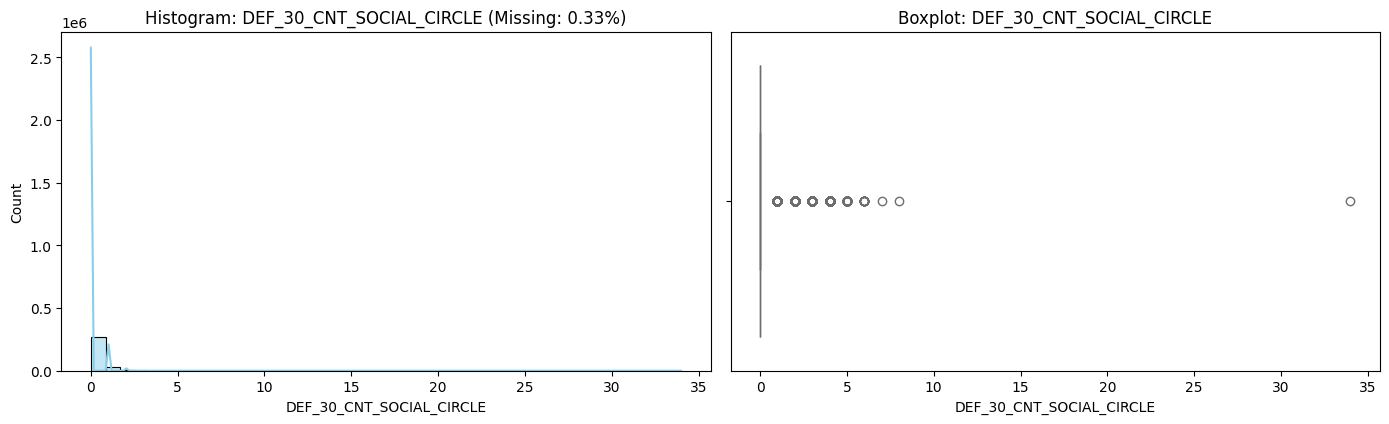

In [51]:
eda_numerical_feature(df_main, 'DEF_30_CNT_SOCIAL_CIRCLE')


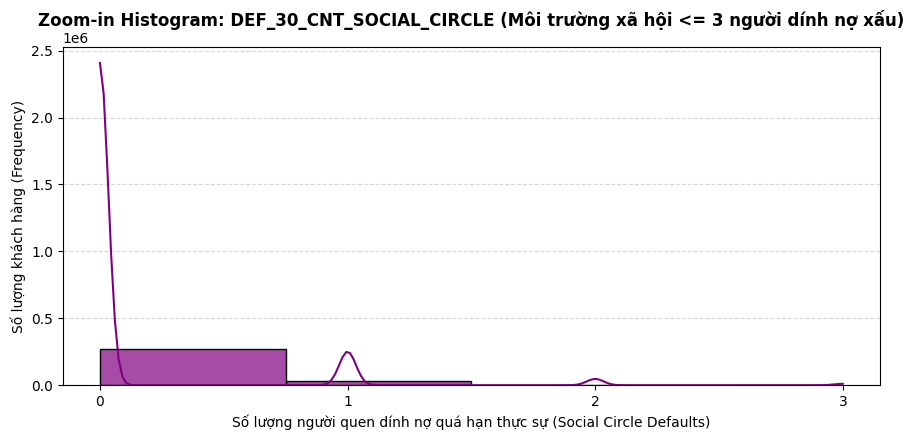

In [53]:

import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ chuẩn cho báo cáo đồ án
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Áp dụng cẩm nang lọc dữ liệu sạch - chỉ lấy nhóm từ 3 người dính nợ xấu trở xuống
# Loại bỏ các dòng khuyết NaN để đường cong KDE không bị lỗi tính toán mật độ thực tế
clean_def_social = df_main[(df_main['DEF_30_CNT_SOCIAL_CIRCLE'] <= 3) & (df_main['DEF_30_CNT_SOCIAL_CIRCLE'].notna())]['DEF_30_CNT_SOCIAL_CIRCLE']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh với các tham số quy chuẩn
# bins=4 tương ứng chính xác cho 4 nấc giá trị số nguyên rời rạc: 0, 1, 2, và 3
sns.histplot(clean_def_social, bins=4, kde=True, color='purple', edgecolor='black', alpha=0.7)

# Cấu hình định dạng hiển thị trực quan chuyên nghiệp
plt.title('Zoom-in Histogram: DEF_30_CNT_SOCIAL_CIRCLE (Môi trường xã hội <= 3 người dính nợ xấu)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số lượng người quen dính nợ quá hạn thực sự (Social Circle Defaults)', fontsize=10)
plt.ylabel('Số lượng khách hàng (Frequency)', fontsize=10)

# Ép trục X hiển thị chính xác từng nấc số nguyên từ 0 đến 3 để Hội đồng dễ đọc vị
plt.xticks(range(4))

# Thêm lưới mờ theo trục ngang giúp quan sát tương quan độ cao các cột rõ ràng hơn
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: OBS_60_CNT_SOCIAL_CIRCLE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,021 dòng | Tỷ lệ khuyết: 0.33%
-----------------------------------------------------------------


,OBS_60_CNT_SOCIAL_CIRCLE
Count (Số lượng dòng thực tế),"306,490"
Mean (Trung bình),1.41
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),2.38
Min,0.00
Max,344.00
IQR (Tứ phân vị),2.00


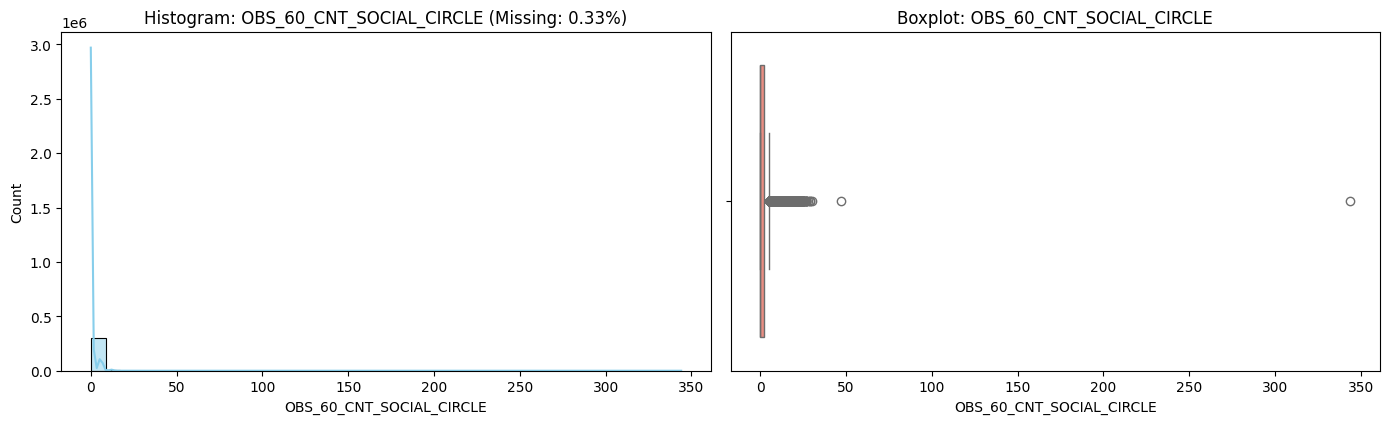

In [54]:
eda_numerical_feature(df_main, 'OBS_60_CNT_SOCIAL_CIRCLE')


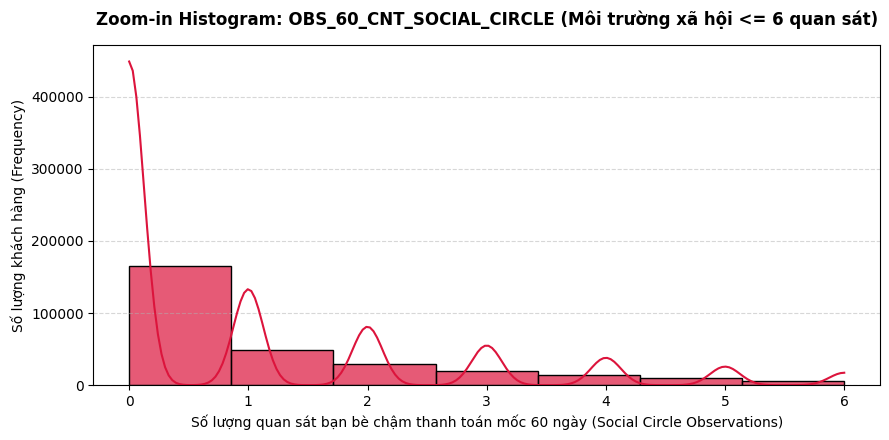

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ chuẩn cho đồ án
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Lọc dải dữ liệu sạch - giới hạn lấy từ 6 quan sát trở xuống cho biến OBS_60
# Loại bỏ các dòng khuyết NaN để đường cong mật độ KDE không bị lỗi hiển thị
clean_obs_60 = df_main[(df_main['OBS_60_CNT_SOCIAL_CIRCLE'] <= 6) & (df_main['OBS_60_CNT_SOCIAL_CIRCLE'].notna())]['OBS_60_CNT_SOCIAL_CIRCLE']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh
# bins=7 đại diện tương ứng cho 7 cột giá trị nguyên rời rạc từ 0 đến 6
sns.histplot(clean_obs_60, bins=7, kde=True, color='crimson', edgecolor='black', alpha=0.7)

# Định dạng hiển thị trực quan chuyên nghiệp để dán vào báo cáo
plt.title('Zoom-in Histogram: OBS_60_CNT_SOCIAL_CIRCLE (Môi trường xã hội <= 6 quan sát)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số lượng quan sát bạn bè chậm thanh toán mốc 60 ngày (Social Circle Observations)', fontsize=10)
plt.ylabel('Số lượng khách hàng (Frequency)', fontsize=10)

# Ép trục X hiển thị chính xác từng nấc số nguyên từ 0 đến 6
plt.xticks(range(7))

# Thêm lưới mờ giúp dễ đối chiếu tương quan độ cao các cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên và hiển thị
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: DEF_60_CNT_SOCIAL_CIRCLE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,021 dòng | Tỷ lệ khuyết: 0.33%
-----------------------------------------------------------------


,DEF_60_CNT_SOCIAL_CIRCLE
Count (Số lượng dòng thực tế),"306,490"
Mean (Trung bình),0.10
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.36
Min,0.00
Max,24.00
IQR (Tứ phân vị),0.00


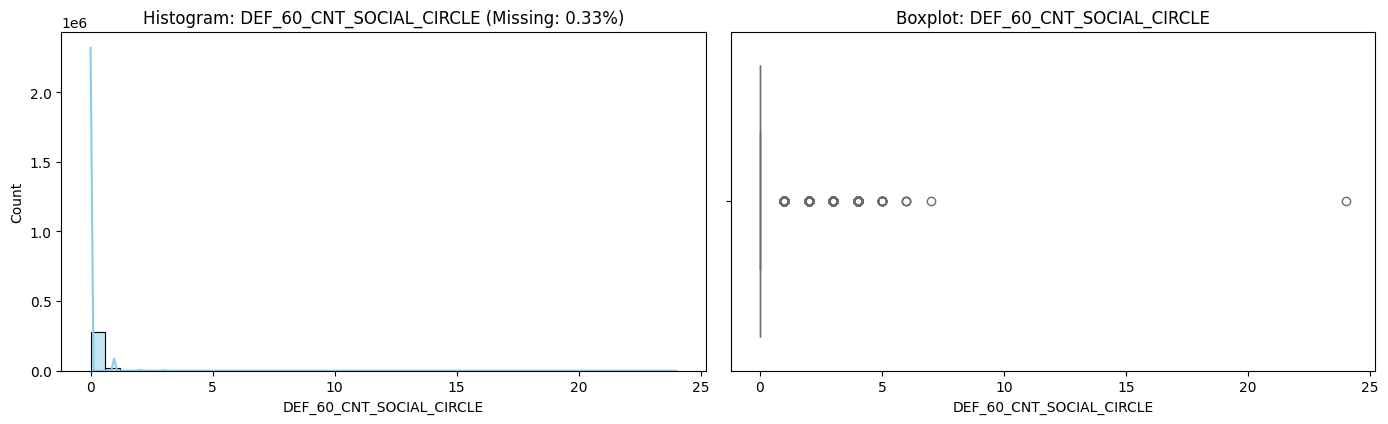

In [56]:
eda_numerical_feature(df_main, 'DEF_60_CNT_SOCIAL_CIRCLE')


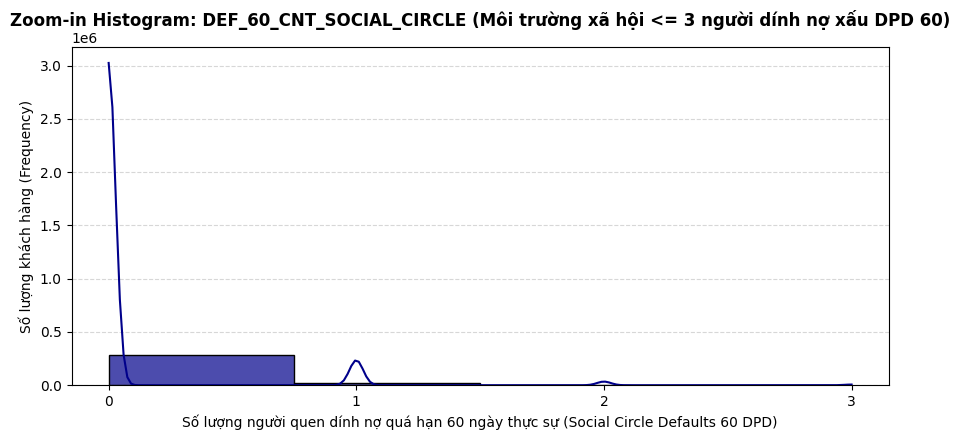

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns  # Sử dụng thư viện Seaborn chuẩn hóa dưới bí danh sns

# Khởi tạo kích thước biểu đồ chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Lọc dải dữ liệu sạch - chỉ lấy nhóm từ 3 người dính nợ xấu trở xuống cho biến DEF_60
# Loại bỏ các dòng khuyết NaN để đường cong mật độ KDE không bị lỗi tính toán
clean_def_60 = df_main[(df_main['DEF_60_CNT_SOCIAL_CIRCLE'] <= 3) & (df_main['DEF_60_CNT_SOCIAL_CIRCLE'].notna())]['DEF_60_CNT_SOCIAL_CIRCLE']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh thông qua thư viện Seaborn (sns)
# bins=4 tương ứng chính xác cho 4 nấc giá trị số nguyên rời rạc: 0, 1, 2, và 3
sns.histplot(clean_def_60, bins=4, kde=True, color='darkblue', edgecolor='black', alpha=0.7)

# Cấu hình định dạng hiển thị trực quan chuyên nghiệp
plt.title('Zoom-in Histogram: DEF_60_CNT_SOCIAL_CIRCLE (Môi trường xã hội <= 3 người dính nợ xấu DPD 60)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số lượng người quen dính nợ quá hạn 60 ngày thực sự (Social Circle Defaults 60 DPD)', fontsize=10)
plt.ylabel('Số lượng khách hàng (Frequency)', fontsize=10)

# Ép trục X hiển thị chính xác từng nấc số nguyên từ 0 đến 3
plt.xticks(range(4))

# Thêm lưới mờ theo trục ngang giúp quan sát tương quan độ cao các cột rõ ràng hơn
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị
plt.tight_layout()
plt.show()

In [63]:
df_bureau = pd.read_csv(BUREAU_FILE)

print(f"✅ Đã nạp thành công bảng chính application_train.csv vào bộ nhớ!")
print(f"   Kích thước dữ liệu thô: {df_bureau.shape[0]:,} dòng | {df_bureau.shape[1]} cột.")

✅ Đã nạp thành công bảng chính application_train.csv vào bộ nhớ!
   Kích thước dữ liệu thô: 1,716,428 dòng | 17 cột.


📊 [CATEGORICAL] Feature: CREDIT_ACTIVE | Unique Groups: 4
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
CREDIT_ACTIVE,,
Closed,"1,079,273",62.88
Active,"630,607",36.74
Sold,"6,527",0.38
Bad debt,21,0.00


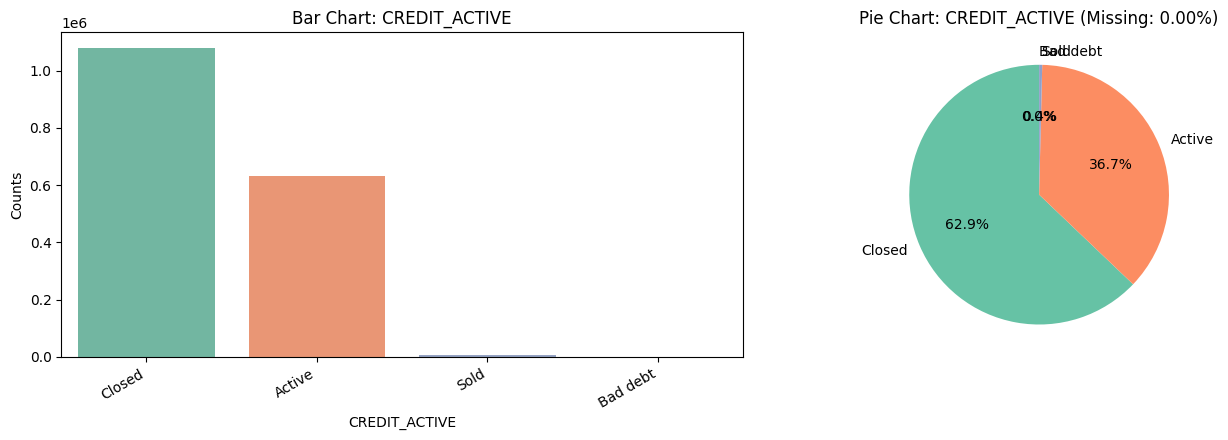

In [65]:
eda_categorical_feature(df_bureau, 'CREDIT_ACTIVE')


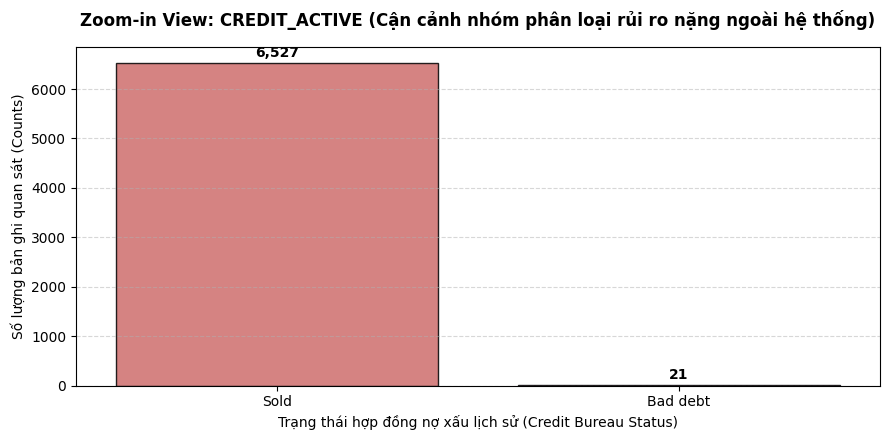

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ chuẩn cho báo cáo đồ án
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Cô lập nhóm dữ liệu thiểu số dính vết đen rủi ro để thực hiện Zoom-in view
minority_credit = df_bureau[df_bureau['CREDIT_ACTIVE'].isin(['Sold', 'Bad debt'])]

# Bước 3: Vẽ biểu đồ tần suất Countplot cận cảnh cho nhóm thiểu số
# Đã sửa lỗi FutureWarning bằng cách gán x vào hue và tắt legend
sns.countplot(
    data=minority_credit, 
    x='CREDIT_ACTIVE', 
    order=['Sold', 'Bad debt'], 
    hue='CREDIT_ACTIVE', 
    legend=False, 
    palette='flare', 
    edgecolor='black', 
    alpha=0.85
)

# Cấu hình định dạng trực quan chuyên nghiệp để dán vào Notion/Báo cáo
plt.title('Zoom-in View: CREDIT_ACTIVE (Cận cảnh nhóm phân loại rủi ro nặng ngoài hệ thống)', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Trạng thái hợp đồng nợ xấu lịch sử (Credit Bureau Status)', fontsize=10)
plt.ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=10)

# Thêm lưới mờ theo trục ngang giúp Hội đồng dễ quan sát tương quan độ cao
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Chạy vòng lặp tự động hiển thị số lượng cụ thể ngay trên đầu mỗi cột hình chữ nhật
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0: # Chỉ ghi số nếu cột đó có dữ liệu thực tế
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=10, fontweight='bold', color='black', xytext=(0, 7),
                    textcoords='offset points')

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị
plt.tight_layout()
plt.show()

📊 [CATEGORICAL] Feature: CREDIT_CURRENCY | Unique Groups: 4
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
CREDIT_CURRENCY,,
currency 1,"1,715,020",99.92
currency 2,"1,224",0.07
currency 3,174,0.01
currency 4,10,0.00


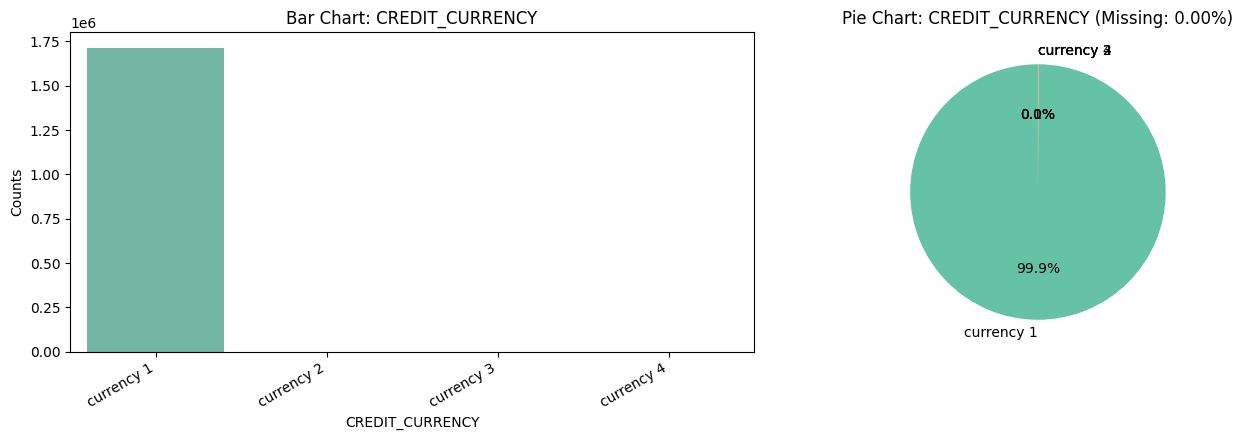

In [68]:
eda_categorical_feature(df_bureau, 'CREDIT_CURRENCY')


📈 [NUMERICAL] Feature: DAYS_CREDIT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,DAYS_CREDIT
Count (Số lượng dòng thực tế),"1,716,428"
Mean (Trung bình),"-1,142.11"
Median (Trung vị),-987.00
Mode (Yếu vị),-364.00
Std Dev (Độ lệch chuẩn),795.16
Min,"-2,922.00"
Max,0.00
IQR (Tứ phân vị),"1,192.00"


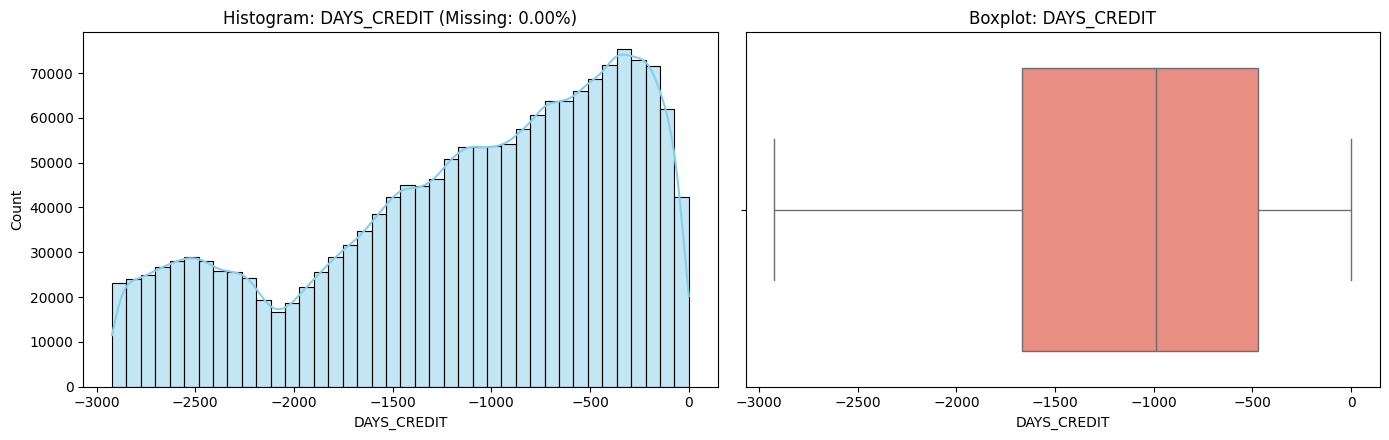

In [70]:
eda_numerical_feature(df_bureau, 'DAYS_CREDIT')


📈 [NUMERICAL] Feature: CREDIT_DAY_OVERDUE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,CREDIT_DAY_OVERDUE
Count (Số lượng dòng thực tế),"1,716,428"
Mean (Trung bình),0.82
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),36.54
Min,0.00
Max,"2,792.00"
IQR (Tứ phân vị),0.00


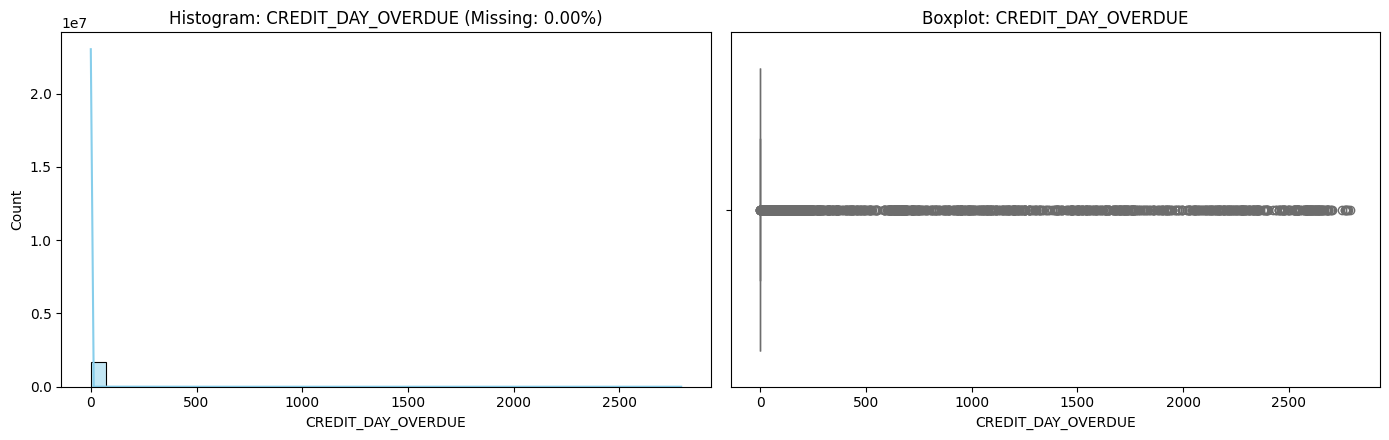

In [71]:
eda_numerical_feature(df_bureau, 'CREDIT_DAY_OVERDUE')


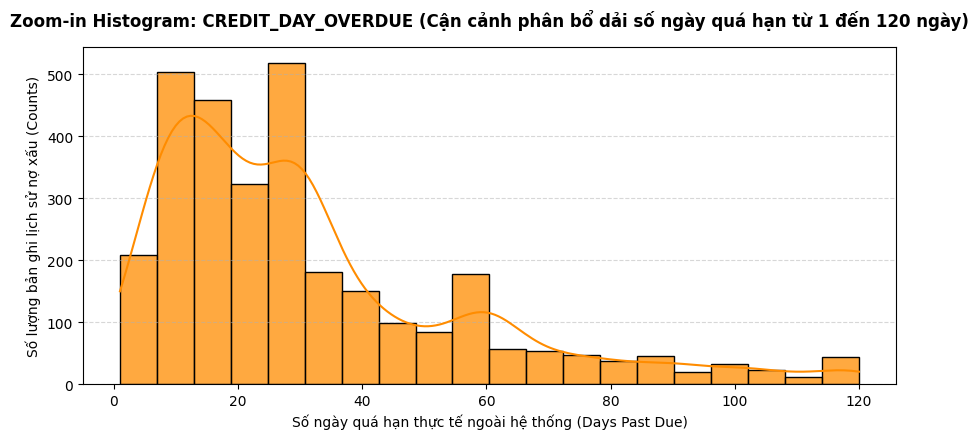

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ quy chuẩn cho báo cáo đồ án
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Áp dụng kỹ thuật lọc cô lập phân khúc rủi ro thực tế
# Lọc bỏ hoàn toàn mức 0 ngày để giải phóng độ nén, và giới hạn đuôi ngoại lai ở mức 120 ngày quá hạn
clean_overdue = df_bureau[(df_bureau['CREDIT_DAY_OVERDUE'] > 0) & (df_bureau['CREDIT_DAY_OVERDUE'] <= 120) & (df_bureau['CREDIT_DAY_OVERDUE'].notna())]['CREDIT_DAY_OVERDUE']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh với đường cong mật độ KDE màu cam rực cháy
sns.histplot(clean_overdue, bins=20, kde=True, color='darkorange', edgecolor='black', alpha=0.75)

# Cấu hình các nhãn hiển thị trực quan chuyên nghiệp
plt.title('Zoom-in Histogram: CREDIT_DAY_OVERDUE (Cận cảnh phân bổ dải số ngày quá hạn từ 1 đến 120 ngày)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số ngày quá hạn thực tế ngoài hệ thống (Days Past Due)', fontsize=10)
plt.ylabel('Số lượng bản ghi lịch sử nợ xấu (Counts)', fontsize=10)

# Thêm lưới mờ theo trục dọc để dễ dàng đối chiếu tần suất
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: DAYS_CREDIT_ENDDATE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 105,553 dòng | Tỷ lệ khuyết: 6.15%
-----------------------------------------------------------------


,DAYS_CREDIT_ENDDATE
Count (Số lượng dòng thực tế),"1,610,875"
Mean (Trung bình),510.52
Median (Trung vị),-330.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"4,994.22"
Min,"-42,060.00"
Max,"31,199.00"
IQR (Tứ phân vị),"1,612.00"


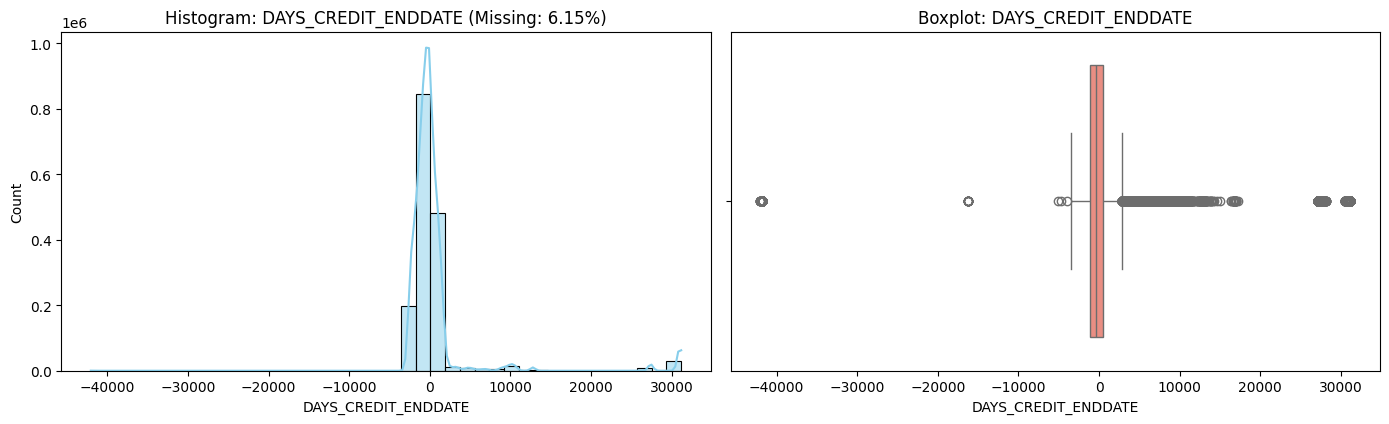

In [73]:
eda_numerical_feature(df_bureau, 'DAYS_CREDIT_ENDDATE')


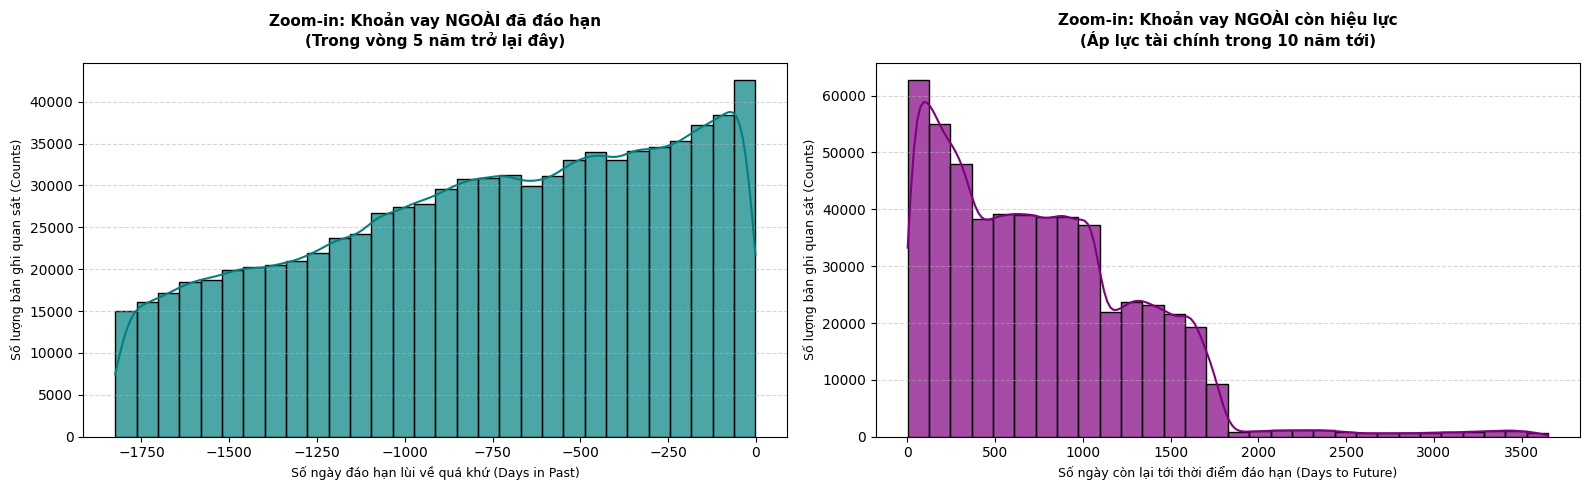

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo khung hình kép gồm 2 biểu đồ nằm song song nhau (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# =========================================================================
# BIỂU ĐỒ 1: ZOOM-IN VÙNG ÂM (CẬN CẢNH KHOẢN VAY ĐÃ ĐÁO HẠN TRONG 5 NĂM QUA)
# =========================================================================
# Lọc dải dữ liệu từ -1825 ngày (5 năm trước) đến sát mốc 0 ngày nộp đơn hiện tại
past_enddate = df_bureau[(df_bureau['DAYS_CREDIT_ENDDATE'] >= -1825) & (df_bureau['DAYS_CREDIT_ENDDATE'] < 0)]

sns.histplot(data=past_enddate, x='DAYS_CREDIT_ENDDATE', bins=30, kde=True, 
             color='teal', edgecolor='black', alpha=0.7, ax=axes[0])

axes[0].set_title('Zoom-in: Khoản vay NGOÀI đã đáo hạn\n(Trong vòng 5 năm trở lại đây)', fontsize=11, fontweight='bold', pad=12)
axes[0].set_xlabel('Số ngày đáo hạn lùi về quá khứ (Days in Past)', fontsize=9)
axes[0].set_ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


# =========================================================================
# BIỂU ĐỒ 2: ZOOM-IN VÙNG DƯƠNG (CẬN CẢNH KHOẢN VAY CÒN HIỆU LỰC TRONG 10 NĂM TỚI)
# =========================================================================
# Lọc dải dữ liệu từ mốc 0 ngày đến 3650 ngày (10 năm tương lai)
future_enddate = df_bureau[(df_bureau['DAYS_CREDIT_ENDDATE'] > 0) & (df_bureau['DAYS_CREDIT_ENDDATE'] <= 3650)]

sns.histplot(data=future_enddate, x='DAYS_CREDIT_ENDDATE', bins=30, kde=True, 
             color='purple', edgecolor='black', alpha=0.7, ax=axes[1])

axes[1].set_title('Zoom-in: Khoản vay NGOÀI còn hiệu lực\n(Áp lực tài chính trong 10 năm tới)', fontsize=11, fontweight='bold', pad=12)
axes[1].set_xlabel('Số ngày còn lại tới thời điểm đáo hạn (Days to Future)', fontsize=9)
axes[1].set_ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


# Tối ưu hóa khoảng cách giữa hai biểu đồ để không bị đè chữ và hiển thị
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: DAYS_ENDDATE_FACT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 633,653 dòng | Tỷ lệ khuyết: 36.92%
-----------------------------------------------------------------


,DAYS_ENDDATE_FACT
Count (Số lượng dòng thực tế),"1,082,775"
Mean (Trung bình),"-1,017.44"
Median (Trung vị),-897.00
Mode (Yếu vị),-329.00
Std Dev (Độ lệch chuẩn),714.01
Min,"-42,023.00"
Max,0.00
IQR (Tứ phân vị),"1,064.00"


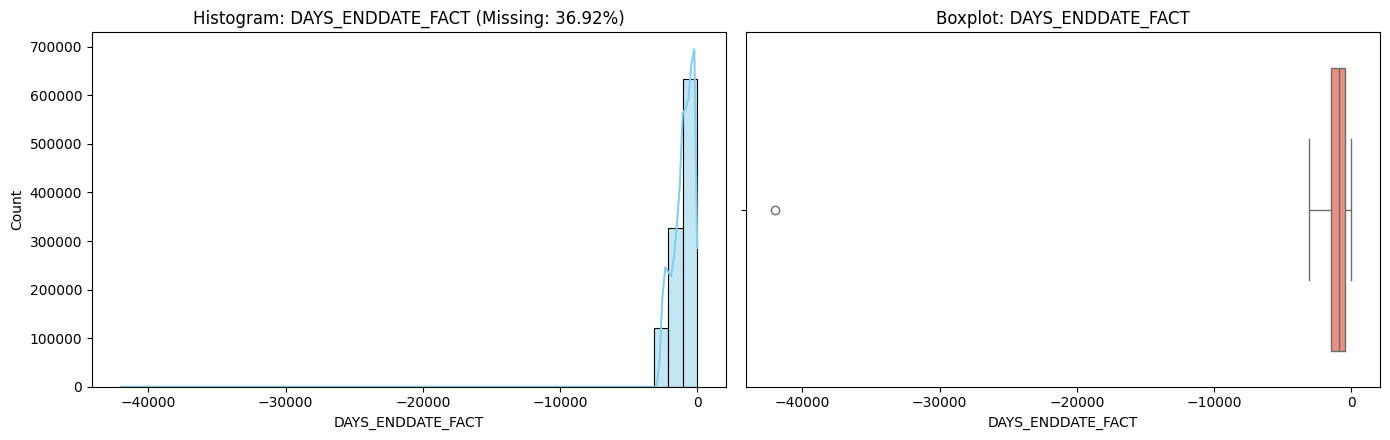

In [75]:
eda_numerical_feature(df_bureau, 'DAYS_ENDDATE_FACT')


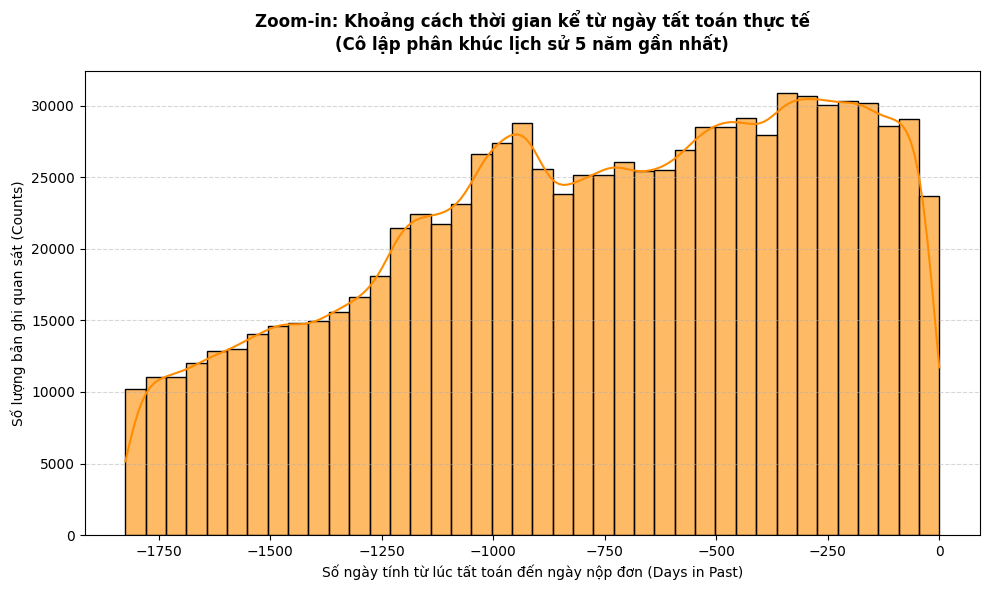

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# ZOOM-IN: CÔ LẬP KHÔNG GIAN THỜI GIAN TẤT TOÁN TRONG VÒNG 5 NĂM TRỞ LẠI ĐÂY
# =========================================================================

# Bước 1: Lọc dải dữ liệu từ -1825 ngày (5 năm trước) đến mốc 0 ngày (chỉ lấy khoản vay đã closed)
# Hàm này tự động loại bỏ các giá trị NaN (các khoản vay vẫn đang Active)
closed_recent = df_bureau[(df_bureau['DAYS_ENDDATE_FACT'] >= -1825) & (df_bureau['DAYS_ENDDATE_FACT'] <= 0)]

# Bước 2: Khởi tạo khung vẽ
plt.figure(figsize=(10, 6))

# Bước 3: Vẽ biểu đồ phân phối kết hợp Histogram và đường cong mật độ KDE
sns.histplot(data=closed_recent, x='DAYS_ENDDATE_FACT', bins=40, kde=True,
             color='darkorange', edgecolor='black', alpha=0.6)

# Bước 4: Cấu hình thẩm mỹ và nhãn hiển thị quy chuẩn luận văn
plt.title('Zoom-in: Khoảng cách thời gian kể từ ngày tất toán thực tế\n(Cô lập phân khúc lịch sử 5 năm gần nhất)', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Số ngày tính từ lúc tất toán đến ngày nộp đơn (Days in Past)', fontsize=10)
plt.ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=10)

# Bật lưới tọa độ mờ phục vụ quan sát đỉnh mật độ
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_CREDIT_MAX_OVERDUE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,124,488 dòng | Tỷ lệ khuyết: 65.51%
-----------------------------------------------------------------


,AMT_CREDIT_MAX_OVERDUE
Count (Số lượng dòng thực tế),"591,940"
Mean (Trung bình),"3,825.42"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"206,031.61"
Min,0.00
Max,"115,987,185.00"
IQR (Tứ phân vị),0.00


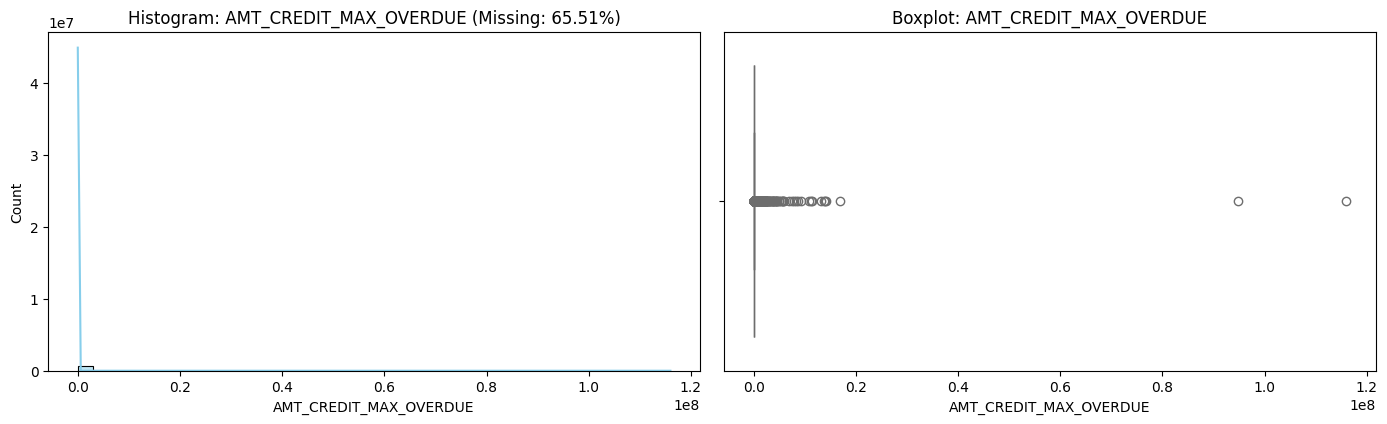

In [77]:
eda_numerical_feature(df_bureau, 'AMT_CREDIT_MAX_OVERDUE')


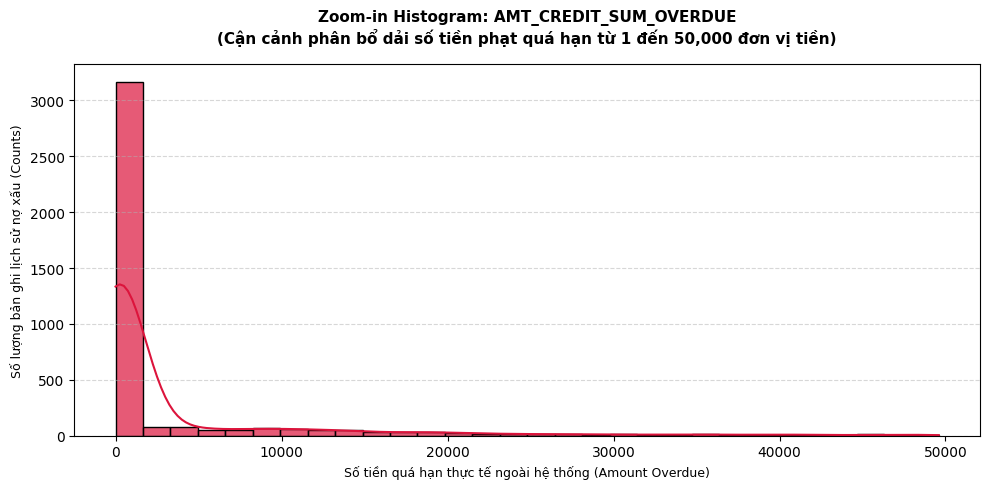

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(10, 5))

# Bước 1 & 2: Áp dụng kỹ thuật lọc cô lập phân khúc rủi ro tài chính thực tế
# Lọc bỏ hoàn toàn mức 0 đồng để giải phóng độ nén, và giới hạn trần hiển thị ở mức 50,000 đơn vị tiền
clean_amount_overdue = df_bureau[(df_bureau['AMT_CREDIT_SUM_OVERDUE'] > 0) & (df_bureau['AMT_CREDIT_SUM_OVERDUE'] <= 50000) & (df_bureau['AMT_CREDIT_SUM_OVERDUE'].notna())]['AMT_CREDIT_SUM_OVERDUE']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh với đường cong mật độ KDE màu crimson rực cháy
sns.histplot(clean_amount_overdue, bins=30, kde=True, color='crimson', edgecolor='black', alpha=0.7)

# Cấu hình các nhãn hiển thị trực quan chuyên nghiệp
plt.title('Zoom-in Histogram: AMT_CREDIT_SUM_OVERDUE\n(Cận cảnh phân bổ dải số tiền phạt quá hạn từ 1 đến 50,000 đơn vị tiền)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền quá hạn thực tế ngoài hệ thống (Amount Overdue)', fontsize=9)
plt.ylabel('Số lượng bản ghi lịch sử nợ xấu (Counts)', fontsize=9)

# Bật lưới tọa độ mờ phục vụ quan sát
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_CREDIT_PROLONG
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,CNT_CREDIT_PROLONG
Count (Số lượng dòng thực tế),"1,716,428"
Mean (Trung bình),0.01
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.10
Min,0.00
Max,9.00
IQR (Tứ phân vị),0.00


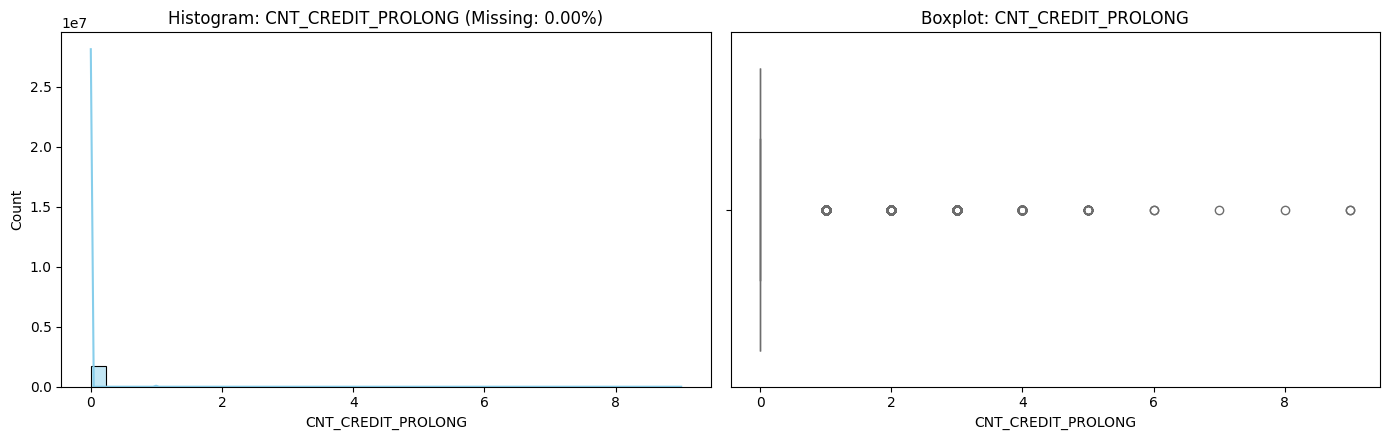

In [80]:
eda_numerical_feature(df_bureau, 'CNT_CREDIT_PROLONG')


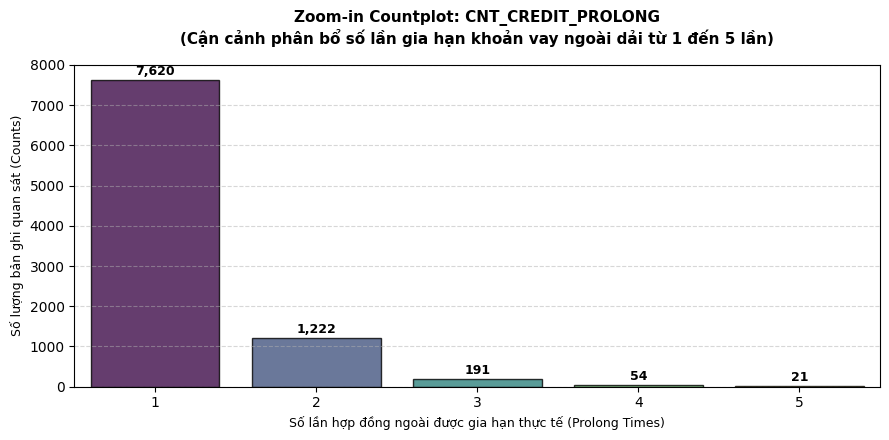

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Áp dụng kỹ thuật lọc cô lập phân khúc rủi ro thực tế
# Lọc bỏ hoàn toàn mức 0 lần để giải phóng độ nén, và giới hạn trần hiển thị trực quan ở mốc 5 lần gia hạn
clean_prolong = df_bureau[(df_bureau['CNT_CREDIT_PROLONG'] > 0) & (df_bureau['CNT_CREDIT_PROLONG'] <= 5) & (df_bureau['CNT_CREDIT_PROLONG'].notna())]

# Bước 3: Vẽ biểu đồ tần suất Countplot cho biến rời rạc rời rạc (Sửa lỗi FutureWarning)
sns.countplot(
    data=clean_prolong, 
    x='CNT_CREDIT_PROLONG',
    hue='CNT_CREDIT_PROLONG',
    legend=False,
    palette='viridis', 
    edgecolor='black', 
    alpha=0.8
)

# Cấu hình các nhãn hiển thị trực quan chuyên nghiệp
plt.title('Zoom-in Countplot: CNT_CREDIT_PROLONG\n(Cận cảnh phân bổ số lần gia hạn khoản vay ngoài dải từ 1 đến 5 lần)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số lần hợp đồng ngoài được gia hạn thực tế (Prolong Times)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=9)

# Bật lưới lưới ngang mờ phụ vụ đối chiếu tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm số liệu cụ thể trên đầu mỗi cột rời rạc
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, fontweight='bold', color='black', xytext=(0, 6),
                    textcoords='offset points')

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_CREDIT_PROLONG
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,CNT_CREDIT_PROLONG
Count (Số lượng dòng thực tế),"1,716,428"
Mean (Trung bình),0.01
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.10
Min,0.00
Max,9.00
IQR (Tứ phân vị),0.00


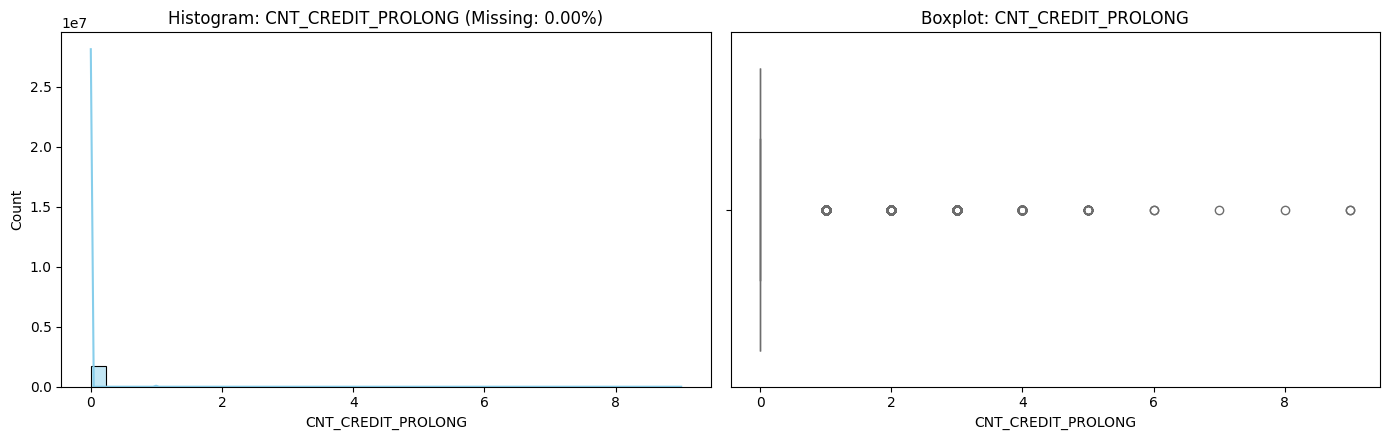

In [82]:
eda_numerical_feature(df_bureau, 'CNT_CREDIT_PROLONG')


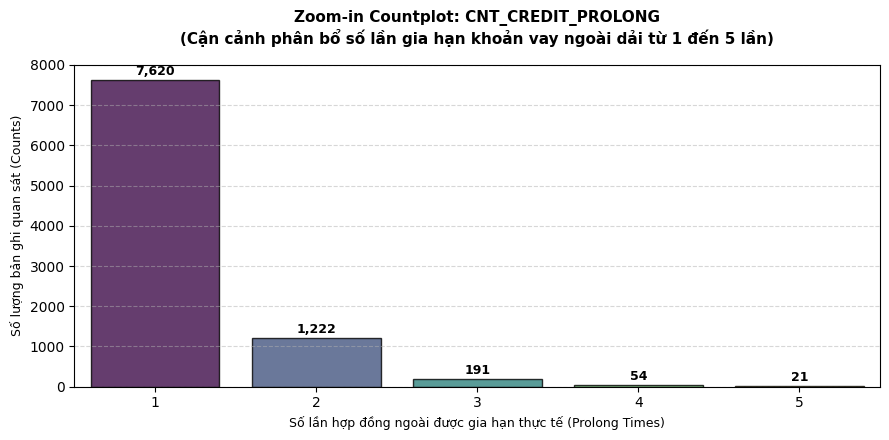

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(9, 4.5))

# Bước 1 & 2: Áp dụng kỹ thuật lọc cô lập phân khúc rủi ro thực tế
# Lọc bỏ hoàn toàn mức 0 lần để giải phóng độ nén, và giới hạn trần hiển thị trực quan ở mốc 5 lần gia hạn
clean_prolong = df_bureau[(df_bureau['CNT_CREDIT_PROLONG'] > 0) & (df_bureau['CNT_CREDIT_PROLONG'] <= 5) & (df_bureau['CNT_CREDIT_PROLONG'].notna())]

# Bước 3: Vẽ biểu đồ tần suất Countplot cho biến rời rạc (Đồng bộ tham số để xóa FutureWarning)
sns.countplot(
    data=clean_prolong, 
    x='CNT_CREDIT_PROLONG',
    hue='CNT_CREDIT_PROLONG',
    legend=False,
    palette='viridis', 
    edgecolor='black', 
    alpha=0.8
)

# Cấu hình các nhãn hiển thị trực quan chuyên nghiệp phục vụ dán vào Notion
plt.title('Zoom-in Countplot: CNT_CREDIT_PROLONG\n(Cận cảnh phân bổ số lần gia hạn khoản vay ngoài dải từ 1 đến 5 lần)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số lần hợp đồng ngoài được gia hạn thực tế (Prolong Times)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=9)

# Bật lưới lưới ngang mờ phục vụ đối chiếu tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm số liệu cụ thể tự động hiển thị trên đầu mỗi cột hình chữ nhật rời rạc
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, fontweight='bold', color='black', xytext=(0, 6),
                    textcoords='offset points')

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_CREDIT_PROLONG
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,CNT_CREDIT_PROLONG
Count (Số lượng dòng thực tế),"1,716,428"
Mean (Trung bình),0.01
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.10
Min,0.00
Max,9.00
IQR (Tứ phân vị),0.00


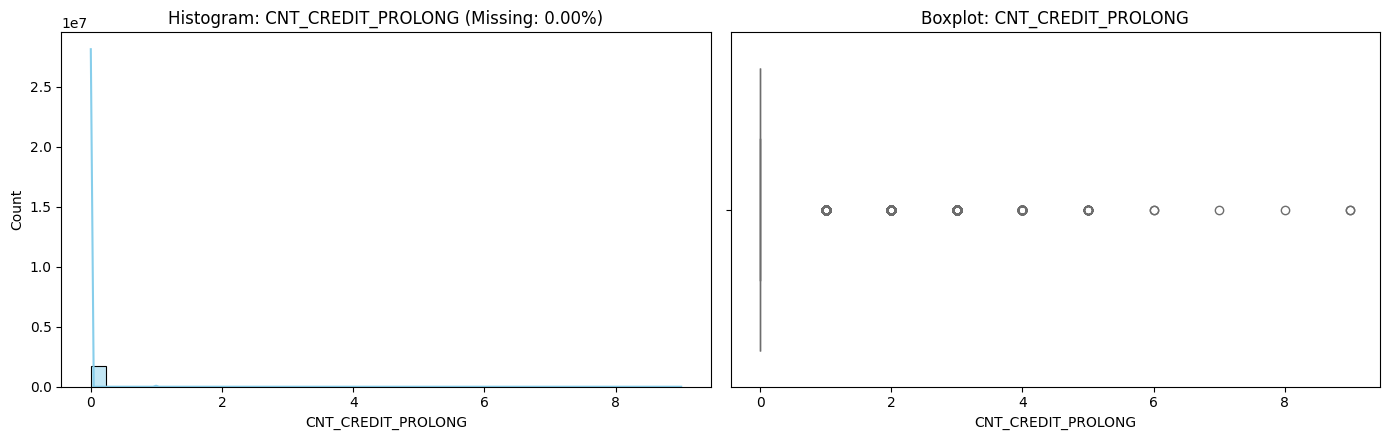

In [84]:
eda_numerical_feature(df_bureau, 'CNT_CREDIT_PROLONG')


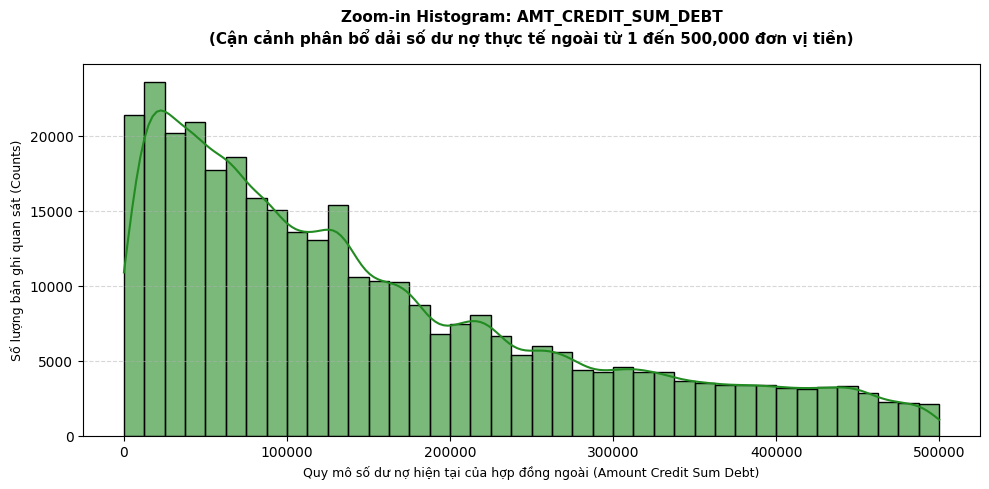

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(10, 5))

# Bước 1 & 2: Áp dụng kỹ thuật lọc cô lập phân khúc dư nợ thực tế
# Lọc bỏ hoàn toàn mức <= 0 đồng để giải phóng độ nén + dải âm trả thừa, và giới hạn trần hiển thị trực quan ở mốc 500,000 đơn vị tiền
clean_credit_debt = df_bureau[(df_bureau['AMT_CREDIT_SUM_DEBT'] > 0) & (df_bureau['AMT_CREDIT_SUM_DEBT'] <= 500000) & (df_bureau['AMT_CREDIT_SUM_DEBT'].notna())]['AMT_CREDIT_SUM_DEBT']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh kết hợp đường cong mật độ KDE mượt mà màu lục rừng sâu
sns.histplot(clean_credit_debt, bins=40, kde=True, color='forestgreen', edgecolor='black', alpha=0.6)

# Cấu hình các nhãn hiển thị trực quan chuyên nghiệp phục vụ dán vào Notion
plt.title('Zoom-in Histogram: AMT_CREDIT_SUM_DEBT\n(Cận cảnh phân bổ dải số dư nợ thực tế ngoài từ 1 đến 500,000 đơn vị tiền)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Quy mô số dư nợ hiện tại của hợp đồng ngoài (Amount Credit Sum Debt)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=9)

# Bật lưới lưới ngang mờ phục vụ đối chiếu tần suất
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_CREDIT_SUM_LIMIT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 591,780 dòng | Tỷ lệ khuyết: 34.48%
-----------------------------------------------------------------


,AMT_CREDIT_SUM_LIMIT
Count (Số lượng dòng thực tế),"1,124,648"
Mean (Trung bình),"6,229.51"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"45,032.03"
Min,"-586,406.11"
Max,"4,705,600.32"
IQR (Tứ phân vị),0.00


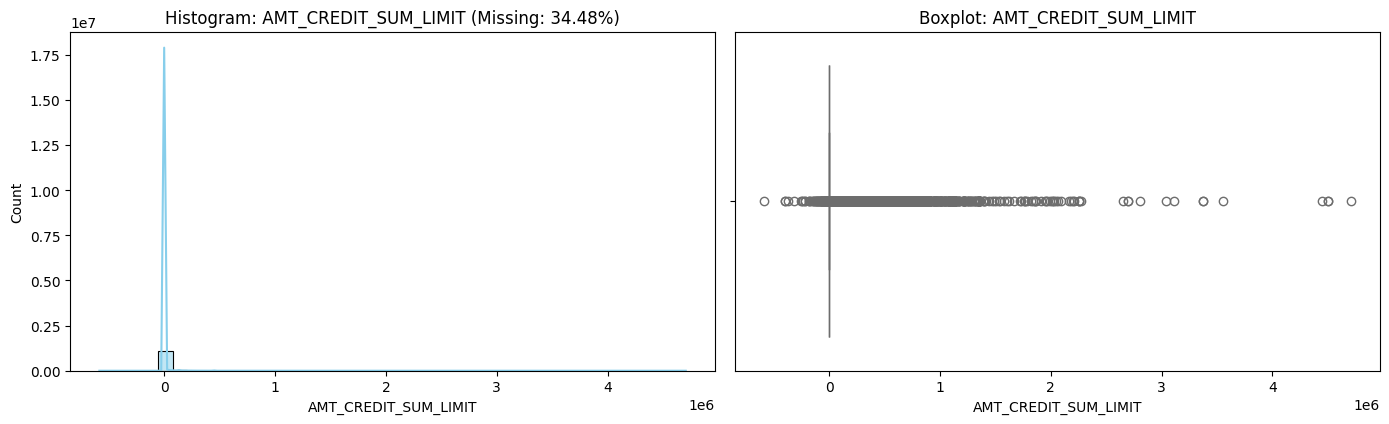

In [86]:
eda_numerical_feature(df_bureau, 'AMT_CREDIT_SUM_LIMIT')


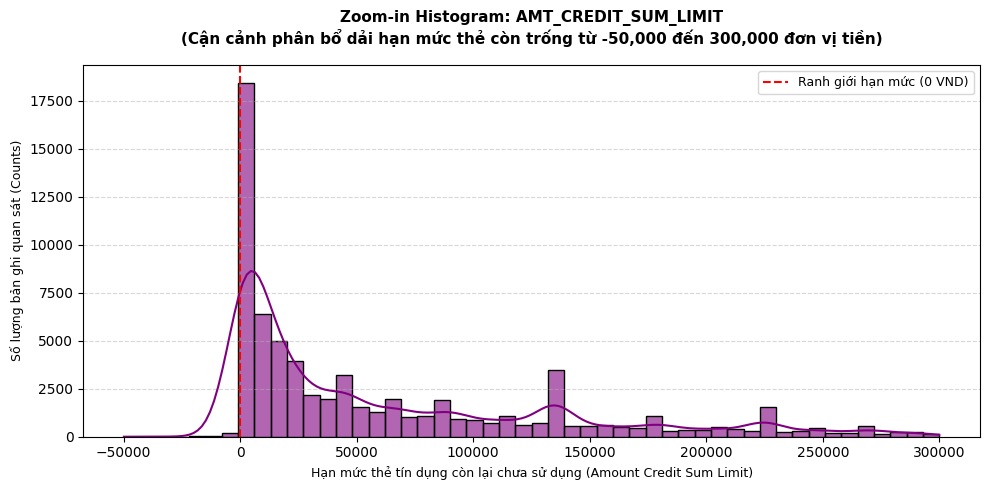

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước khung hình quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(10, 5))

# =========================================================================
# TIỀN XỬ LÝ & LỌC DỮ LIỆU ZOOM-IN (GIỮ LẠI CẢ ÂM VÀ DƯƠNG, LOẠI BỎ MỐC 0)
# =========================================================================
# Lọc cô lập dải từ -50,000 (quẹt lố hạn mức) đến 300,000 (hạn mức còn trống)
# Loại bỏ chính xác mốc 0.0 đồng để giải phóng hiện tượng bẹp đồ thị thô
clean_limit = df_bureau[
    (df_bureau['AMT_CREDIT_SUM_LIMIT'] != 0) & 
    (df_bureau['AMT_CREDIT_SUM_LIMIT'] >= -50000) & 
    (df_bureau['AMT_CREDIT_SUM_LIMIT'] <= 300000) & 
    (df_bureau['AMT_CREDIT_SUM_LIMIT'].notna())
]['AMT_CREDIT_SUM_LIMIT']

# =========================================================================
# TRỰC QUAN HÓA BIỂU ĐỒ HISTOGRAM & ĐƯỜNG CONG MẬT ĐỘ KDE
# =========================================================================
# Vẽ biểu đồ Histogram phân bổ với màu tím bầm (Amethyst) mượt mà
sns.histplot(clean_limit, bins=50, kde=True, color='purple', edgecolor='black', alpha=0.6)

# Vạch một đường thẳng đứng nét đứt màu đỏ ngay mốc số 0 làm ranh giới nghiệp vụ tài chính
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Ranh giới hạn mức (0 VND)')

# =========================================================================
# CẤU HÌNH THẨM MỸ ĐỒ THỊ & CHÚ THÍCH (NOTION ALIGNED)
# =========================================================================
plt.title('Zoom-in Histogram: AMT_CREDIT_SUM_LIMIT\n(Cận cảnh phân bổ dải hạn mức thẻ còn trống từ -50,000 đến 300,000 đơn vị tiền)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Hạn mức thẻ tín dụng còn lại chưa sử dụng (Amount Credit Sum Limit)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=9)

# Hiển thị bảng chú thích cho đường ranh giới màu đỏ
plt.legend(loc='upper right', fontsize=9)

# Bật lưới lưới ngang mờ phục vụ đối chiếu tần suất xung quanh trục hoành
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_CREDIT_SUM_OVERDUE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_CREDIT_SUM_OVERDUE
Count (Số lượng dòng thực tế),"1,716,428"
Mean (Trung bình),37.91
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"5,937.65"
Min,0.00
Max,"3,756,681.00"
IQR (Tứ phân vị),0.00


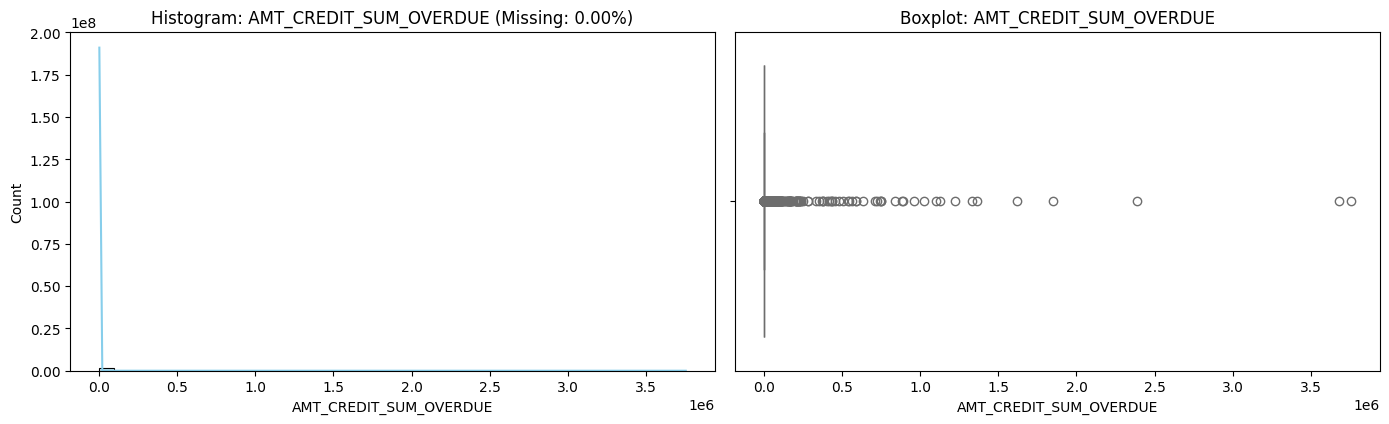

In [89]:
eda_numerical_feature(df_bureau, 'AMT_CREDIT_SUM_OVERDUE')


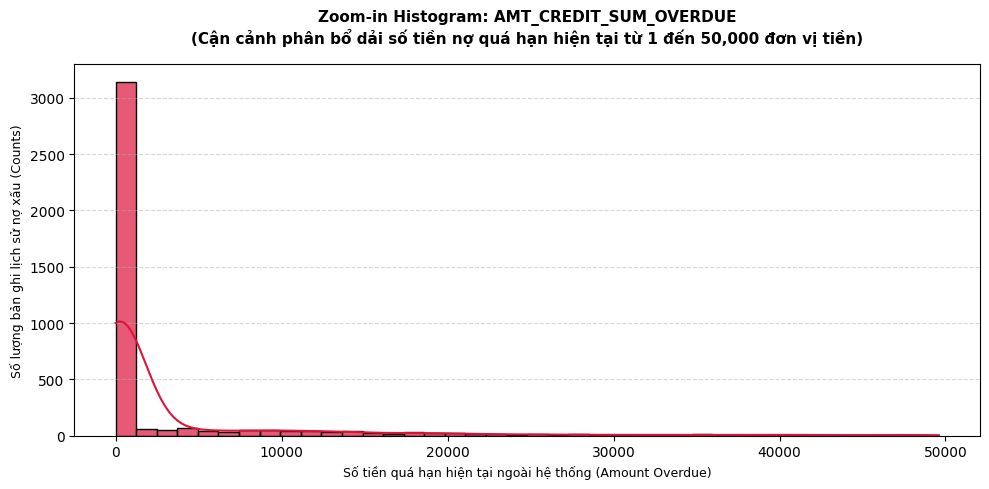

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(10, 5))

# Bước 1 & 2: Áp dụng kỹ thuật lọc cô lập phân khúc nợ quá hạn thực tế
# Lọc bỏ hoàn toàn mức 0 đồng để giải phóng độ nén, và giới hạn trần hiển thị trực quan ở mốc 50,000 đơn vị tiền
clean_overdue = df_bureau[
    (df_bureau['AMT_CREDIT_SUM_OVERDUE'] > 0) & 
    (df_bureau['AMT_CREDIT_SUM_OVERDUE'] <= 50000) & 
    (df_bureau['AMT_CREDIT_SUM_OVERDUE'].notna())
]['AMT_CREDIT_SUM_OVERDUE']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh kết hợp đường cong mật độ KDE mượt mà màu đỏ rực cháy (Crimson)
sns.histplot(clean_overdue, bins=40, kde=True, color='crimson', edgecolor='black', alpha=0.7)

# Cấu hình các nhãn hiển thị trực quan chuyên nghiệp phục vụ dán vào Notion
plt.title('Zoom-in Histogram: AMT_CREDIT_SUM_OVERDUE\n(Cận cảnh phân bổ dải số tiền nợ quá hạn hiện tại từ 1 đến 50,000 đơn vị tiền)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền quá hạn hiện tại ngoài hệ thống (Amount Overdue)', fontsize=9)
plt.ylabel('Số lượng bản ghi lịch sử nợ xấu (Counts)', fontsize=9)

# Bật lưới lưới ngang mờ phục vụ đối chiếu tần suất
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()


📊 [CATEGORICAL] Feature: CREDIT_TYPE | Unique Groups: 15
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
CREDIT_TYPE,,
Consumer credit,"1,251,615",72.92
Credit card,"402,195",23.43
Car loan,"27,690",1.61
Mortgage,"18,391",1.07
Microloan,"12,413",0.72
Loan for business development,"1,975",0.12
Another type of loan,"1,017",0.06
Unknown type of loan,555,0.03
Loan for working capital replenishment,469,0.03


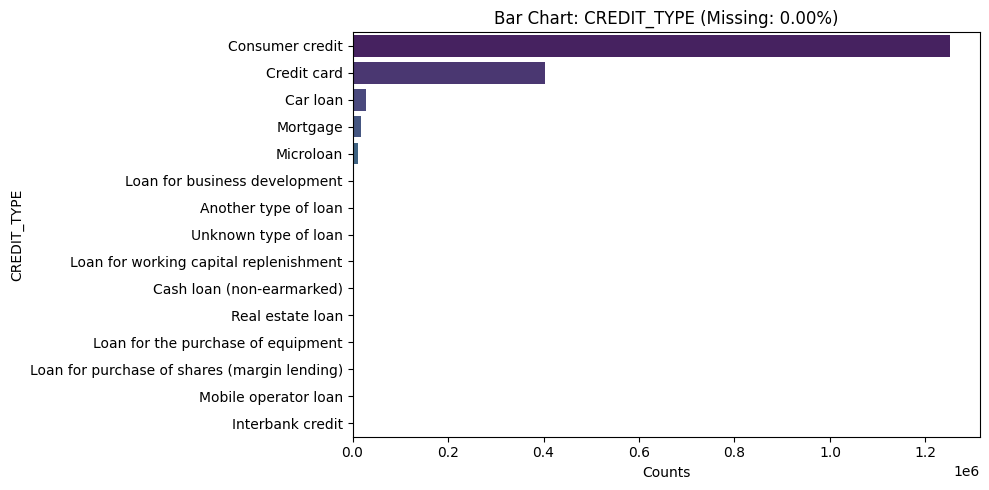

In [91]:
eda_categorical_feature(df_bureau, 'CREDIT_TYPE')


📈 [NUMERICAL] Feature: DAYS_CREDIT_UPDATE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,DAYS_CREDIT_UPDATE
Count (Số lượng dòng thực tế),"1,716,428"
Mean (Trung bình),-593.75
Median (Trung vị),-395.00
Mode (Yếu vị),-7.00
Std Dev (Độ lệch chuẩn),720.75
Min,"-41,947.00"
Max,372.00
IQR (Tứ phân vị),875.00


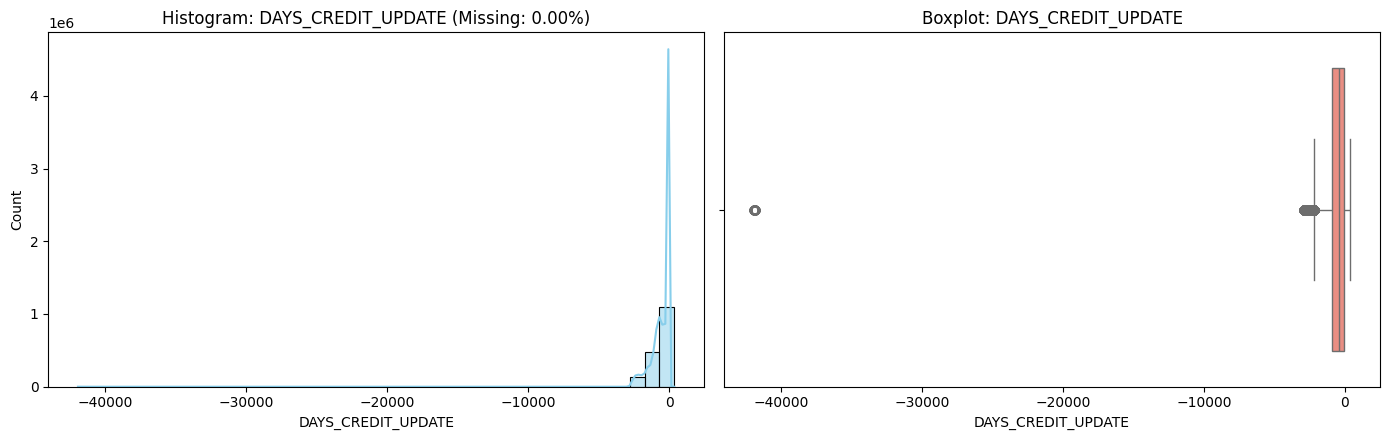

In [92]:
eda_numerical_feature(df_bureau, 'DAYS_CREDIT_UPDATE')


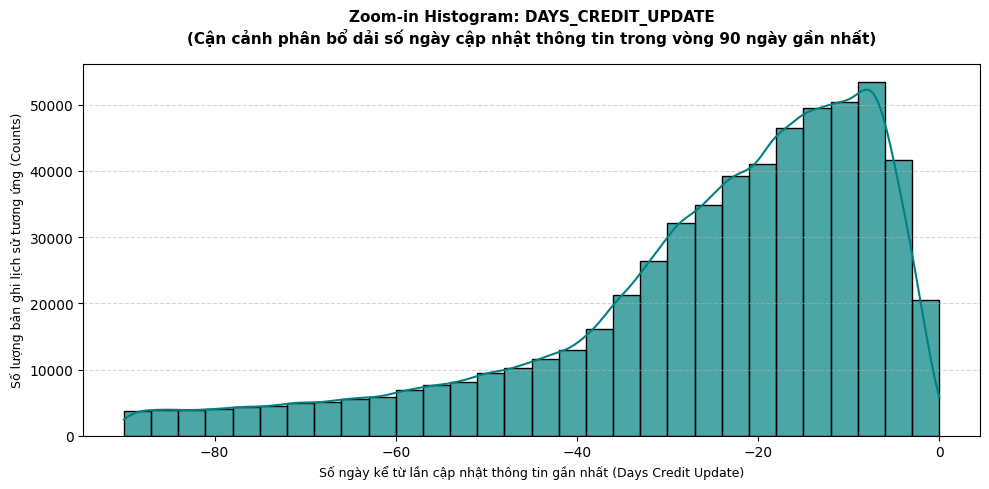

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước khung hình quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(10, 5))

# =========================================================================
# TIỀN XỬ LÝ & LỌC DỮ LIỆU ZOOM-IN (CÔ LẬP KHOẢNG CẬP NHẬT 90 NGÀY GẦN NHẤT)
# =========================================================================
# Lọc lấy dải dữ liệu từ -90 ngày (cập nhật cách đây 3 tháng) đến mốc 0 ngày (cập nhật ngay hôm nay)
# Giúp giải phóng độ nén từ các dải âm quá sâu của lịch sử cũ
clean_credit_update = df_bureau[
    (df_bureau['DAYS_CREDIT_UPDATE'] >= -90) & 
    (df_bureau['DAYS_CREDIT_UPDATE'] <= 0) & 
    (df_bureau['DAYS_CREDIT_UPDATE'].notna())
]['DAYS_CREDIT_UPDATE']

# =========================================================================
# TRỰC QUAN HÓA BIỂU ĐỒ HISTOGRAM & ĐƯỜNG CONG MẬT ĐỘ KDE
# =========================================================================
# Sử dụng màu xanh ngọc biển (teal) đại diện cho tính cập nhật liên tục của thông tin
sns.histplot(clean_credit_update, bins=30, kde=True, color='teal', edgecolor='black', alpha=0.7)

# =========================================================================
# CẤU HÌNH THẨM MỸ ĐỒ THỊ (NOTION ALIGNED)
# =========================================================================
plt.title('Zoom-in Histogram: DAYS_CREDIT_UPDATE\n(Cận cảnh phân bổ dải số ngày cập nhật thông tin trong vòng 90 ngày gần nhất)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số ngày kể từ lần cập nhật thông tin gần nhất (Days Credit Update)', fontsize=9)
plt.ylabel('Số lượng bản ghi lịch sử tương ứng (Counts)', fontsize=9)

# Bật lưới lưới ngang mờ phục vụ đối chiếu tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_ANNUITY
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,226,791 dòng | Tỷ lệ khuyết: 71.47%
-----------------------------------------------------------------


,AMT_ANNUITY
Count (Số lượng dòng thực tế),"489,637"
Mean (Trung bình),"15,712.76"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"325,826.95"
Min,0.00
Max,"118,453,423.50"
IQR (Tứ phân vị),"13,500.00"


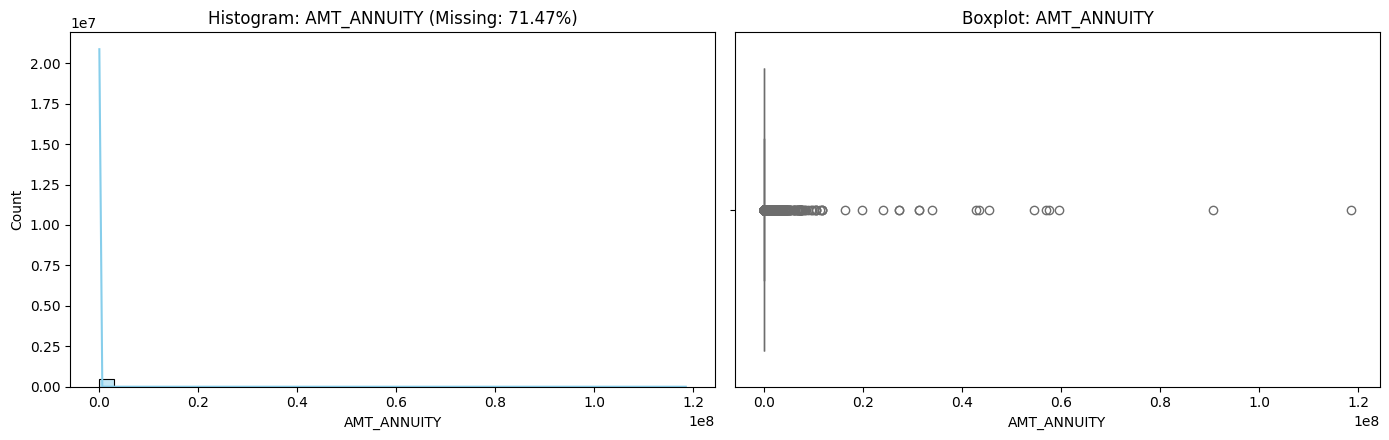

In [97]:
eda_numerical_feature(df_bureau, 'AMT_ANNUITY')


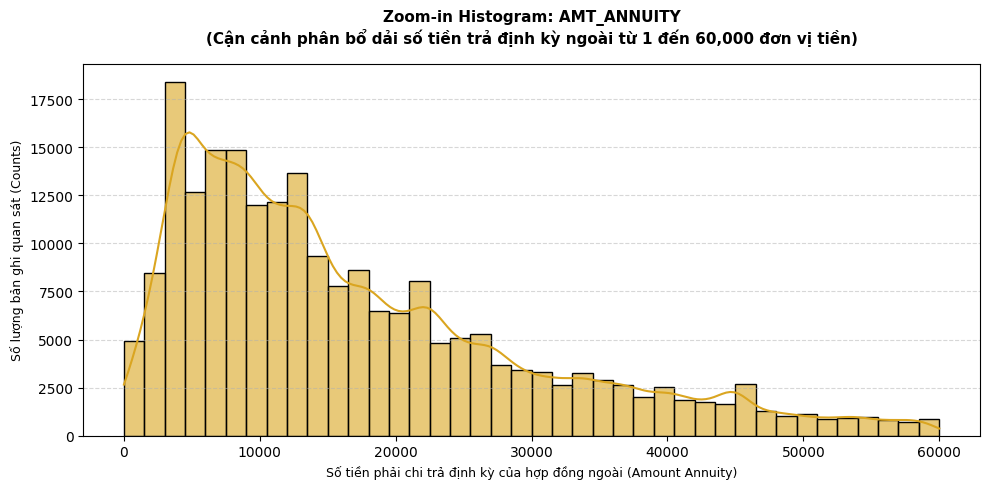

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước biểu đồ quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(10, 5))

# Bước 1 & 2: Áp dụng kỹ thuật lọc cô lập phân khúc số tiền trả định kỳ thực tế
# Lọc bỏ hoàn toàn mức 0 đồng để giải phóng độ nén, và giới hạn trần hiển thị trực quan ở mốc 60,000 đơn vị tiền
clean_annuity = df_bureau[(df_bureau['AMT_ANNUITY'] > 0) & (df_bureau['AMT_ANNUITY'] <= 60000) & (df_bureau['AMT_ANNUITY'].notna())]['AMT_ANNUITY']

# Bước 3: Vẽ biểu đồ Histogram cận cảnh kết hợp đường cong mật độ KDE mượt mà màu vàng nghệ (Goldenrod)
sns.histplot(clean_annuity, bins=40, kde=True, color='goldenrod', edgecolor='black', alpha=0.6)

# Cấu hình các nhãn hiển thị trực quan chuyên nghiệp phục vụ dán vào Notion
plt.title('Zoom-in Histogram: AMT_ANNUITY\n(Cận cảnh phân bổ dải số tiền trả định kỳ ngoài từ 1 đến 60,000 đơn vị tiền)', fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền phải chi trả định kỳ của hợp đồng ngoài (Amount Annuity)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát (Counts)', fontsize=9)

# Bật lưới lưới ngang mờ phục vụ đối chiếu tần suất
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị và hiển thị hình ảnh sạch
plt.tight_layout()
plt.show()

In [99]:
df_bureau_balance = pd.read_csv(BUREAU_BAL_FILE)


📊 [CATEGORICAL] Feature: STATUS | Unique Groups: 8
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
STATUS,,
C,"13,646,993",49.99
0,"7,499,507",27.47
X,"5,810,482",21.28
1,"242,347",0.89
5,"62,406",0.23
2,"23,419",0.09
3,"8,924",0.03
4,"5,847",0.02


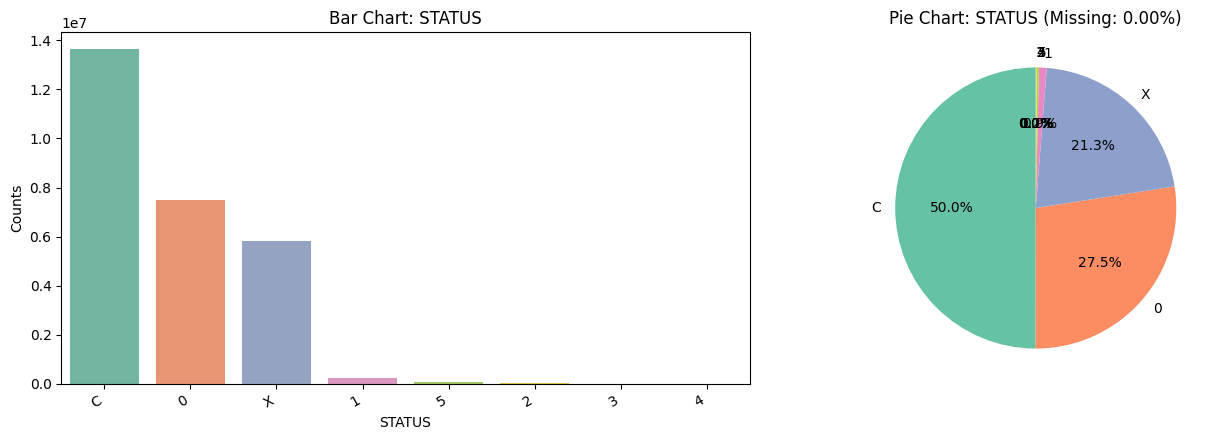

In [100]:
eda_categorical_feature(df_bureau_balance, 'STATUS')


📈 [NUMERICAL] Feature: MONTHS_BALANCE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,MONTHS_BALANCE
Count (Số lượng dòng thực tế),"27,299,925"
Mean (Trung bình),-30.74
Median (Trung vị),-25.00
Mode (Yếu vị),-1.00
Std Dev (Độ lệch chuẩn),23.86
Min,-96.00
Max,0.00
IQR (Tứ phân vị),35.00


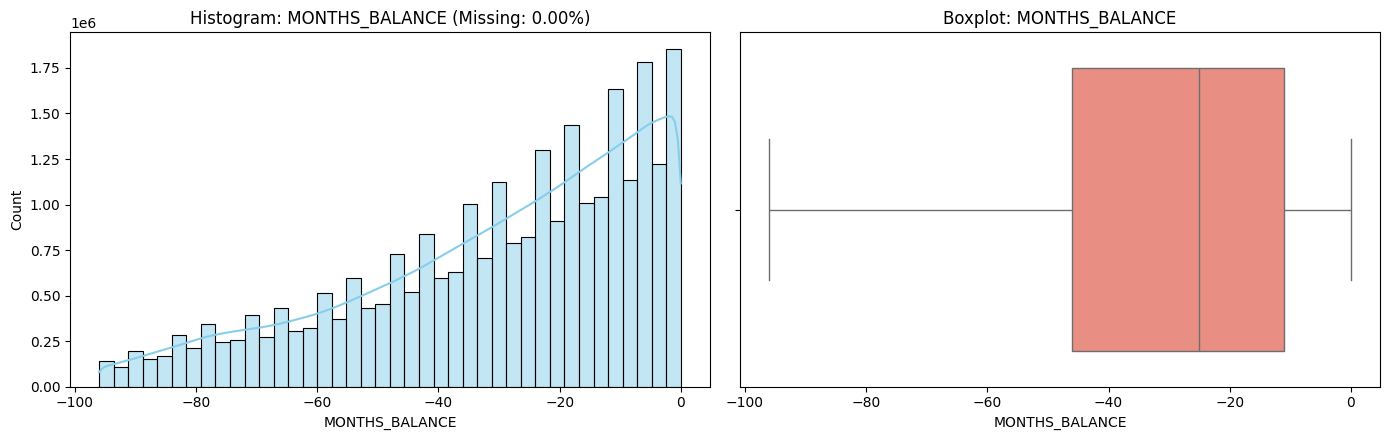

In [101]:
eda_numerical_feature(df_bureau_balance, 'MONTHS_BALANCE')


In [102]:
df_pos_cash_balance = pd.read_csv(POS_CASH_FILE)


📈 [NUMERICAL] Feature: MONTHS_BALANCE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,MONTHS_BALANCE
Count (Số lượng dòng thực tế),"10,001,358"
Mean (Trung bình),-35.01
Median (Trung vị),-28.00
Mode (Yếu vị),-10.00
Std Dev (Độ lệch chuẩn),26.07
Min,-96.00
Max,-1.00
IQR (Tứ phân vị),41.00


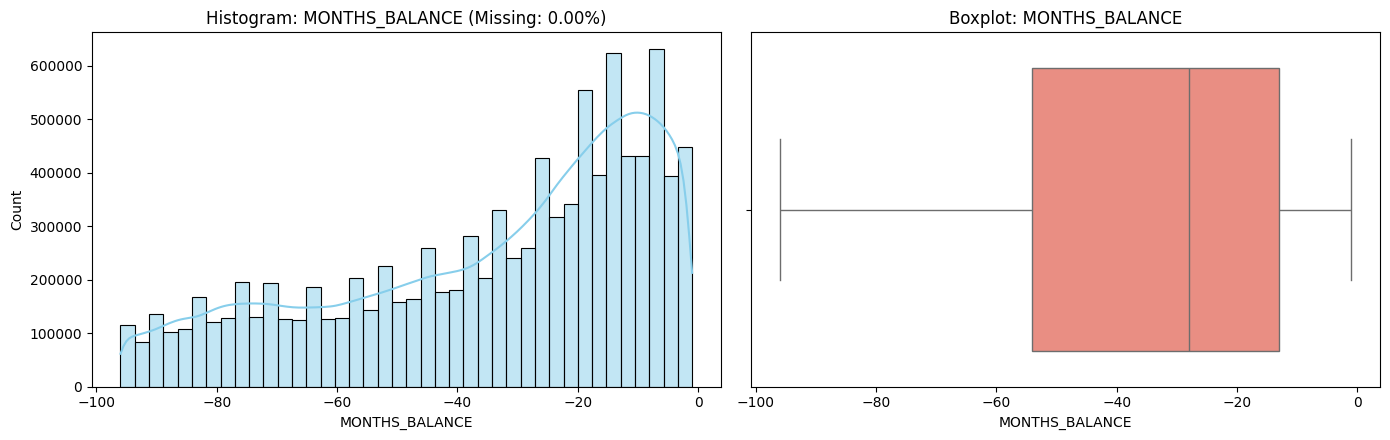

In [103]:
eda_numerical_feature(df_pos_cash_balance, 'MONTHS_BALANCE')


📈 [NUMERICAL] Feature: CNT_INSTALMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 26,071 dòng | Tỷ lệ khuyết: 0.26%
-----------------------------------------------------------------


,CNT_INSTALMENT
Count (Số lượng dòng thực tế),"9,975,287"
Mean (Trung bình),17.09
Median (Trung vị),12.00
Mode (Yếu vị),12.00
Std Dev (Độ lệch chuẩn),12.00
Min,1.00
Max,92.00
IQR (Tứ phân vị),14.00


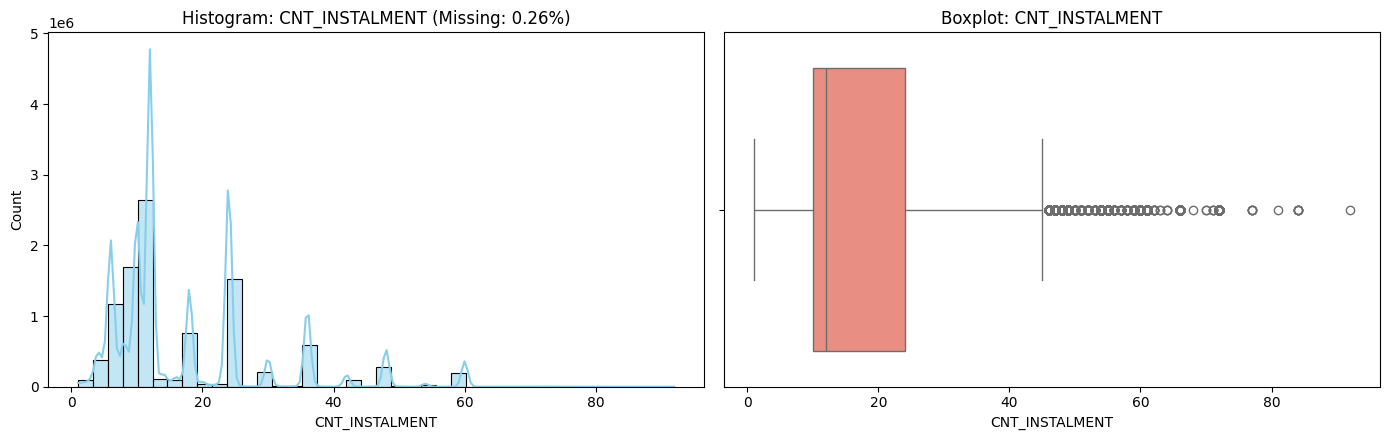

In [104]:
eda_numerical_feature(df_pos_cash_balance, 'CNT_INSTALMENT')


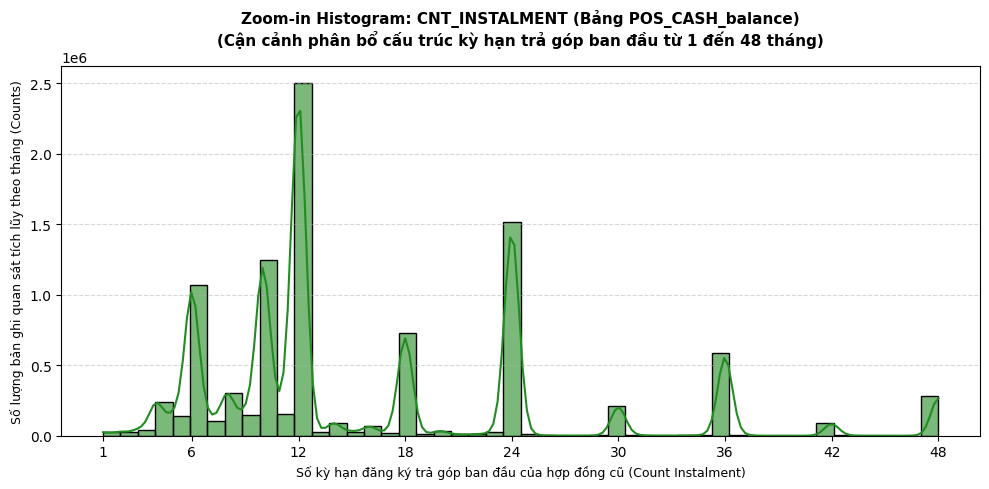

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# Khởi tạo kích thước khung hình quy chuẩn cho báo cáo đồ án tốt nghiệp
plt.figure(figsize=(10, 5))

# =========================================================================
# TIỀN XỬ LÝ DỮ LIỆU EDA (LÀM SẠCH BIẾN TRỐNG ĐỂ TRÁNH LỖI ĐỒ THỊ)
# =========================================================================
# Bước 1: Loại bỏ các dòng khuyết thiếu (NaN) cục bộ của biến CNT_INSTALMENT
df_clean_pos = df_pos_cash_balance[df_pos_cash_balance['CNT_INSTALMENT'].notna()]

# Bước 2: Lọc cô lập dải kỳ hạn thực tế phổ biến từ 1 đến 48 tháng (gói 4 năm tiêu chuẩn)
# Loại bỏ mốc ngoại lai quá dài (như gói vay cá biệt 92 tháng) để giải phóng độ nén hệ trục
clean_instalment = df_clean_pos[
    (df_clean_pos['CNT_INSTALMENT'] > 0) & 
    (df_clean_pos['CNT_INSTALMENT'] <= 48)
]['CNT_INSTALMENT'].astype(int)

# Sắp xếp thứ tự các nấc kỳ hạn xuất hiện để đường cong mật độ KDE tính toán chuẩn xác
unique_bins = sorted(clean_instalment.unique())

# =========================================================================
# TRỰC QUAN HÓA BIỂU ĐỒ HISTOGRAM & ĐƯỜNG CONG MẬT ĐỘ KDE
# =========================================================================
# Sử dụng màu xanh lá cây rừng sâu (forestgreen) đại diện cho nhóm thông tin kỳ hạn trả góp
# Cấu hình số lượng bins bằng chính số lượng nấc kỳ hạn thực tế giúp triệt tiêu bẫy Binning Effect
sns.histplot(
    clean_instalment, 
    bins=len(unique_bins), 
    kde=True, 
    color='forestgreen', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ ĐỒ THỊ CHUYÊN NGHIỆP (NOTION ALIGNED)
# =========================================================================
plt.title('Zoom-in Histogram: CNT_INSTALMENT (Bảng POS_CASH_balance)\n(Cận cảnh phân bổ cấu trúc kỳ hạn trả góp ban đầu từ 1 đến 48 tháng)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số kỳ hạn đăng ký trả góp ban đầu của hợp đồng cũ (Count Instalment)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Cấu hình hiển thị các nấc nhãn trục hoành rõ ràng theo các mốc tròn chu kỳ tài chính
plt.xticks([1, 6, 12, 18, 24, 30, 36, 42, 48])

# Bật lưới ngang mờ hỗ trợ đối chiếu quy mô tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng trống biên đồ thị để tránh mất chữ nhãn
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_INSTALMENT_FUTURE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 26,087 dòng | Tỷ lệ khuyết: 0.26%
-----------------------------------------------------------------


,CNT_INSTALMENT_FUTURE
Count (Số lượng dòng thực tế),"9,975,271"
Mean (Trung bình),10.48
Median (Trung vị),7.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),11.11
Min,0.00
Max,85.00
IQR (Tứ phân vị),11.00


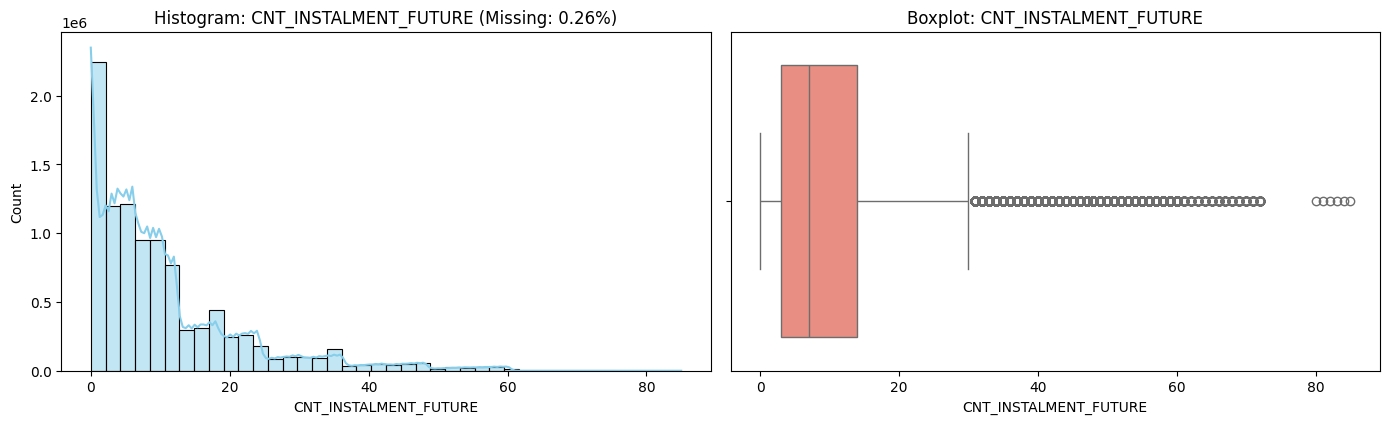

In [112]:
eda_numerical_feature(df_pos_cash_balance, 'CNT_INSTALMENT_FUTURE')


📊 [CATEGORICAL] Feature: NAME_CONTRACT_STATUS | Unique Groups: 9
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
NAME_CONTRACT_STATUS,,
Active,"9,151,119",91.50
Completed,"744,883",7.45
Signed,"87,260",0.87
Demand,"7,065",0.07
Returned to the store,"5,461",0.05
Approved,"4,917",0.05
Amortized debt,636,0.01
Canceled,15,0.00
XNA,2,0.00


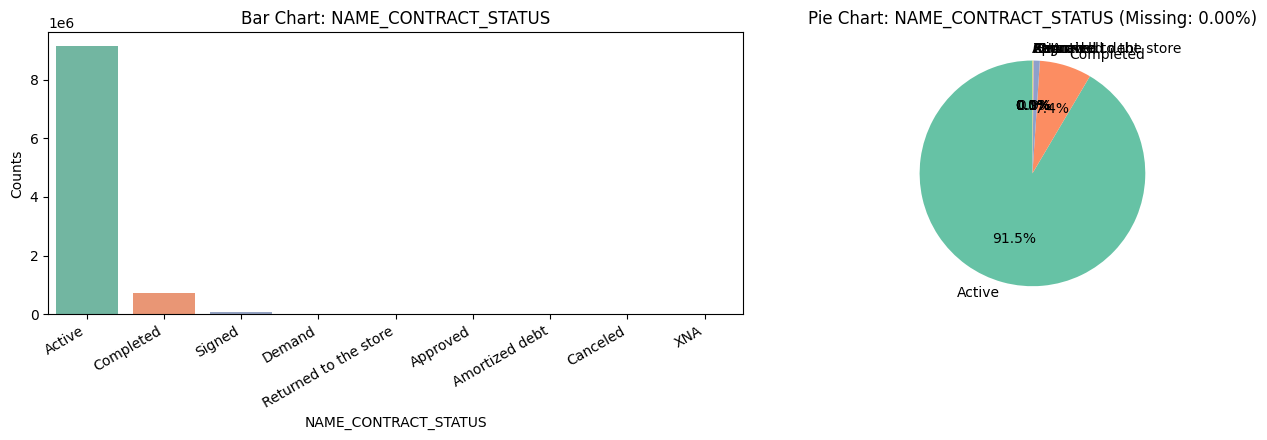

In [113]:
eda_categorical_feature(df_pos_cash_balance, 'NAME_CONTRACT_STATUS')


📈 [NUMERICAL] Feature: SK_DPD
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,SK_DPD
Count (Số lượng dòng thực tế),"10,001,358"
Mean (Trung bình),11.61
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),132.71
Min,0.00
Max,"4,231.00"
IQR (Tứ phân vị),0.00


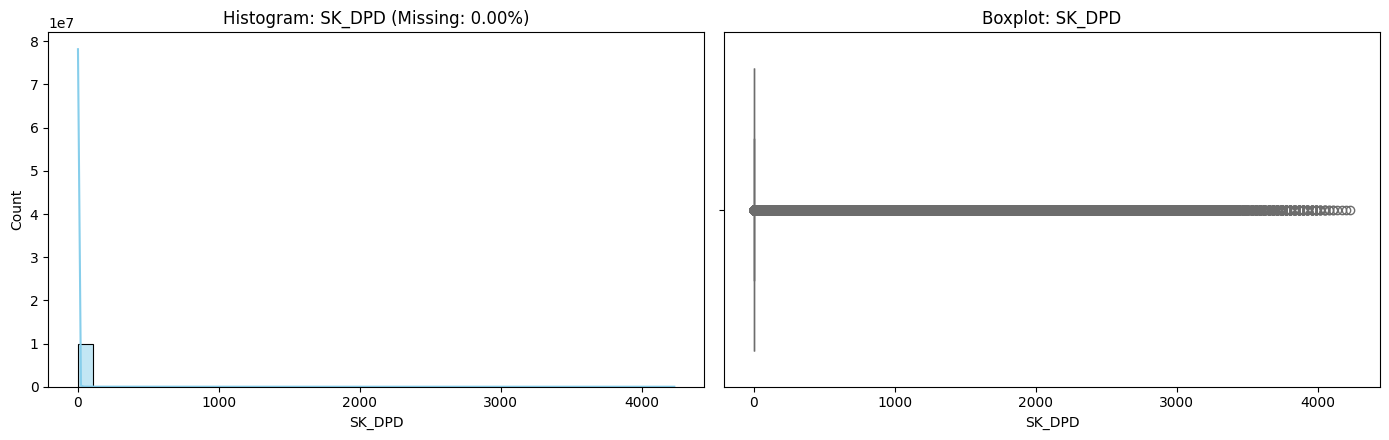

In [114]:
eda_numerical_feature(df_pos_cash_balance, 'SK_DPD')


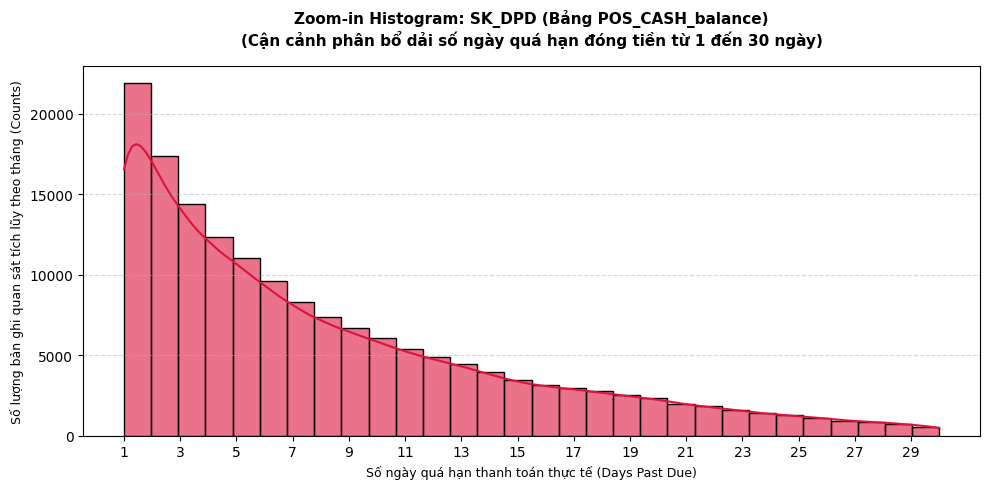

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

def eda_numerical_feature_zoomin(df, feature_name):
    try:
        # Khởi tạo kích thước khung hình tiêu chuẩn cho báo cáo đồ án
        plt.figure(figsize=(10, 5))
        
        # Lọc cô lập dữ liệu: Bỏ nhóm 0 ngày để giải phóng độ nén mật độ
        # Giới hạn trần hiển thị trực quan trong vòng 30 ngày quá hạn bản lề
        clean_data = df[
            (df[feature_name] > 0) & 
            (df[feature_name] <= 30) & 
            (df[feature_name].notna())
        ][feature_name]
        
        if clean_data.empty:
            print(f"⚠️ Không có bản ghi nào của trường '{feature_name}' nằm trong khoảng từ 1 đến 30 ngày để vẽ Zoom-in.")
            plt.close()
            return
            
        # Vẽ biểu đồ Histogram cận cảnh kết hợp đường cong mật độ KDE mượt mà
        # Màu crimson rực cháy đại diện cho tín hiệu quá hạn đóng tiền trả góp
        sns.histplot(
            clean_data, 
            bins=30, 
            kde=True, 
            color='crimson', 
            edgecolor='black', 
            alpha=0.6
        )
        
        # Cấu hình thẩm mỹ đồ thị chuyên nghiệp (Notion Aligned)
        plt.title(f'Zoom-in Histogram: {feature_name} (Bảng POS_CASH_balance)\n(Cận cảnh phân bổ dải số ngày quá hạn đóng tiền từ 1 đến 30 ngày)', 
                  fontsize=11, fontweight='bold', pad=15)
        plt.xlabel('Số ngày quá hạn thanh toán thực tế (Days Past Due)', fontsize=9)
        plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)
        
        # Cấu hình các nấc nhãn trục hoành rạch ròi theo chu kỳ thời gian
        plt.xticks(range(1, 31, 2))
        
        # Bật lưới ngang mờ hỗ trợ đối chiếu quy mô tần suất
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Đã xảy ra lỗi khi vẽ đồ thị: {e}")
        print("Trí kiểm tra lại xem bảng df_pos_cash_balance đã được load thành công ở các ô code phía trên chưa nhé.")

# Gọi hàm Zoom-in thực tế với đúng tên biến bảng POS CASH của Trí
eda_numerical_feature_zoomin(df_pos_cash_balance, 'SK_DPD')

📈 [NUMERICAL] Feature: SK_DPD_DEF
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,SK_DPD_DEF
Count (Số lượng dòng thực tế),"10,001,358"
Mean (Trung bình),0.65
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),32.76
Min,0.00
Max,"3,595.00"
IQR (Tứ phân vị),0.00


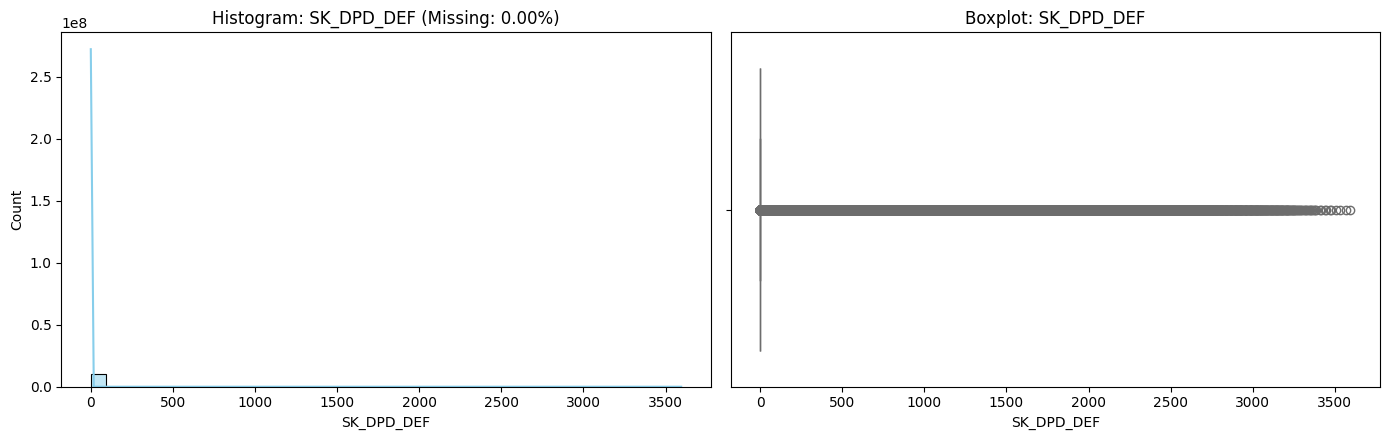

In [121]:
eda_numerical_feature(df_pos_cash_balance, 'SK_DPD_DEF')


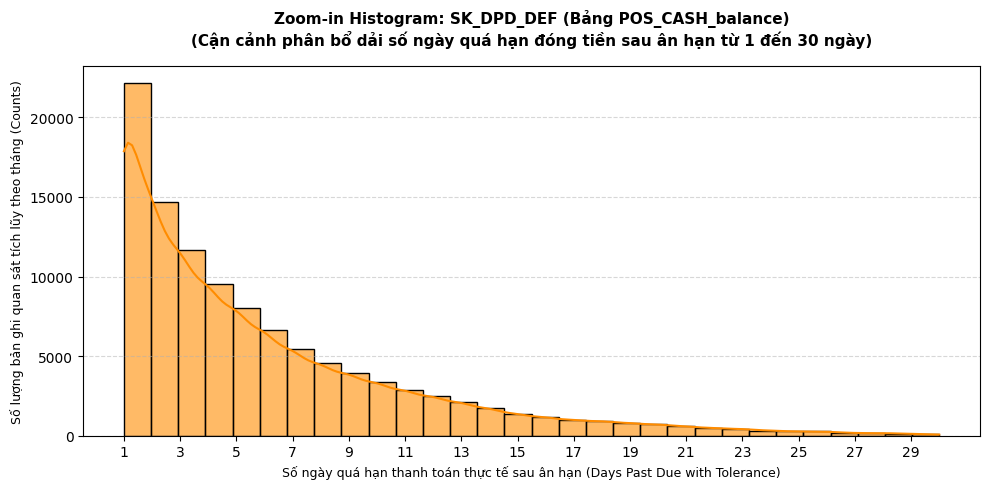

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

def eda_numerical_feature_zoomin(df, feature_name):
    try:
        # Khởi tạo kích thước khung hình tiêu chuẩn cho báo cáo đồ án tốt nghiệp
        plt.figure(figsize=(10, 5))
        
        # Lọc cô lập dữ liệu mức POS CASH cho biến có ngưỡng ân hạn SK_DPD_DEF:
        # Loại bỏ tuyệt đối mốc 0 ngày để giải phóng không gian hệ trục tung (Y)
        # Thiết lập trần hiển thị trực quan trong dải 30 ngày quá hạn bản lề (chu kỳ nợ nhóm 1)
        clean_data = df[
            (df[feature_name] > 0) & 
            (df[feature_name] <= 30) & 
            (df[feature_name].notna())
        ][feature_name]
        
        # Kiểm tra điều kiện biên an toàn để tránh crash hệ thống đồ thị nếu dải lọc trống
        if clean_data.empty:
            print(f"⚠️ Không tìm thấy bản ghi nào của trường '{feature_name}' nằm trong dải từ 1 đến 30 ngày quá hạn phạt.")
            plt.close()
            return
            
        # Vẽ biểu đồ Histogram cận cảnh tích hợp đường cong ước lượng mật độ nhân KDE mượt mà
        # Sử dụng palette màu darkorange đặc trưng cho cấu phần trả góp nội bộ POS_CASH
        sns.histplot(
            clean_data, 
            bins=30, 
            kde=True, 
            color='darkorange', 
            edgecolor='black', 
            alpha=0.6
        )
        
        # Cấu hình hệ thống tiêu đề và nhãn hiển thị trực quan chuyên nghiệp (Notion Aligned)
        plt.title(f'Zoom-in Histogram: {feature_name} (Bảng POS_CASH_balance)\n(Cận cảnh phân bổ dải số ngày quá hạn đóng tiền sau ân hạn từ 1 đến 30 ngày)', 
                  fontsize=11, fontweight='bold', pad=15)
        plt.xlabel('Số ngày quá hạn thanh toán thực tế sau ân hạn (Days Past Due with Tolerance)', fontsize=9)
        plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)
        
        # Định cấu hình các nấc nhãn trục hoành chạy rạch ròi theo từng số ngày lẻ
        plt.xticks(range(1, 31, 2))
        
        # Bật lưới ngang mờ hỗ trợ hội đồng đối chiếu chính xác quy mô tần suất của các cột rủi ro
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Tối ưu hóa không gian biên đồ thị để tránh hiện tượng mất nhãn chữ
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Đã xảy ra lỗi hệ thống khi xử lý đồ thị: {e}")
        print("Trí kiểm tra lại xem biến bảng 'df_pos_cash_balance' đã được nạp vào bộ nhớ RAM ở các ô code phía trên chưa nhé.")

# Chạy lệnh thực thi vẽ biểu đồ Zoom-in cận cảnh cho biến SK_DPD_DEF của Trí
eda_numerical_feature_zoomin(df_pos_cash_balance, 'SK_DPD_DEF')

In [123]:
df_credit_card_balance = pd.read_csv(CREDIT_CARD_FILE)


📈 [NUMERICAL] Feature: AMT_BALANCE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_BALANCE
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),"58,300.16"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"106,307.03"
Min,"-420,250.18"
Max,"1,505,902.19"
IQR (Tứ phân vị),"89,046.69"


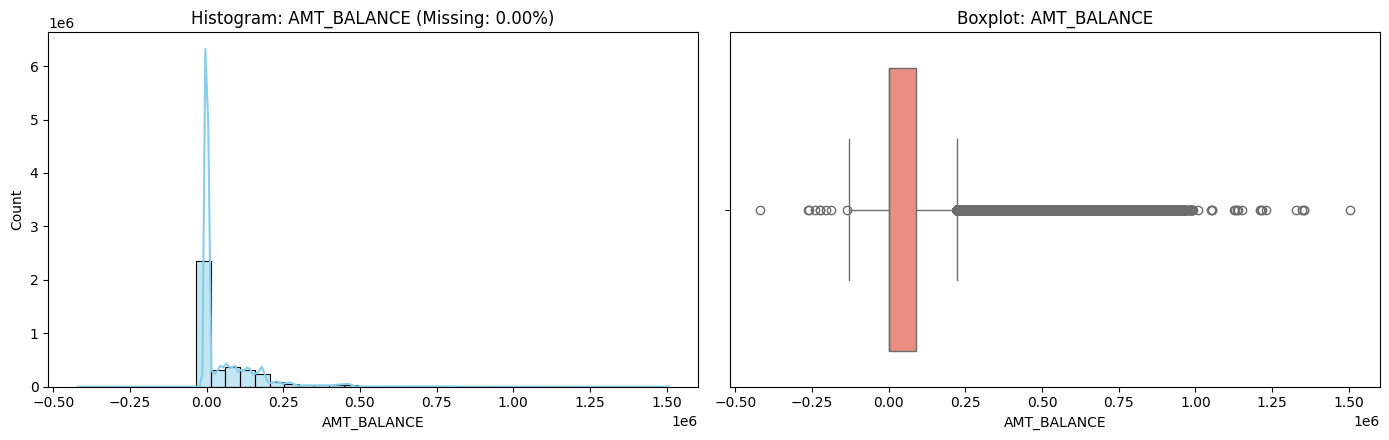

In [125]:
eda_numerical_feature(df_credit_card_balance, 'AMT_BALANCE')


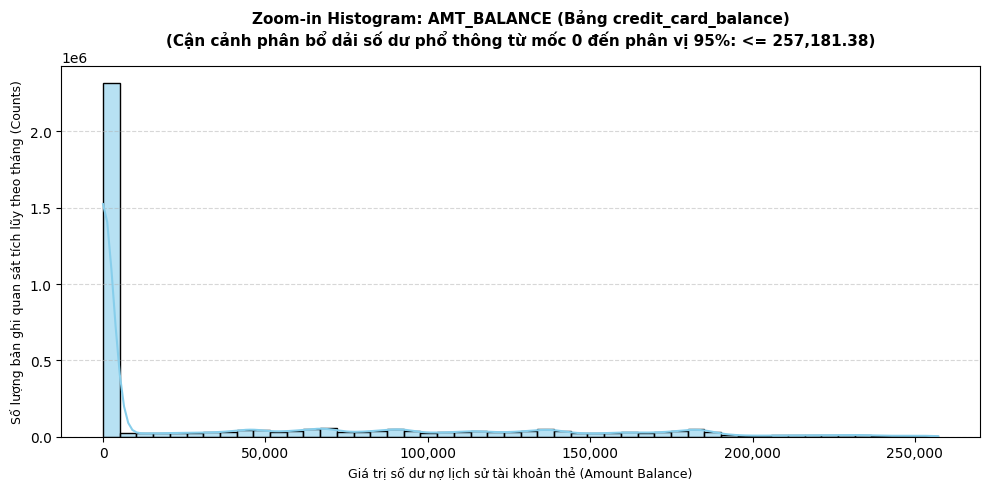

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP VẼ BIỂU ĐỒ CẬN CẢNH (ZOOM-IN) SỐ DƯ THẺ TÍN DỤNG
# =========================================================================

try:
    # Kích thước khung hình tiêu chuẩn đồng bộ với các đồ thị trong đồ án
    plt.figure(figsize=(10, 5))
    
    # Bước 1: Lọc bỏ NaN cục bộ để tránh lỗi tính toán phân vị trên tập dữ liệu thẻ
    df_clean_cc = df_credit_card_balance[df_credit_card_balance['AMT_BALANCE'].notna()]
    
    # Bước 2: Xác định ngưỡng trần phân vị 95% để cắt bỏ dải đuôi ngoại lai dương khổng lồ
    upper_bound_95 = df_clean_cc['AMT_BALANCE'].quantile(0.95)
    
    # Bước 3: Cô lập dải dữ liệu số dư phổ thông (từ mốc 0 đến phân vị 95%)
    # Giải phóng hệ trục X khỏi sức nén của các tài khoản có dư nợ cá biệt quá lớn
    clean_data = df_clean_cc[
        (df_clean_cc['AMT_BALANCE'] >= 0) & 
        (df_clean_cc['AMT_BALANCE'] <= upper_bound_95)
    ]['AMT_BALANCE']
    
    # Bước 4: Vẽ biểu đồ Histogram tích hợp đường cong ước lượng mật độ nhân KDE mượt mà
    # Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin số dư tiền tệ tĩnh
    sns.histplot(
        clean_data, 
        bins=50, 
        kde=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.6
    )
    
    # =========================================================================
    # CẤU HÌNH THẨM MỸ ĐỒ THỊ CHUYÊN NGHIỆP ĐỂ DÁN NOTION
    # =========================================================================
    plt.title(f'Zoom-in Histogram: AMT_BALANCE (Bảng credit_card_balance)\n(Cận cảnh phân bổ dải số dư phổ thông từ mốc 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
              fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Giá trị số dư nợ lịch sử tài khoản thẻ (Amount Balance)', fontsize=9)
    plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)
    
    # Định dạng lại nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Bật lưới lưới ngang mờ để hỗ trợ đối chiếu phân vị tần suất
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Tối ưu hóa khoảng biên, tránh mất chữ nhãn
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"❌ Đã xảy ra lỗi hệ thống khi vẽ đồ thị: {e}")
    print("Trí kiểm tra lại xem bảng 'df_credit_card_balance' đã được load thành công ở các ô code phía trên chưa nhé.")

📈 [NUMERICAL] Feature: AMT_CREDIT_LIMIT_ACTUAL
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_CREDIT_LIMIT_ACTUAL
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),"153,807.96"
Median (Trung vị),"112,500.00"
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"165,145.70"
Min,0.00
Max,"1,350,000.00"
IQR (Tứ phân vị),"135,000.00"


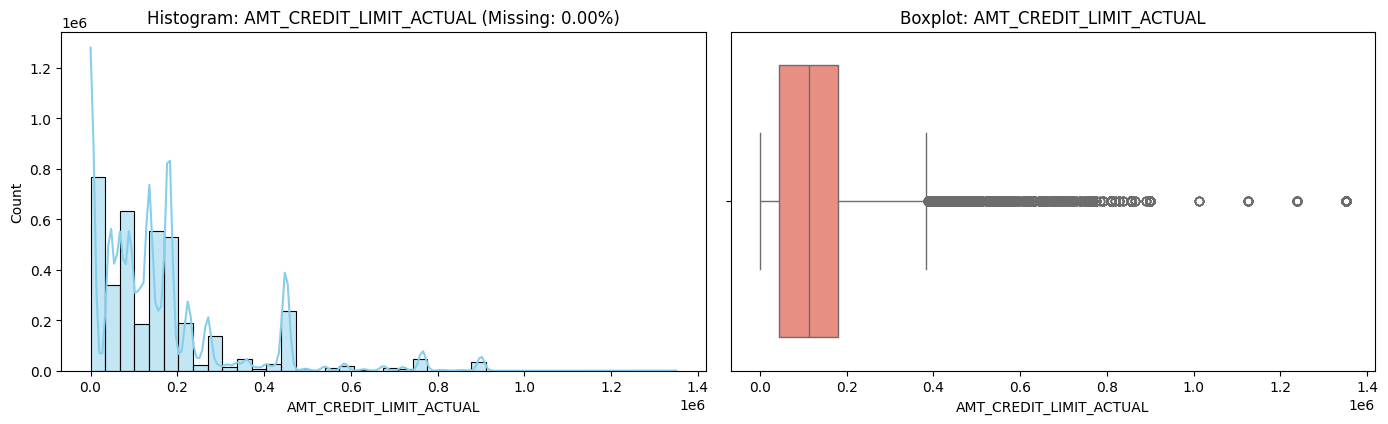

In [131]:
eda_numerical_feature(df_credit_card_balance, 'AMT_CREDIT_LIMIT_ACTUAL')


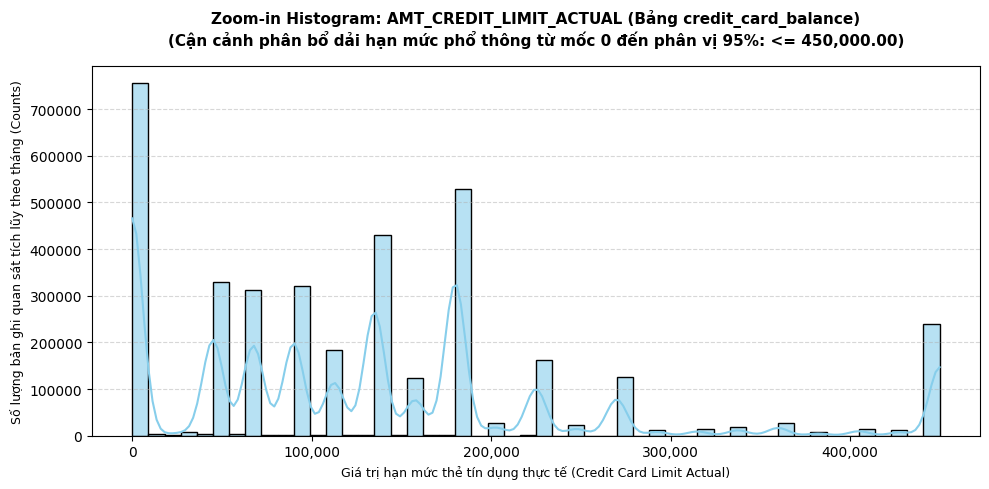

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP VẼ BIỂU ĐỒ CẬN CẢNH (ZOOM-IN) HẠN MỨC THẺ TÍN DỤNG
# =========================================================================

try:
    # Kích thước khung hình tiêu chuẩn đồng bộ với toàn cục báo cáo đồ án
    plt.figure(figsize=(10, 5))
    
    # Bước 1: Loại bỏ NaN cục bộ của trường hạn mức thực tế để tránh lỗi phân vị
    df_clean_limit = df_credit_card_balance[df_credit_card_balance['AMT_CREDIT_LIMIT_ACTUAL'].notna()]
    
    # Bước 2: Xác định ngưỡng trần phân vị 95% để giải phóng độ nén hệ trục hoành
    upper_bound_95 = df_clean_limit['AMT_CREDIT_LIMIT_ACTUAL'].quantile(0.95)
    
    # Bước 3: Lọc cô lập dải dữ liệu hạn mức phổ thông (từ mốc 0 đến phân vị 95%)
    clean_data = df_clean_limit[
        (df_clean_limit['AMT_CREDIT_LIMIT_ACTUAL'] >= 0) & 
        (df_clean_limit['AMT_CREDIT_LIMIT_ACTUAL'] <= upper_bound_95)
    ]['AMT_CREDIT_LIMIT_ACTUAL']
    
    # Bước 4: Vẽ biểu đồ Histogram tích hợp đường cong ước lượng mật độ nhân KDE
    # Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm đặc trưng tiền tệ/hạn mức tĩnh
    sns.histplot(
        clean_data, 
        bins=50, 
        kde=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.6
    )
    
    # =========================================================================
    # CẤU HÌNH THẨM MỸ ĐỒ THỊ CHUYÊN NGHIỆP ĐỂ DÁN NOTION
    # =========================================================================
    plt.title(f'Zoom-in Histogram: AMT_CREDIT_LIMIT_ACTUAL (Bảng credit_card_balance)\n(Cận cảnh phân bổ dải hạn mức phổ thông từ mốc 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
              fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Giá trị hạn mức thẻ tín dụng thực tế (Credit Card Limit Actual)', fontsize=9)
    plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)
    
    # Định dạng lại nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Bật lưới lưới ngang mờ để hỗ trợ hội đồng đối chiếu tần suất các bậc hạn mức
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Tối ưu hóa khoảng biên đồ thị sạch chữ
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"❌ Đã xảy ra lỗi hệ thống khi vẽ đồ thị: {e}")
    print("Trí kiểm tra lại xem tên biến bảng thô thực tế có đúng là 'df_credit_card_balance' chưa nhé.")

📈 [NUMERICAL] Feature: AMT_DRAWINGS_ATM_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 749,816 dòng | Tỷ lệ khuyết: 19.52%
-----------------------------------------------------------------


,AMT_DRAWINGS_ATM_CURRENT
Count (Số lượng dòng thực tế),"3,090,496"
Mean (Trung bình),"5,961.32"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"28,225.69"
Min,"-6,827.31"
Max,"2,115,000.00"
IQR (Tứ phân vị),0.00


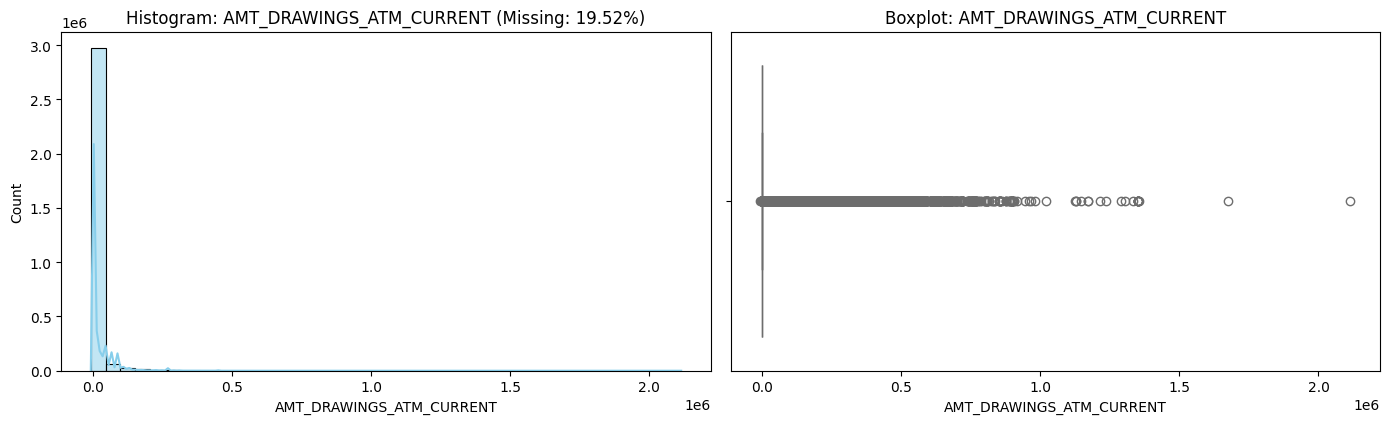

In [133]:
eda_numerical_feature(df_credit_card_balance, 'AMT_DRAWINGS_ATM_CURRENT')


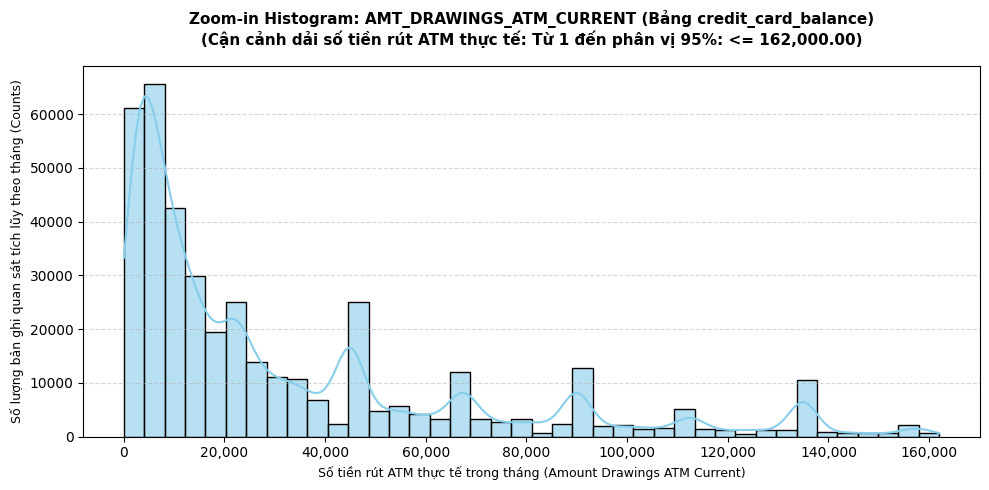

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# MÃ NGUỒN ZOOM-IN NÂNG CAO: GIẢI PHÓNG TOÀN DIỆN CHO BIẾN RÚT TIỀN ATM
# =========================================================================

# Khởi tạo kích thước khung hình tiêu chuẩn đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo hàm gốc của Trí
target_col = 'AMT_DRAWINGS_ATM_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN)
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh hành vi rút tiền mặt (> 0)
# Việc này giúp gạt bỏ hoàn toàn khối lượng khổng lồ của mốc 0.0 gây nghẽn hệ trục
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM THỰC SỰ RÚT TIỀN để tìm trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế của hành vi rút tiền mặt (> 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin số dư/tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP ĐỂ DÁN NOTION
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải số tiền rút ATM thực tế: Từ 1 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền rút ATM thực tế trong tháng (Amount Drawings ATM Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_DRAWINGS_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_DRAWINGS_CURRENT
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),"7,433.39"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"33,846.08"
Min,"-6,211.62"
Max,"2,287,098.31"
IQR (Tứ phân vị),0.00


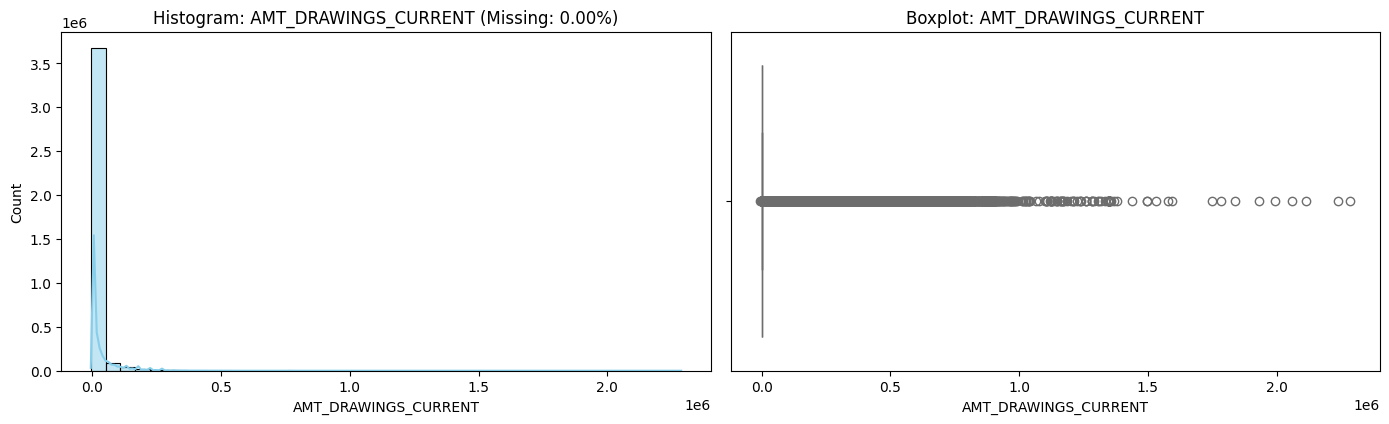

In [140]:
eda_numerical_feature(df_credit_card_balance, 'AMT_DRAWINGS_CURRENT')


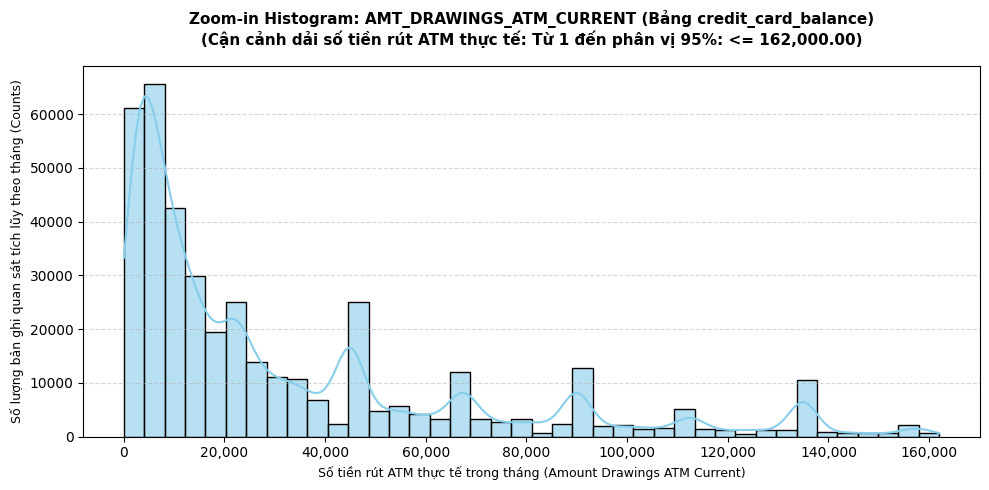

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN RÚT TIỀN ATM (LOẠI BỎ 0.0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_DRAWINGS_ATM_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh hành vi rút tiền mặt (> 0)
# Việc này giúp gạt bỏ hoàn toàn khối lượng khổng lồ của mốc 0.0 gây nghẽn trục tung
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM THỰC SỰ RÚT TIỀN để tìm trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế của hành vi rút tiền mặt (> 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP ĐỂ DÁN NOTION / BÁO CÁO
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải số tiền rút ATM thực tế: Từ 1 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền rút ATM thực tế trong tháng (Amount Drawings ATM Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_DRAWINGS_OTHER_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 749,816 dòng | Tỷ lệ khuyết: 19.52%
-----------------------------------------------------------------


,AMT_DRAWINGS_OTHER_CURRENT
Count (Số lượng dòng thực tế),"3,090,496"
Mean (Trung bình),288.17
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"8,201.99"
Min,0.00
Max,"1,529,847.00"
IQR (Tứ phân vị),0.00


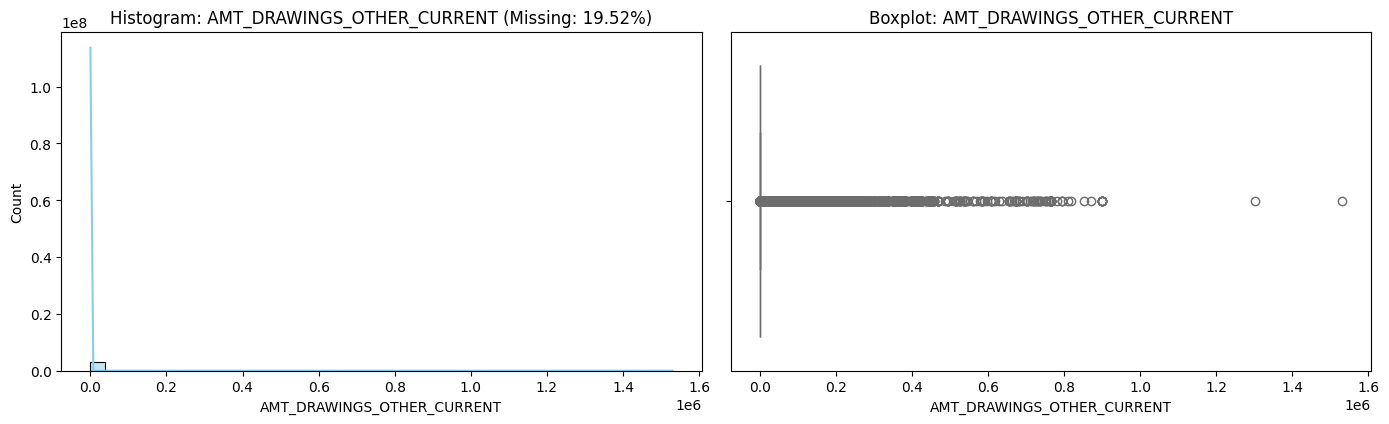

In [142]:
eda_numerical_feature(df_credit_card_balance, 'AMT_DRAWINGS_OTHER_CURRENT')


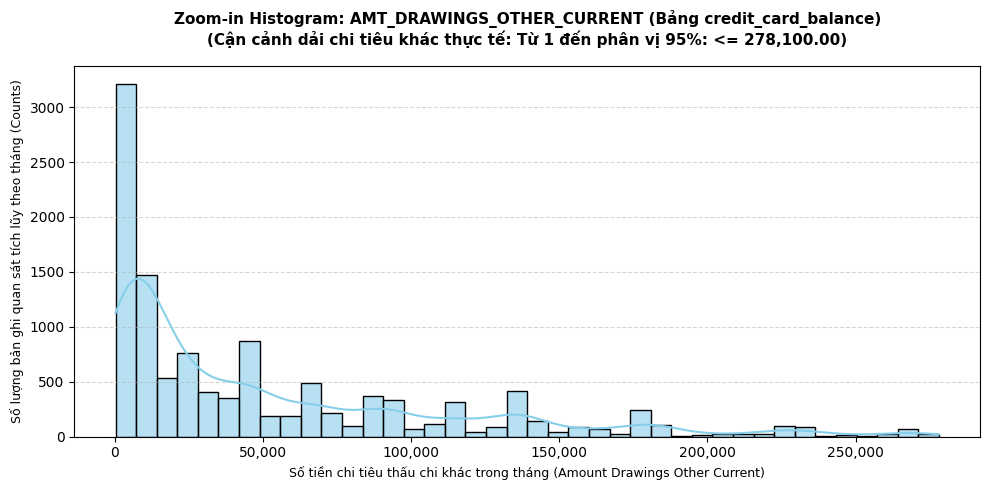

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN CHI TIÊU KHÁC (LOẠI BỎ 0.0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_DRAWINGS_OTHER_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh giao dịch chi tiêu khác (> 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các tháng không tiêu dùng
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế của hành vi chi tiêu (> 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP ĐỂ DÁN NOTION / BÁO CÁO
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải chi tiêu khác thực tế: Từ 1 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền chi tiêu thấu chi khác trong tháng (Amount Drawings Other Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_DRAWINGS_POS_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 749,816 dòng | Tỷ lệ khuyết: 19.52%
-----------------------------------------------------------------


,AMT_DRAWINGS_POS_CURRENT
Count (Số lượng dòng thực tế),"3,090,496"
Mean (Trung bình),"2,968.80"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"20,796.89"
Min,0.00
Max,"2,239,274.16"
IQR (Tứ phân vị),0.00


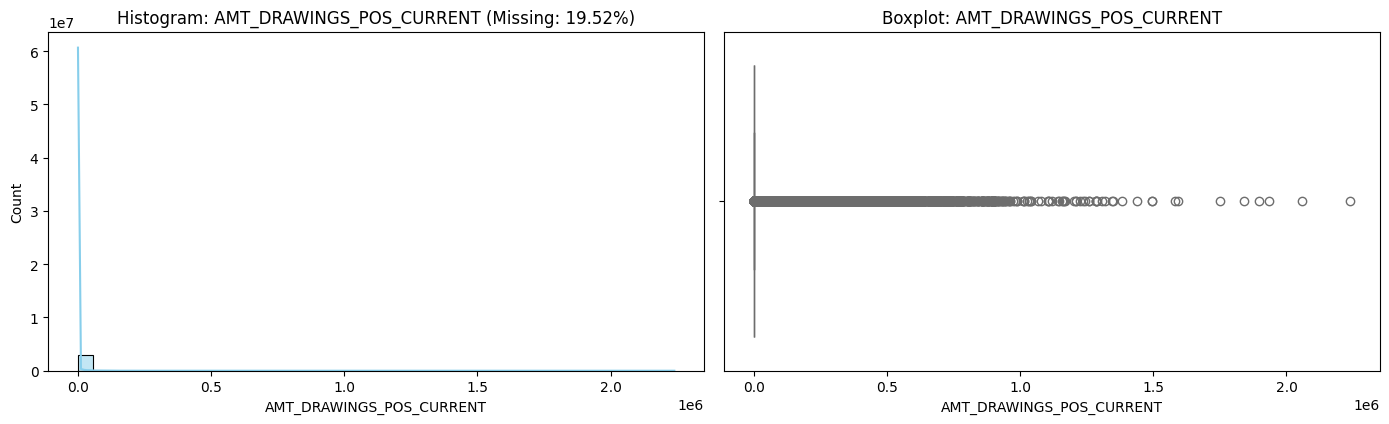

In [145]:
eda_numerical_feature(df_credit_card_balance, 'AMT_DRAWINGS_POS_CURRENT')


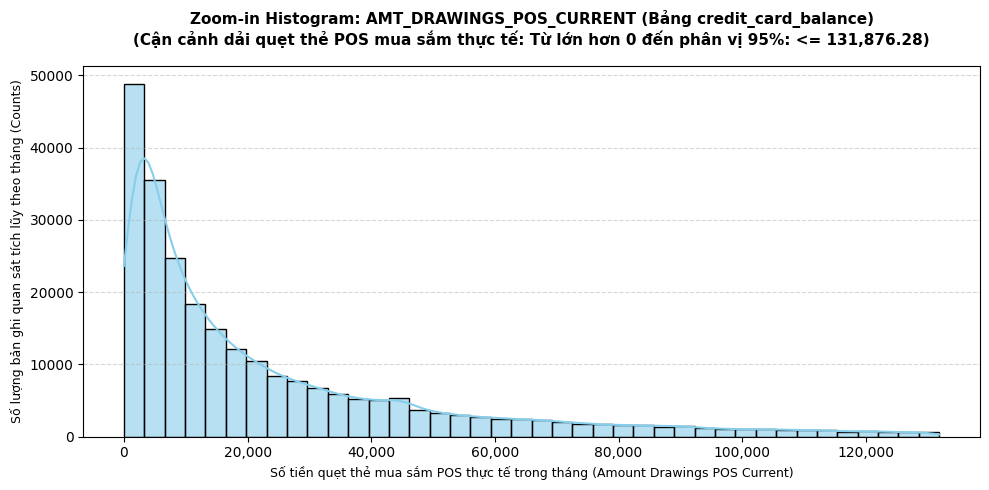

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN QUẸT THẺ MUA SẮM POS (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_DRAWINGS_POS_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh hành vi quẹt thẻ POS (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ không phát sinh giao dịch
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế của hành vi mua sắm (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải quẹt thẻ POS mua sắm thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền quẹt thẻ mua sắm POS thực tế trong tháng (Amount Drawings POS Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_INST_MIN_REGULARITY
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 305,236 dòng | Tỷ lệ khuyết: 7.95%
-----------------------------------------------------------------


,AMT_INST_MIN_REGULARITY
Count (Số lượng dòng thực tế),"3,535,076"
Mean (Trung bình),"3,540.20"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"5,600.15"
Min,0.00
Max,"202,882.01"
IQR (Tứ phân vị),"6,633.91"


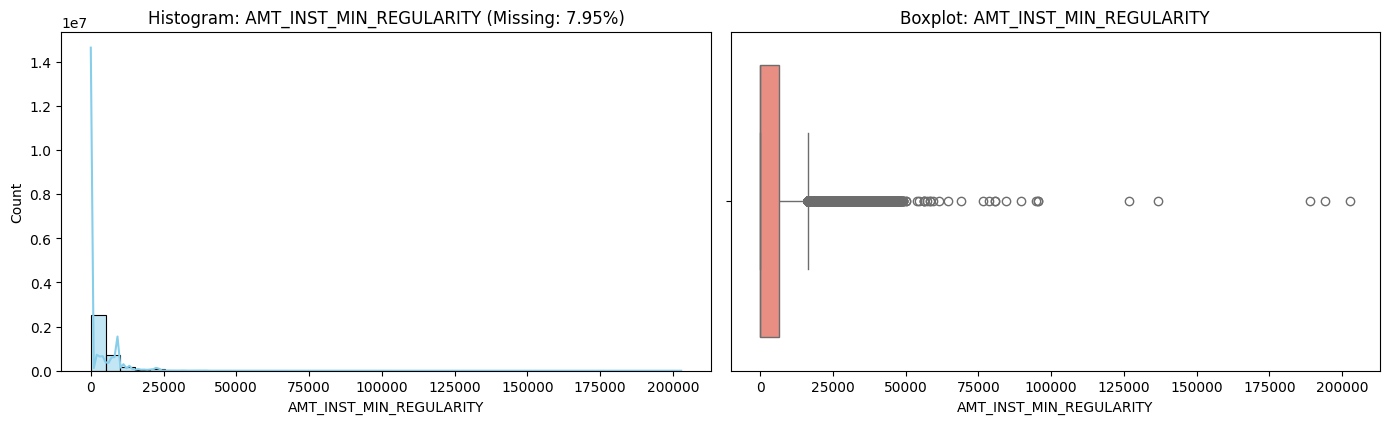

In [147]:
eda_numerical_feature(df_credit_card_balance, 'AMT_INST_MIN_REGULARITY')


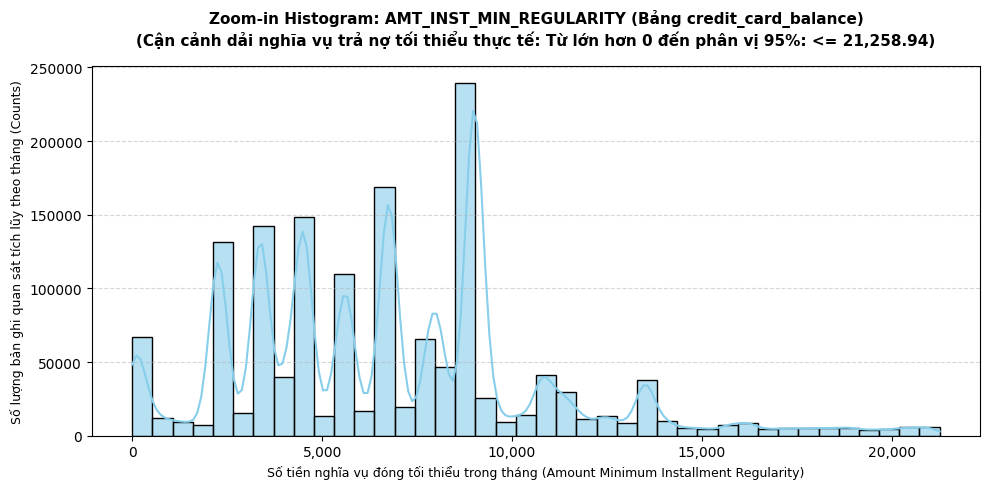

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TRẢ GÓP TỐI THIỂU (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_INST_MIN_REGULARITY'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh nghĩa vụ trả góp tối thiểu (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các tháng dư nợ thấu chi bằng 0.0
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải nghĩa vụ trả nợ tối thiểu thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền nghĩa vụ đóng tối thiểu trong tháng (Amount Minimum Installment Regularity)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_PAYMENT_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 767,988 dòng | Tỷ lệ khuyết: 20.00%
-----------------------------------------------------------------


,AMT_PAYMENT_CURRENT
Count (Số lượng dòng thực tế),"3,072,324"
Mean (Trung bình),"10,280.54"
Median (Trung vị),"2,702.70"
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"36,078.08"
Min,0.00
Max,"4,289,207.45"
IQR (Tứ phân vị),"8,847.63"


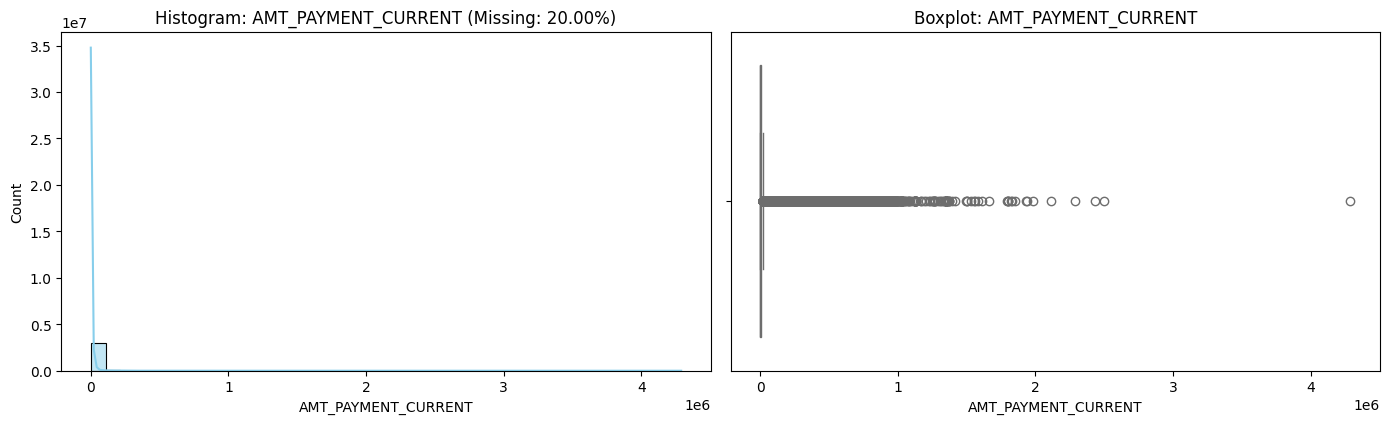

In [149]:
eda_numerical_feature(df_credit_card_balance, 'AMT_PAYMENT_CURRENT')


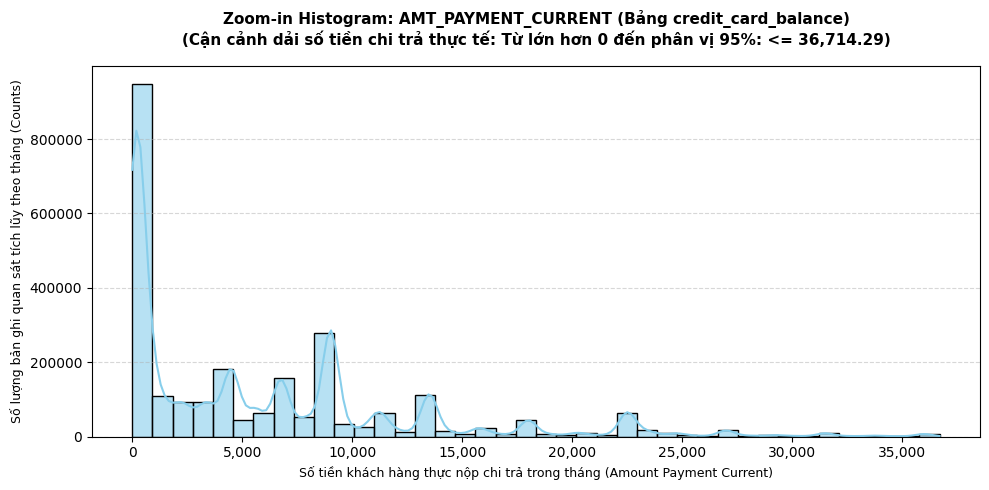

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ TIỀN CHI TRẢ HẰNG THÁNG (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_PAYMENT_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh lệnh nộp tiền chi trả (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ không phát sinh giao dịch nộp tiền
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải số tiền chi trả thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền khách hàng thực nộp chi trả trong tháng (Amount Payment Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_PAYMENT_TOTAL_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_PAYMENT_TOTAL_CURRENT
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),"7,588.86"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"32,005.99"
Min,0.00
Max,"4,278,315.69"
IQR (Tứ phân vị),"6,750.00"


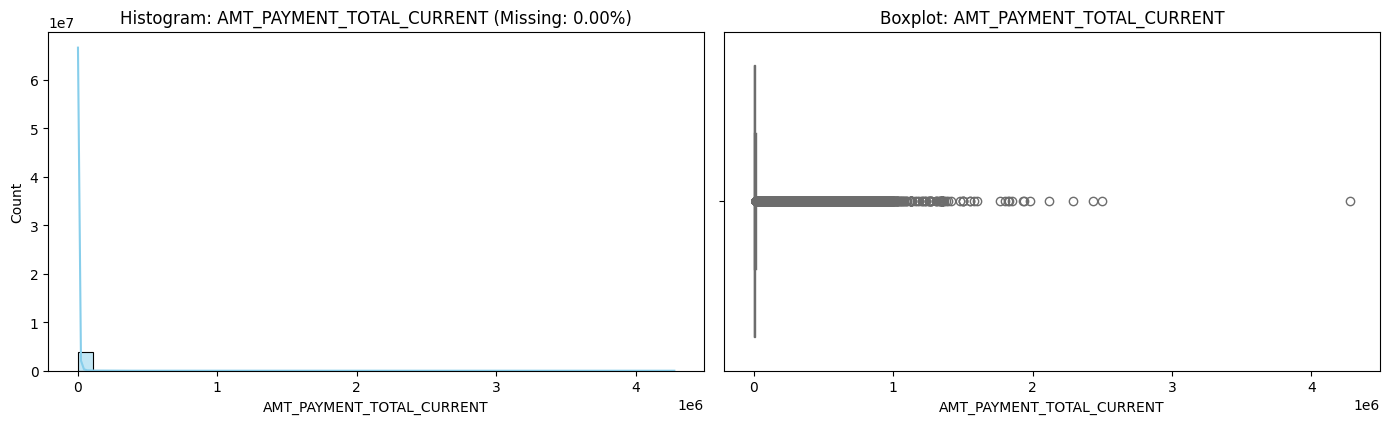

In [151]:
eda_numerical_feature(df_credit_card_balance, 'AMT_PAYMENT_TOTAL_CURRENT')


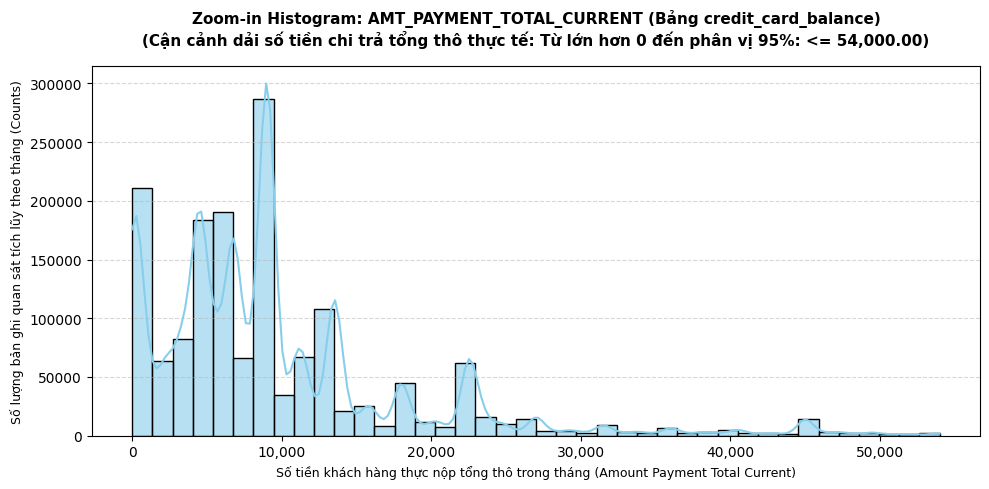

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ TIỀN CHI TRẢ TỔNG THÔ (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_PAYMENT_TOTAL_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh lệnh nộp tiền tổng thô (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ không phát sinh giao dịch nộp tiền
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải số tiền chi trả tổng thô thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền khách hàng thực nộp tổng thô trong tháng (Amount Payment Total Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_RECEIVABLE_PRINCIPAL
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_RECEIVABLE_PRINCIPAL
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),"55,965.88"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"102,533.62"
Min,"-423,305.82"
Max,"1,472,316.79"
IQR (Tứ phân vị),"85,359.24"


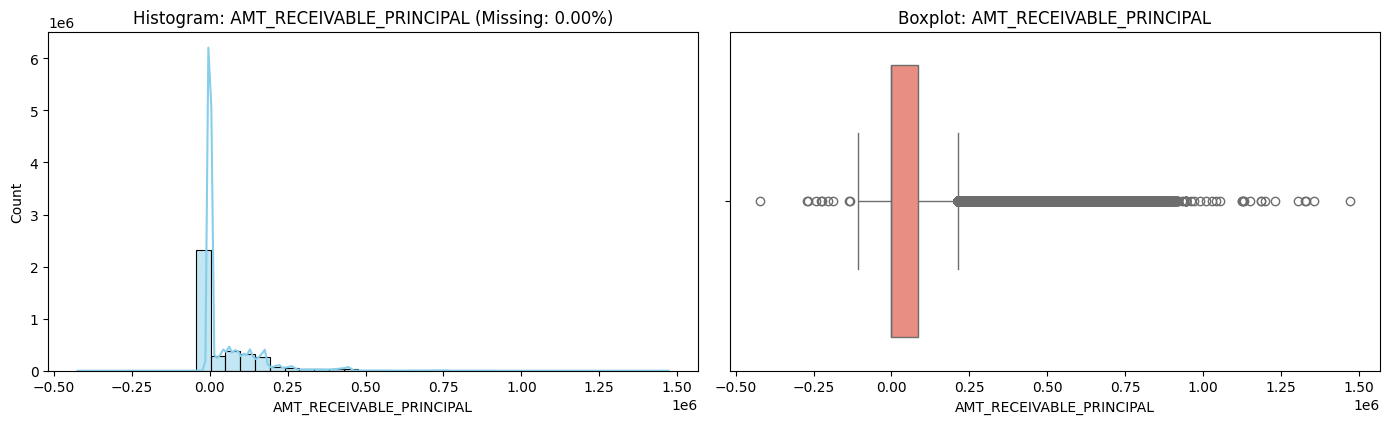

In [153]:
eda_numerical_feature(df_credit_card_balance, 'AMT_RECEIVABLE_PRINCIPAL')


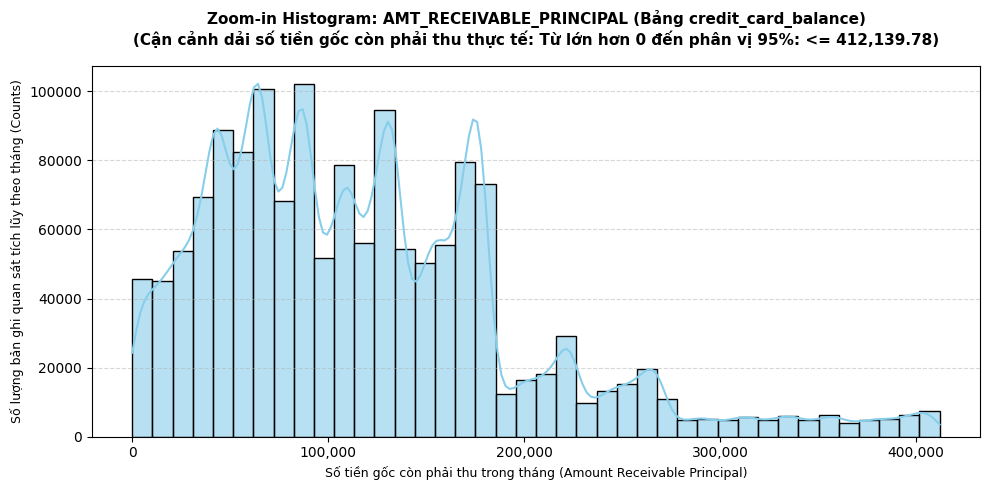

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ TIỀN GỐC PHẢI THU (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_RECEIVABLE_PRINCIPAL'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh dư nợ gốc phải thu (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản tĩnh hoặc không nợ
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải số tiền gốc còn phải thu thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền gốc còn phải thu trong tháng (Amount Receivable Principal)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_RECIVABLE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_RECIVABLE
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),"58,088.81"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"105,965.37"
Min,"-420,250.18"
Max,"1,493,338.19"
IQR (Tứ phân vị),"88,899.49"


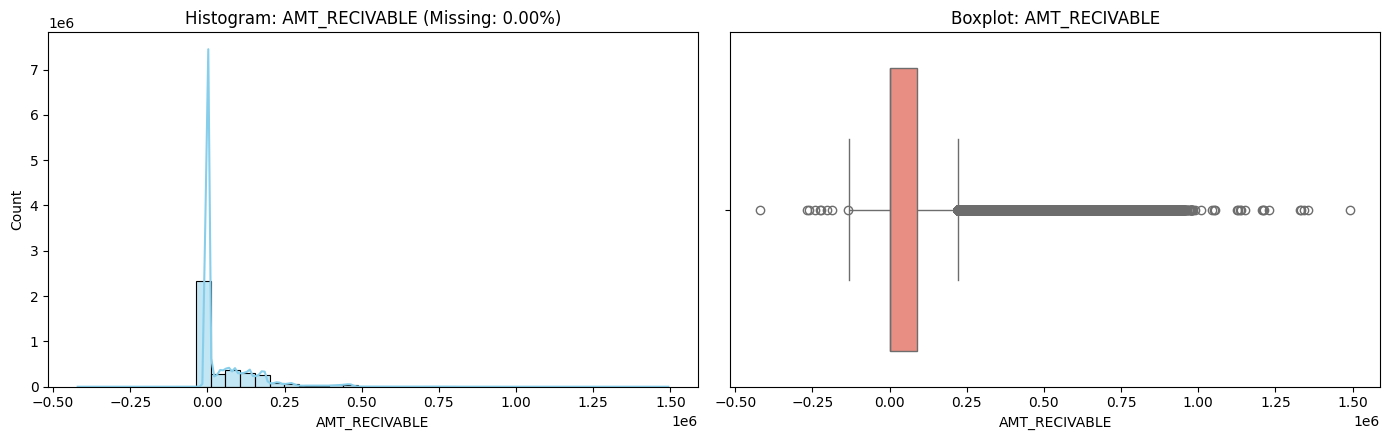

In [155]:
eda_numerical_feature(df_credit_card_balance, 'AMT_RECIVABLE')


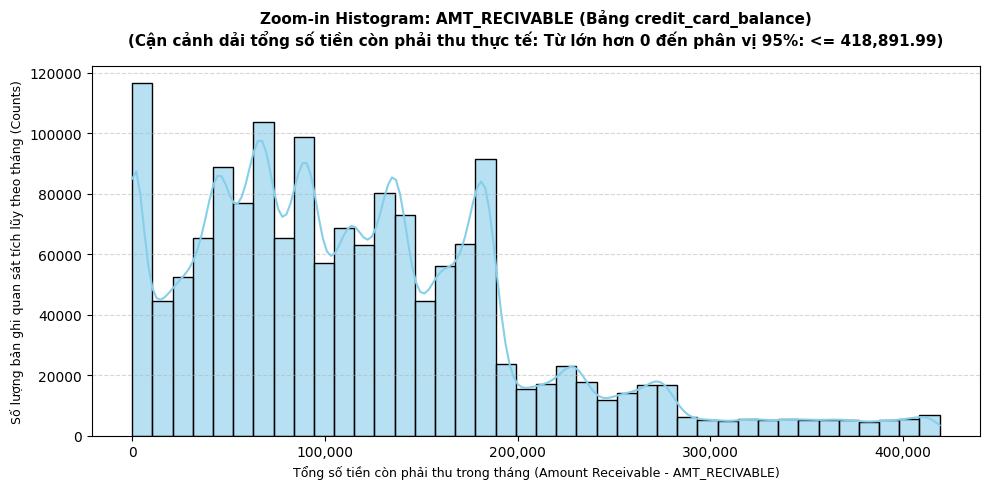

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TỔNG PHẢI THU (SỬA LỖI CHÍNH TẢ)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# SỬA LỖI: Sử dụng chính xác tên cột bị viết thiếu chữ "e" trong dữ liệu gốc Kaggle
target_col = 'AMT_RECIVABLE'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh tổng nợ phải thu (lớn hơn 0)
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải tổng số tiền còn phải thu thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Tổng số tiền còn phải thu trong tháng (Amount Receivable - AMT_RECIVABLE)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_TOTAL_RECEIVABLE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_TOTAL_RECEIVABLE
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),"58,098.29"
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"105,971.80"
Min,"-420,250.18"
Max,"1,493,338.19"
IQR (Tứ phân vị),"88,914.51"


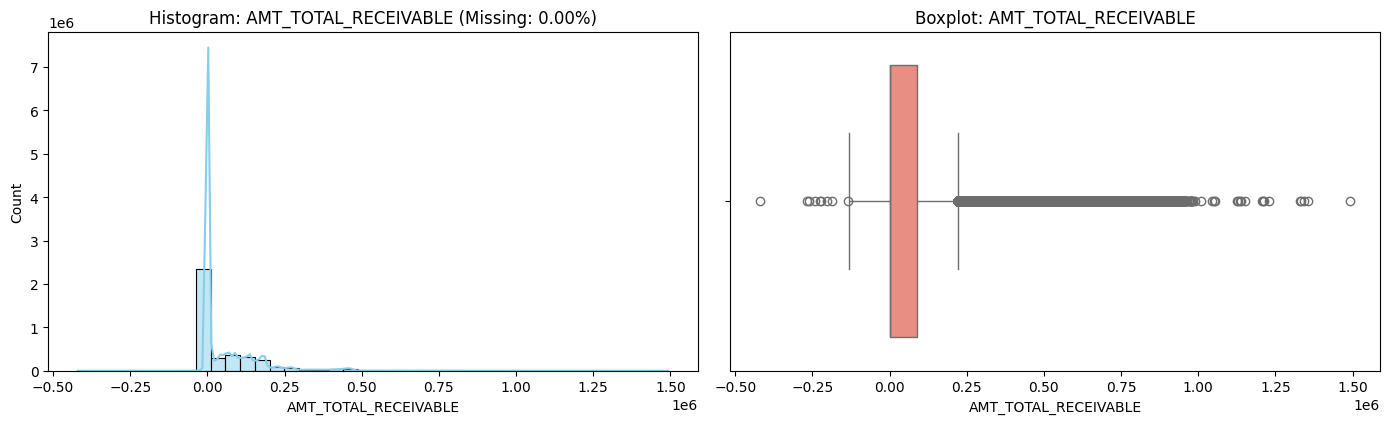

In [158]:
eda_numerical_feature(df_credit_card_balance, 'AMT_TOTAL_RECEIVABLE')


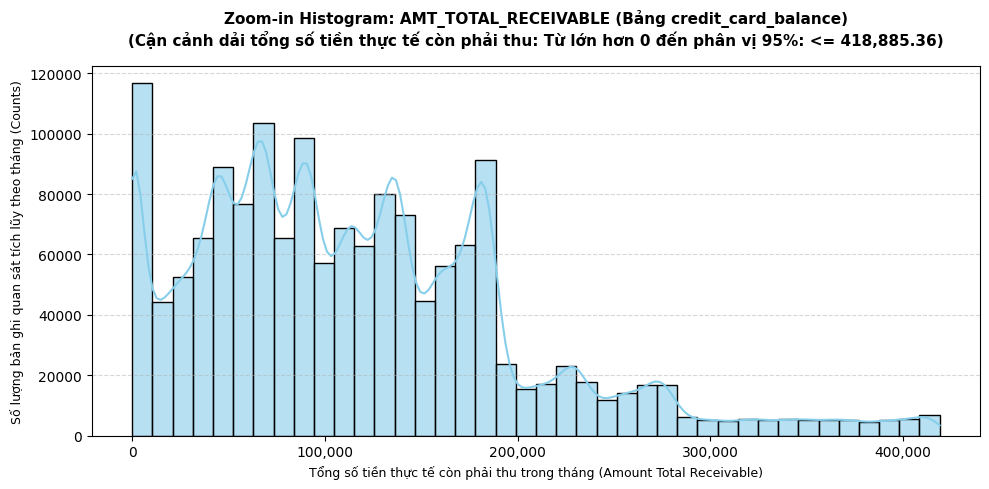

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TỔNG TIỀN THỰC TẾ PHẢI THU (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_TOTAL_RECEIVABLE'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh tổng thực tế còn phải thu (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản tĩnh hoặc đã tất toán
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin tiền tệ tĩnh
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải tổng số tiền thực tế còn phải thu: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Tổng số tiền thực tế còn phải thu trong tháng (Amount Total Receivable)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_DRAWINGS_ATM_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 749,816 dòng | Tỷ lệ khuyết: 19.52%
-----------------------------------------------------------------


,CNT_DRAWINGS_ATM_CURRENT
Count (Số lượng dòng thực tế),"3,090,496"
Mean (Trung bình),0.31
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),1.10
Min,0.00
Max,51.00
IQR (Tứ phân vị),0.00


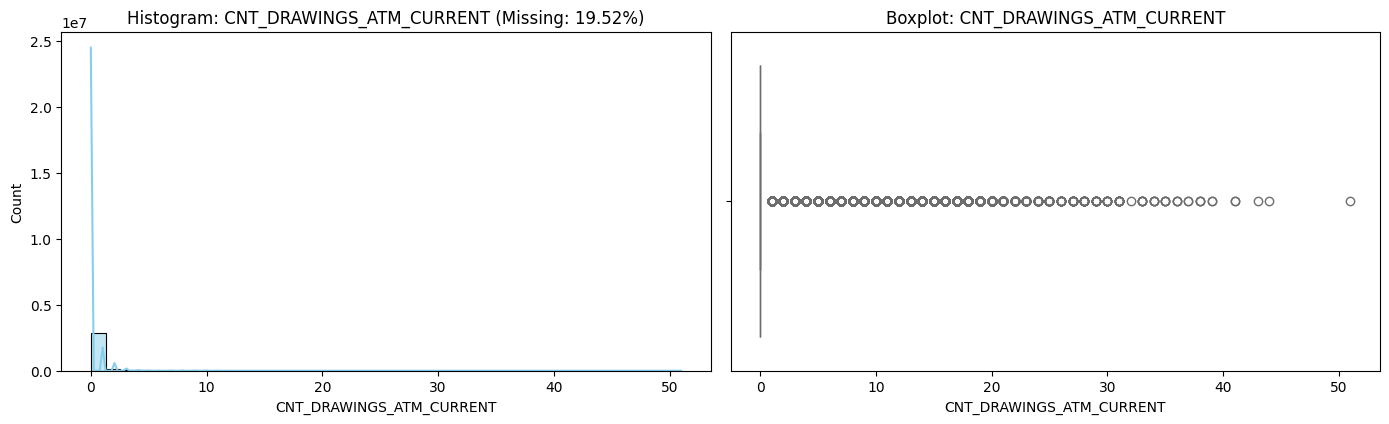

In [160]:
eda_numerical_feature(df_credit_card_balance, 'CNT_DRAWINGS_ATM_CURRENT')


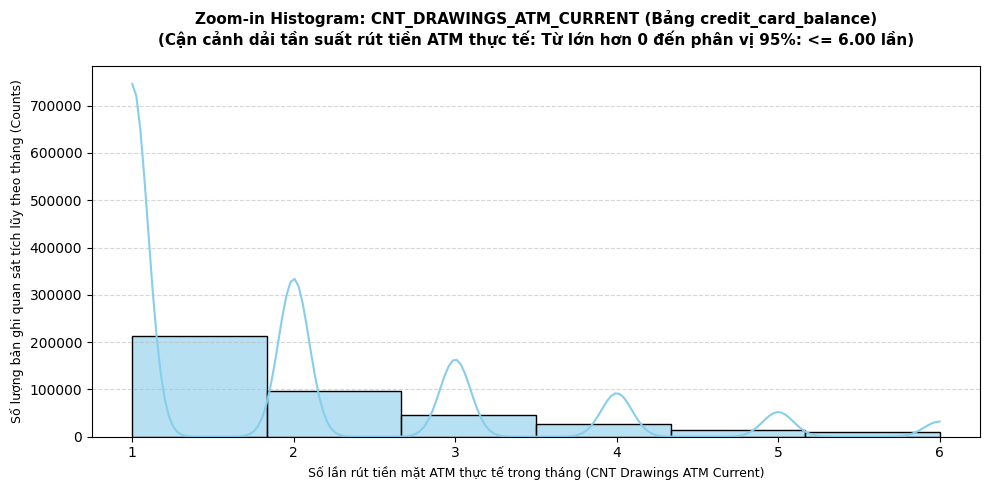

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ LẦN RÚT TIỀN ATM (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'CNT_DRAWINGS_ATM_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh lệnh rút tiền mặt ATM (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản không rút tiền mặt
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin rời rạc
sns.histplot(
    clean_data, 
    bins=int(upper_bound_95) if upper_bound_95 > 1 else 10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải tần suất rút tiền ATM thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f} lần)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số lần rút tiền mặt ATM thực tế trong tháng (CNT Drawings ATM Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị số nguyên rời rạc rõ nét
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_DRAWINGS_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,CNT_DRAWINGS_CURRENT
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),0.70
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),3.19
Min,0.00
Max,165.00
IQR (Tứ phân vị),0.00


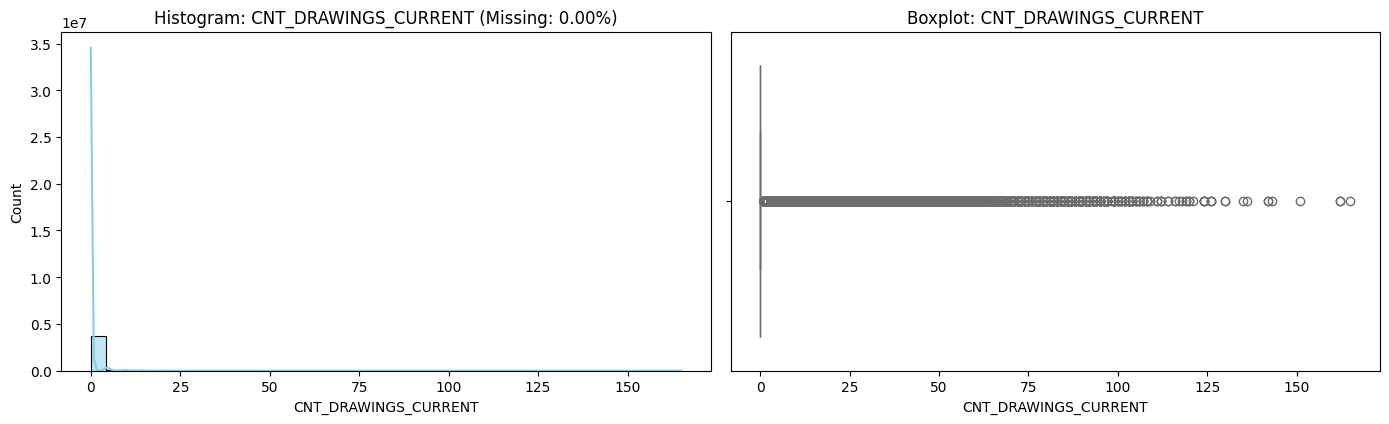

In [162]:
eda_numerical_feature(df_credit_card_balance, 'CNT_DRAWINGS_CURRENT')


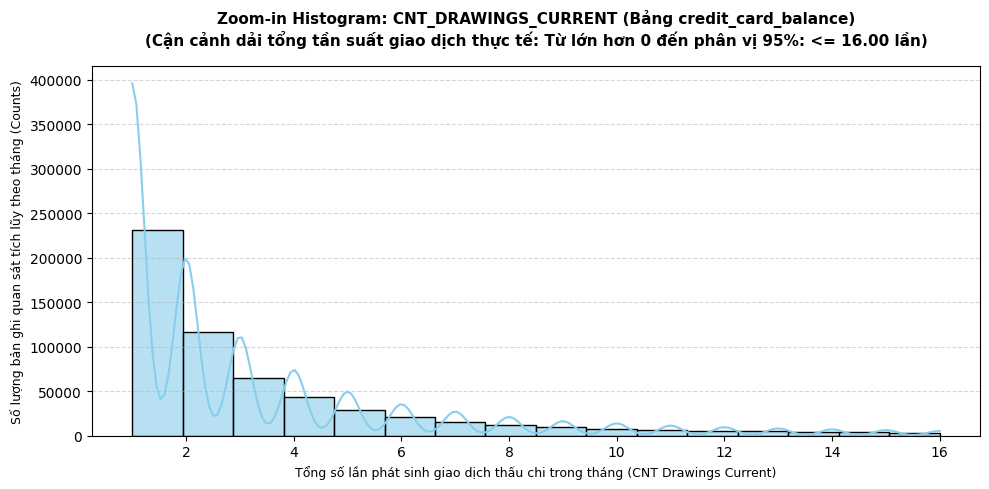

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TỔNG TẦN SUẤT GIAO DỊCH (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'CNT_DRAWINGS_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh lệnh giao dịch thấu chi (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản nằm đóng băng tĩnh
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin rời rạc
sns.histplot(
    clean_data, 
    bins=int(upper_bound_95) if upper_bound_95 > 1 else 10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải tổng tần suất giao dịch thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f} lần)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Tổng số lần phát sinh giao dịch thấu chi trong tháng (CNT Drawings Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị số nguyên rời rạc rõ nét
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_DRAWINGS_OTHER_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 749,816 dòng | Tỷ lệ khuyết: 19.52%
-----------------------------------------------------------------


,CNT_DRAWINGS_OTHER_CURRENT
Count (Số lượng dòng thực tế),"3,090,496"
Mean (Trung bình),0.00
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.08
Min,0.00
Max,12.00
IQR (Tứ phân vị),0.00


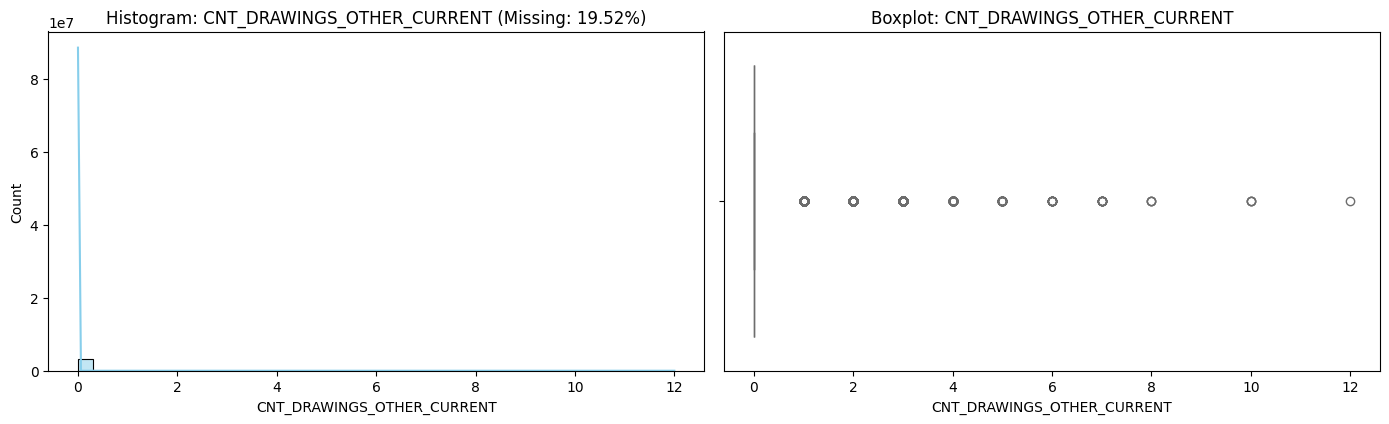

In [164]:
eda_numerical_feature(df_credit_card_balance, 'CNT_DRAWINGS_OTHER_CURRENT')


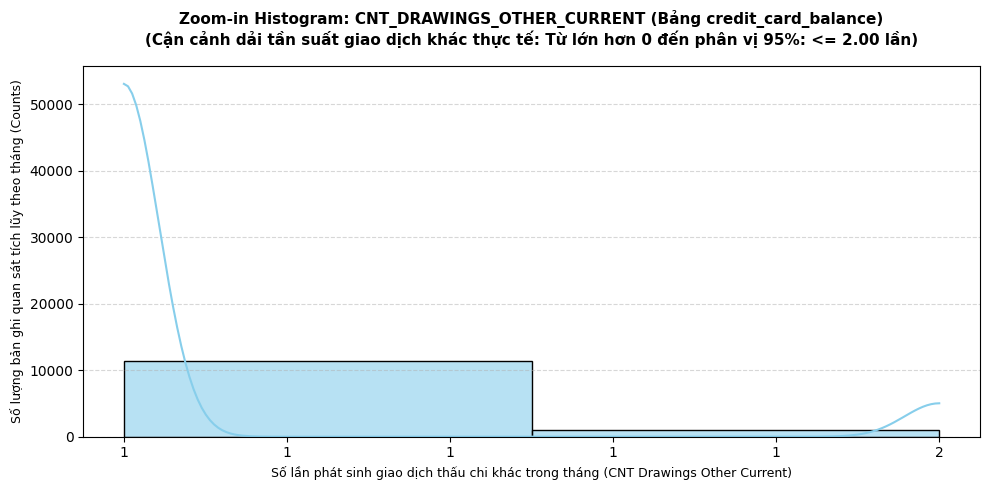

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TẦN SUẤT GIAO DỊCH KHÁC (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'CNT_DRAWINGS_OTHER_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC T TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh lệnh giao dịch thấu chi khác (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản nằm đóng băng tĩnh
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin rời rạc
sns.histplot(
    clean_data, 
    bins=int(upper_bound_95) if upper_bound_95 > 1 else 10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải tần suất giao dịch khác thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f} lần)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số lần phát sinh giao dịch thấu chi khác trong tháng (CNT Drawings Other Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị số nguyên rời rạc rõ nét
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_DRAWINGS_POS_CURRENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 749,816 dòng | Tỷ lệ khuyết: 19.52%
-----------------------------------------------------------------


,CNT_DRAWINGS_POS_CURRENT
Count (Số lượng dòng thực tế),"3,090,496"
Mean (Trung bình),0.56
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),3.24
Min,0.00
Max,165.00
IQR (Tứ phân vị),0.00


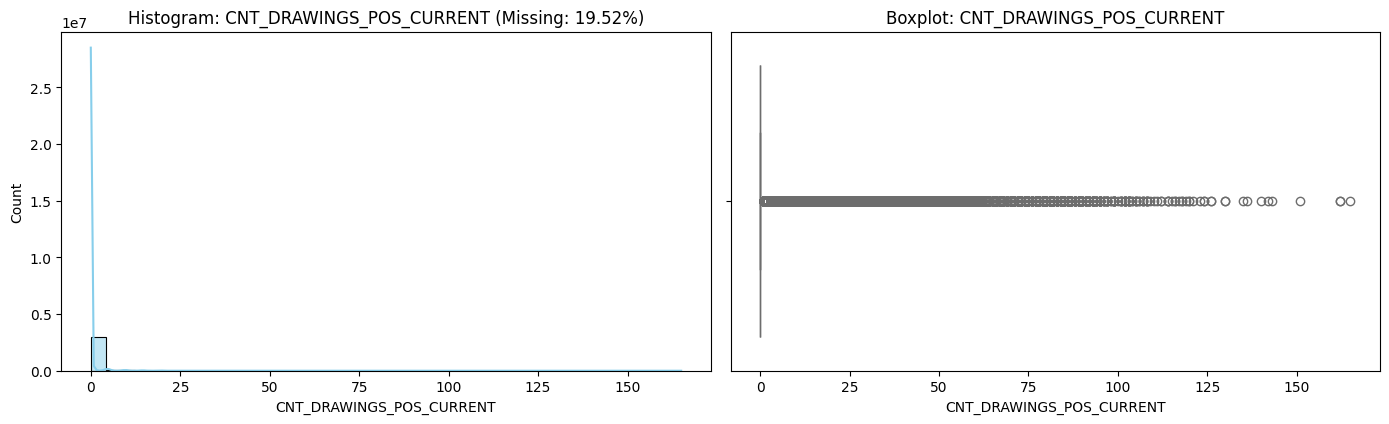

In [166]:
eda_numerical_feature(df_credit_card_balance, 'CNT_DRAWINGS_POS_CURRENT')


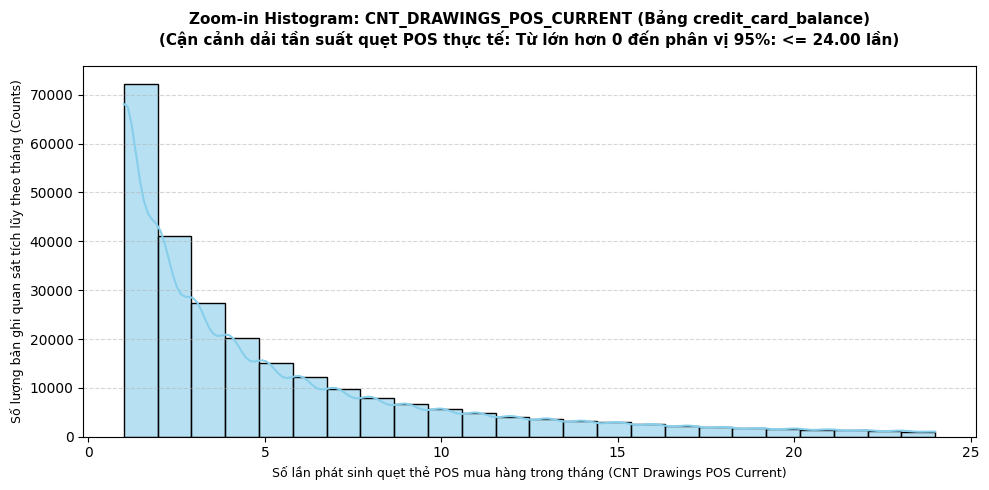

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TẦN SUẤT QUẸT THẺ POS (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'CNT_DRAWINGS_POS_CURRENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự phát sinh lệnh quẹt thẻ POS mua hàng (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản nằm đóng băng tĩnh
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin rời rạc
sns.histplot(
    clean_data, 
    bins=int(upper_bound_95) if upper_bound_95 > 1 else 10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải tần suất quẹt POS thực tế: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f} lần)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số lần phát sinh quẹt thẻ POS mua hàng trong tháng (CNT Drawings POS Current)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị số nguyên rời rạc rõ nét
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: CNT_INSTALMENT_MATURE_CUM
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 305,236 dòng | Tỷ lệ khuyết: 7.95%
-----------------------------------------------------------------


,CNT_INSTALMENT_MATURE_CUM
Count (Số lượng dòng thực tế),"3,535,076"
Mean (Trung bình),20.83
Median (Trung vị),15.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),20.05
Min,0.00
Max,120.00
IQR (Tứ phân vị),28.00


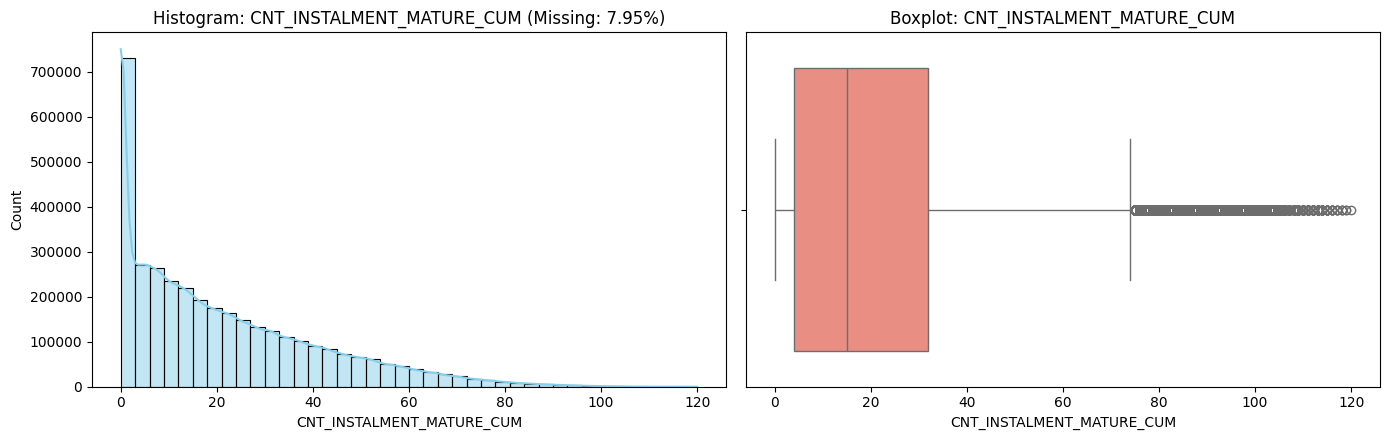

In [168]:
eda_numerical_feature(df_credit_card_balance, 'CNT_INSTALMENT_MATURE_CUM')


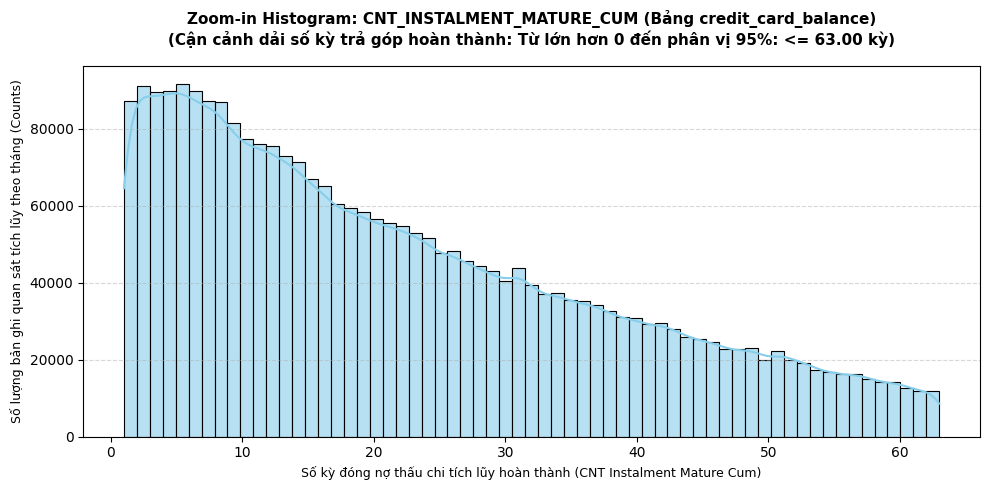

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ KỲ ĐÃ ĐÓNG TRẢ GÓP (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'CNT_INSTALMENT_MATURE_CUM'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự đã hoàn thành ít nhất 1 kỳ trả góp (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ thẻ mới hoặc chưa tính kỳ
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin rời rạc
sns.histplot(
    clean_data, 
    bins=int(upper_bound_95) if upper_bound_95 > 1 else 10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải số kỳ trả góp hoàn thành: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f} kỳ)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số kỳ đóng nợ thấu chi tích lũy hoàn thành (CNT Instalment Mature Cum)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị số nguyên rời rạc rõ nét
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📊 [CATEGORICAL] Feature: NAME_CONTRACT_STATUS | Unique Groups: 7
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
NAME_CONTRACT_STATUS,,
Active,"3,698,436",96.31
Completed,"128,918",3.36
Signed,"11,058",0.29
Demand,"1,365",0.04
Sent proposal,513,0.01
Refused,17,0.00
Approved,5,0.00


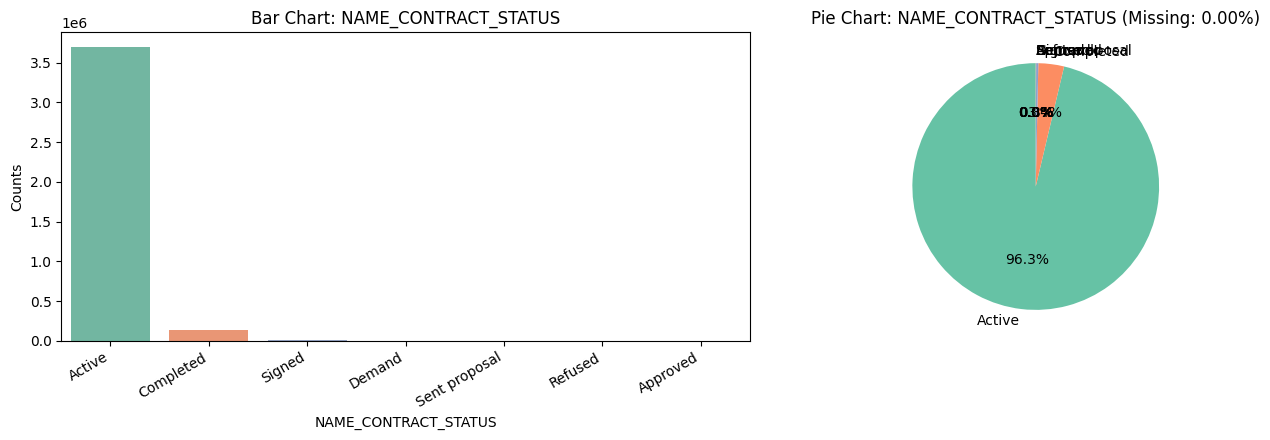

In [171]:
eda_categorical_feature(df_credit_card_balance, 'NAME_CONTRACT_STATUS')


📈 [NUMERICAL] Feature: SK_DPD
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,SK_DPD
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),9.28
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),97.52
Min,0.00
Max,"3,260.00"
IQR (Tứ phân vị),0.00


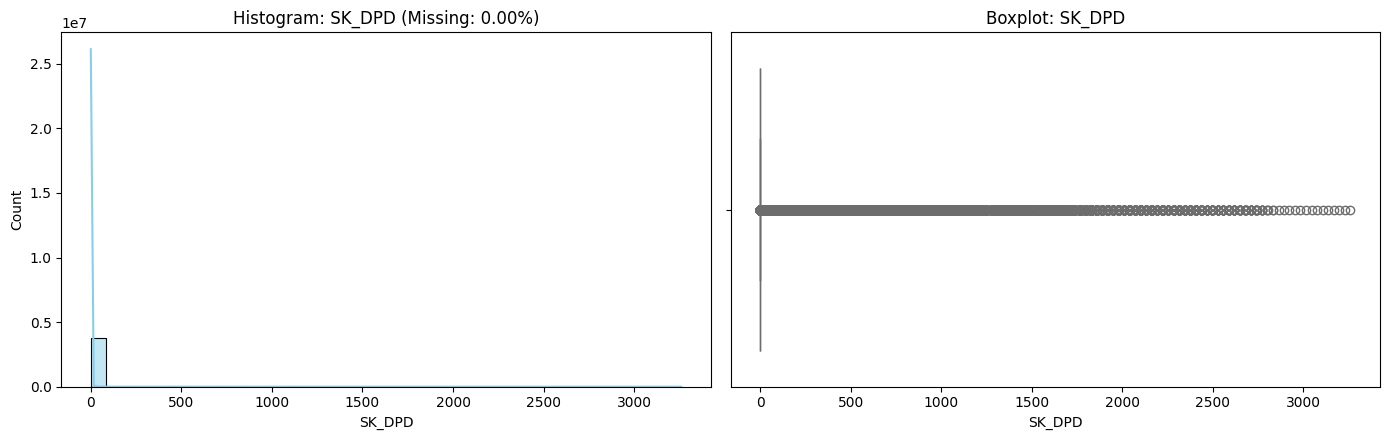

In [172]:
eda_numerical_feature(df_credit_card_balance, 'SK_DPD')


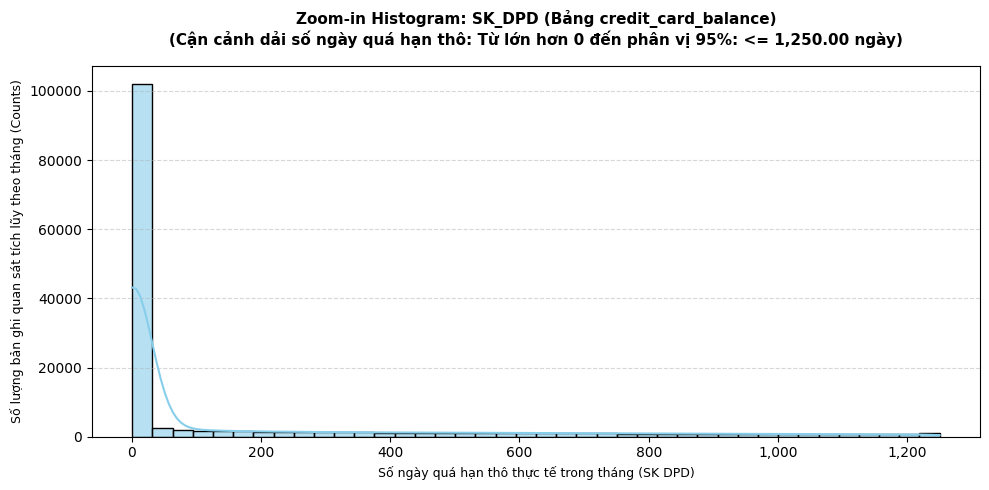

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ NGÀY QUÁ HẠN THÔ (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'SK_DPD'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_credit_card_balance[df_credit_card_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự dính vết quá hạn thô (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản tuân thủ hoàn hảo
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin quá hạn thô
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng credit_card_balance)\n(Cận cảnh dải số ngày quá hạn thô: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f} ngày)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số ngày quá hạn thô thực tế trong tháng (SK DPD)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: SK_DPD_DEF
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,SK_DPD_DEF
Count (Số lượng dòng thực tế),"3,840,312"
Mean (Trung bình),0.33
Median (Trung vị),0.00
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),21.48
Min,0.00
Max,"3,260.00"
IQR (Tứ phân vị),0.00


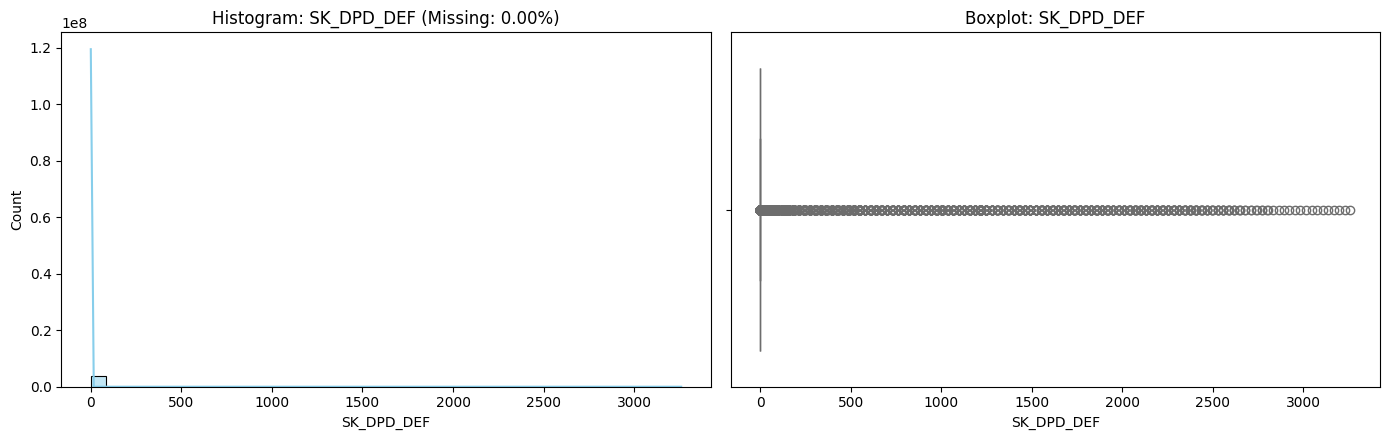

In [175]:
eda_numerical_feature(df_credit_card_balance, 'SK_DPD_DEF')


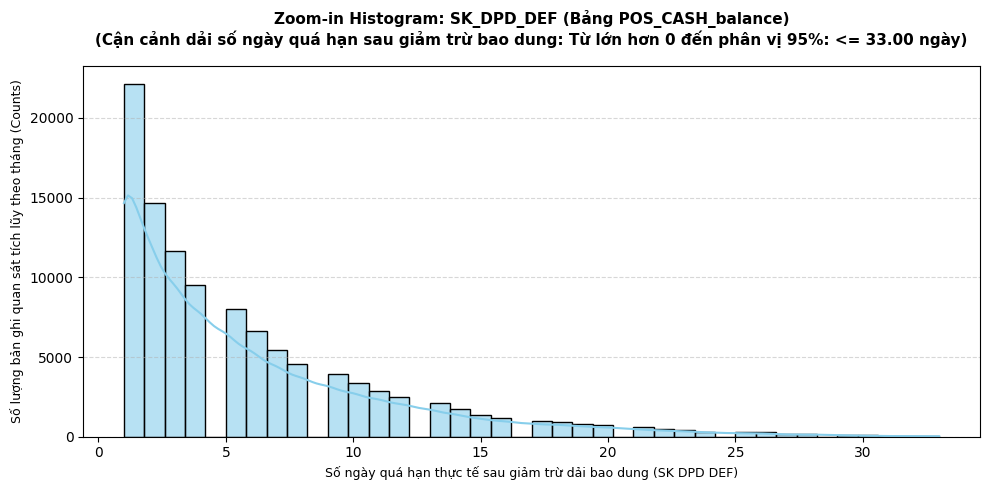

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ NGÀY QUÁ HẠN THỰC POS (> 0)
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí (Bảng POS)
target_col = 'SK_DPD_DEF'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_pos_cash_balance[df_pos_cash_balance[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự dính vết quá hạn thực tế (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ tài khoản tuân thủ hoàn hảo
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
# Sử dụng dải màu xanh lơ (skyblue) quy chuẩn cho nhóm thông tin quá hạn thực
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng POS_CASH_balance)\n(Cận cảnh dải số ngày quá hạn sau giảm trừ bao dung: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f} ngày)', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số ngày quá hạn thực tế sau giảm trừ dải bao dung (SK DPD DEF)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy theo tháng (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

In [177]:
df_installments_payments = pd.read_csv(INS_PAYMENT_FILE)


📈 [NUMERICAL] Feature: NUM_INSTALMENT_VERSION
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,NUM_INSTALMENT_VERSION
Count (Số lượng dòng thực tế),"13,605,401"
Mean (Trung bình),0.86
Median (Trung vị),1.00
Mode (Yếu vị),1.00
Std Dev (Độ lệch chuẩn),1.04
Min,0.00
Max,178.00
IQR (Tứ phân vị),1.00


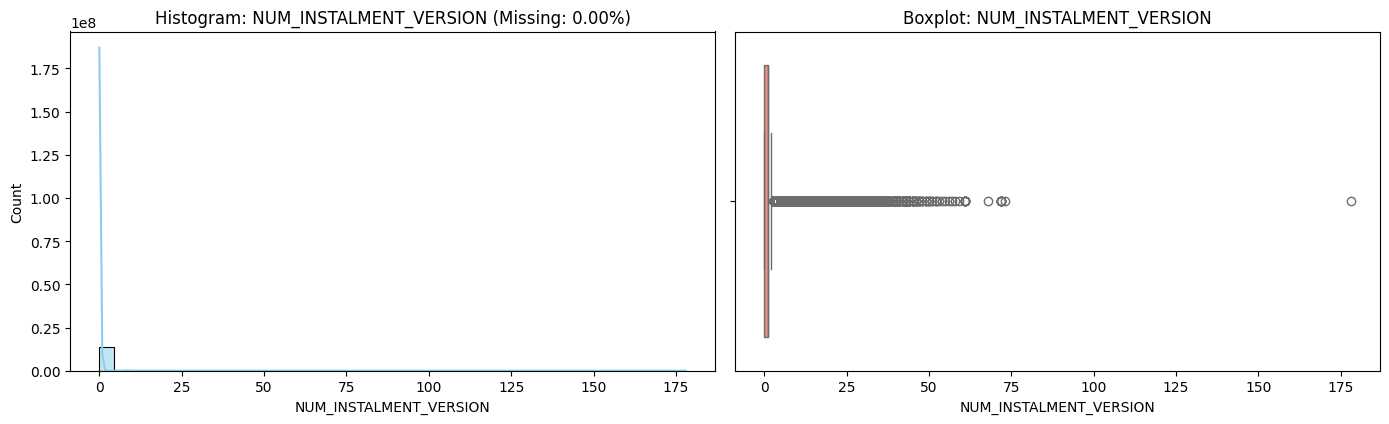

In [178]:
eda_numerical_feature(df_installments_payments, 'NUM_INSTALMENT_VERSION')


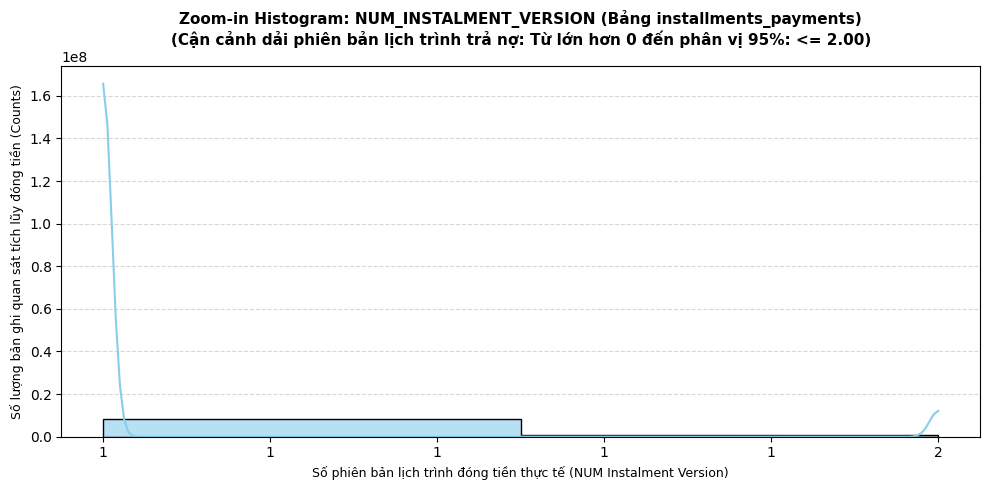

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN PHIÊN BẢN LỊCH TRẢ GÓP (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_installments_payments
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# ĐỊNH DANH CHÍNH XÁC: Tên cột phiên bản lịch trình đóng tiền thực tế trong bảng dòng tiền
target_col = 'NUM_INSTALMENT_VERSION'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_installments_payments[df_installments_payments[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập nhóm thực sự có phiên bản biến động lịch trình (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của mốc 0 (thường là thẻ tín dụng tuần hoàn)
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=int(upper_bound_95) if upper_bound_95 > 1 else 10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng installments_payments)\n(Cận cảnh dải phiên bản lịch trình trả nợ: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số phiên bản lịch trình đóng tiền thực tế (NUM Instalment Version)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát tích lũy đóng tiền (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị số nguyên rời rạc rõ nét
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: DAYS_INSTALMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,DAYS_INSTALMENT
Count (Số lượng dòng thực tế),"13,605,401"
Mean (Trung bình),"-1,042.27"
Median (Trung vị),-818.00
Mode (Yếu vị),-120.00
Std Dev (Độ lệch chuẩn),800.95
Min,"-2,922.00"
Max,-1.00
IQR (Tứ phân vị),"1,293.00"


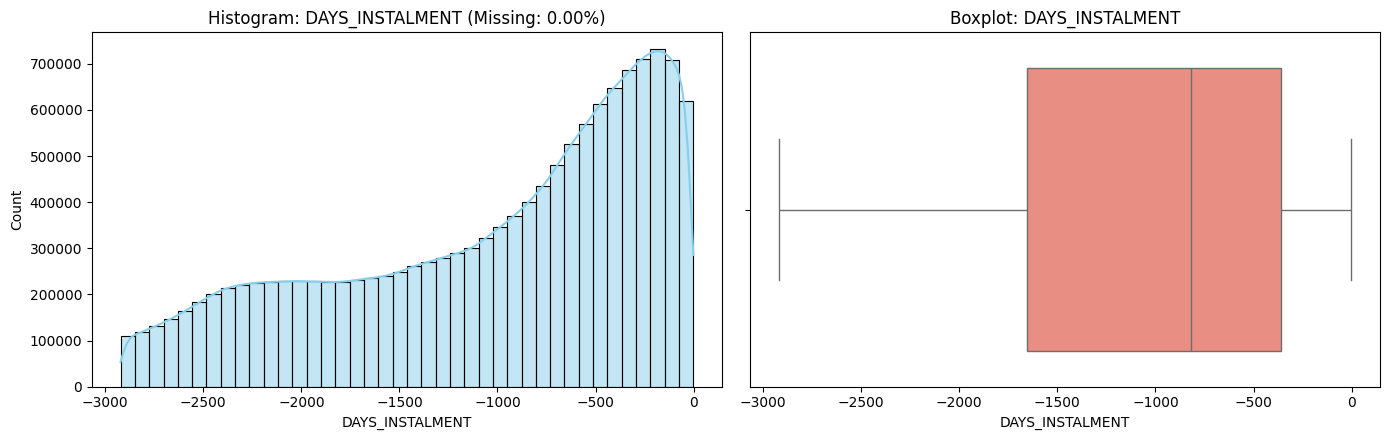

In [182]:
eda_numerical_feature(df_installments_payments, 'DAYS_INSTALMENT')


📈 [NUMERICAL] Feature: DAYS_ENTRY_PAYMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 2,905 dòng | Tỷ lệ khuyết: 0.02%
-----------------------------------------------------------------


,DAYS_ENTRY_PAYMENT
Count (Số lượng dòng thực tế),"13,602,496"
Mean (Trung bình),"-1,051.11"
Median (Trung vị),-827.00
Mode (Yếu vị),-91.00
Std Dev (Độ lệch chuẩn),800.59
Min,"-4,921.00"
Max,-1.00
IQR (Tứ phân vị),"1,292.00"


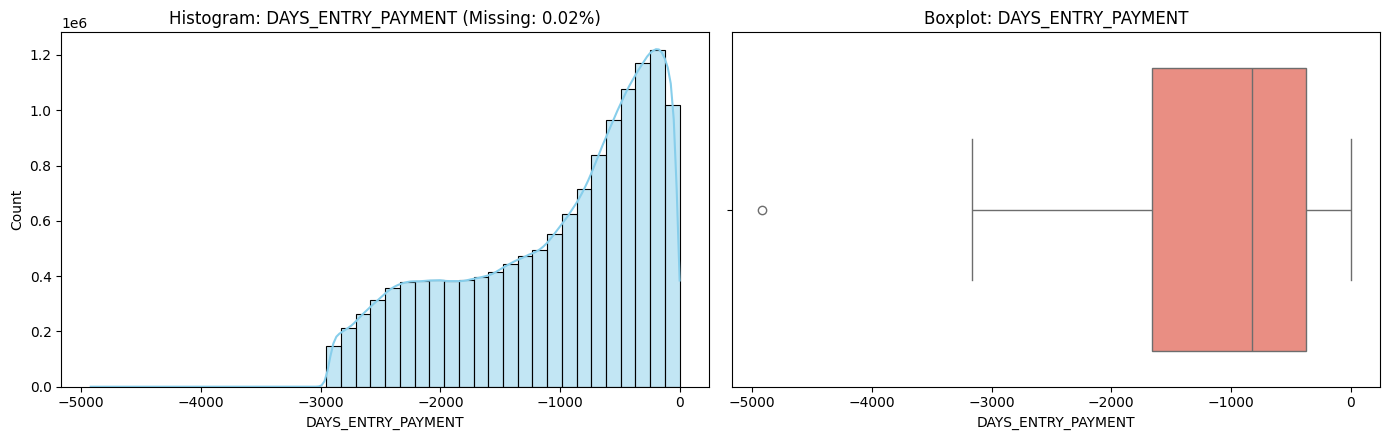

In [183]:
eda_numerical_feature(df_installments_payments, 'DAYS_ENTRY_PAYMENT')


📈 [NUMERICAL] Feature: AMT_INSTALMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_INSTALMENT
Count (Số lượng dòng thực tế),"13,605,401"
Mean (Trung bình),"17,050.91"
Median (Trung vị),"8,884.08"
Mode (Yếu vị),"9,000.00"
Std Dev (Độ lệch chuẩn),"50,570.25"
Min,0.00
Max,"3,771,487.85"
IQR (Tứ phân vị),"12,484.12"


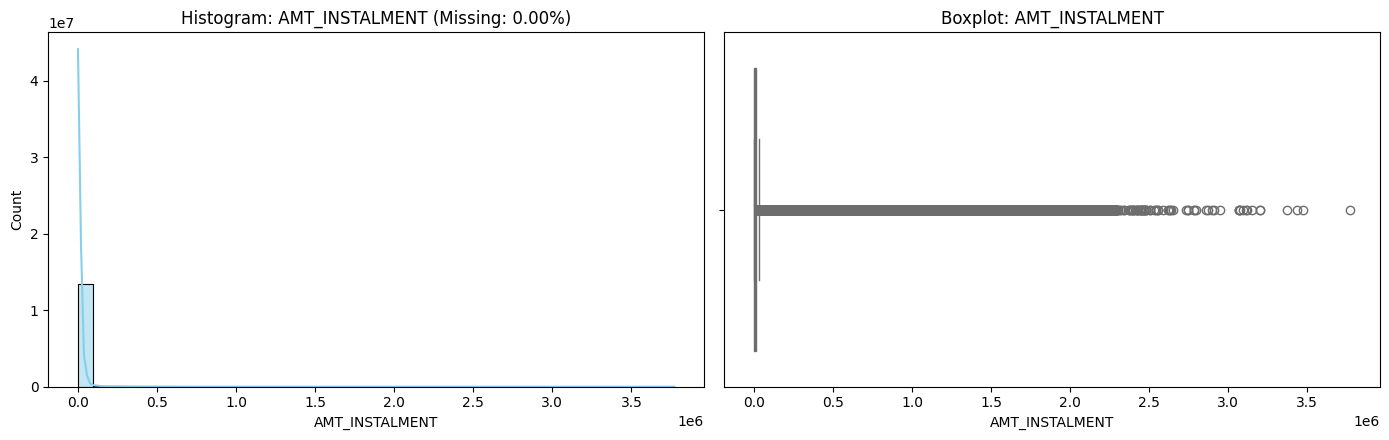

In [184]:
eda_numerical_feature(df_installments_payments, 'AMT_INSTALMENT')


<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

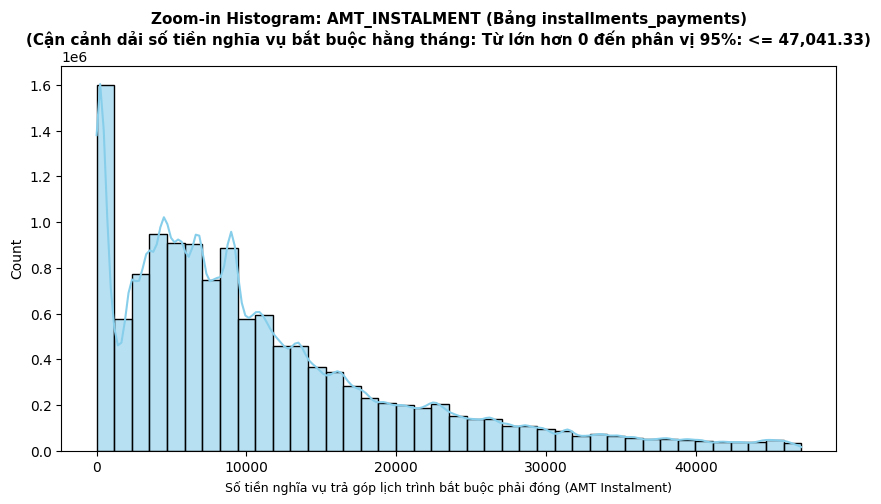

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ TIỀN NGHĨA VỤ TRẢ GÓP (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_installments_payments
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_INSTALMENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_installments_payments[df_installments_payments[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự gánh số tiền nghĩa vụ (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ sao kê đóng băng
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng installments_payments)\n(Cận cảnh dải số tiền nghĩa vụ bắt buộc hằng tháng: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền nghĩa vụ trả góp lịch trình bắt buộc phải đóng (AMT Instalment)', fontsize=9)
plt.ylabel

📈 [NUMERICAL] Feature: AMT_PAYMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 2,905 dòng | Tỷ lệ khuyết: 0.02%
-----------------------------------------------------------------


,AMT_PAYMENT
Count (Số lượng dòng thực tế),"13,602,496"
Mean (Trung bình),"17,238.22"
Median (Trung vị),"8,125.52"
Mode (Yếu vị),"9,000.00"
Std Dev (Độ lệch chuẩn),"54,735.78"
Min,0.00
Max,"3,771,487.85"
IQR (Tứ phân vị),"12,710.16"


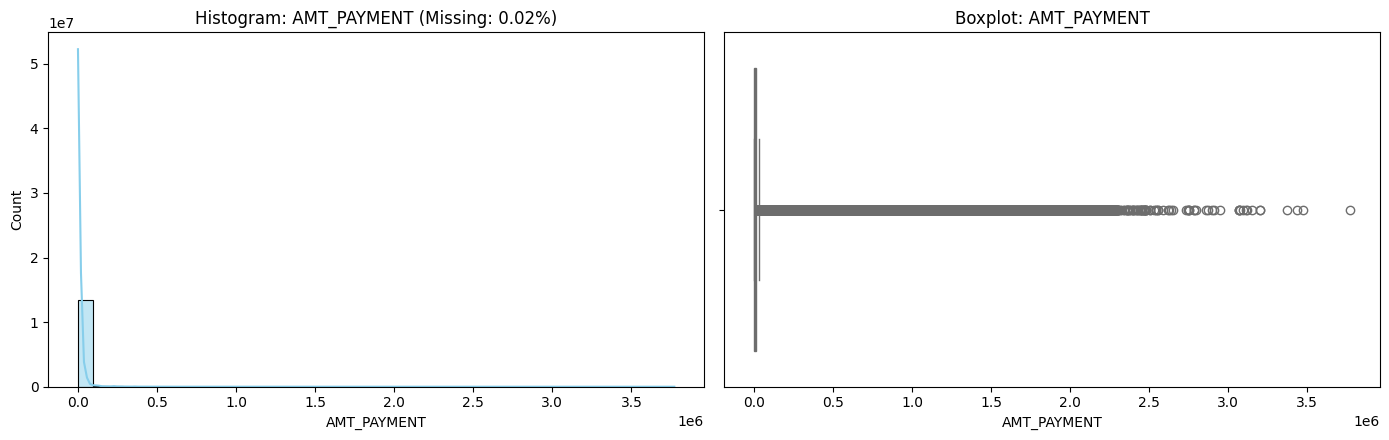

In [186]:
eda_numerical_feature(df_installments_payments, 'AMT_PAYMENT')


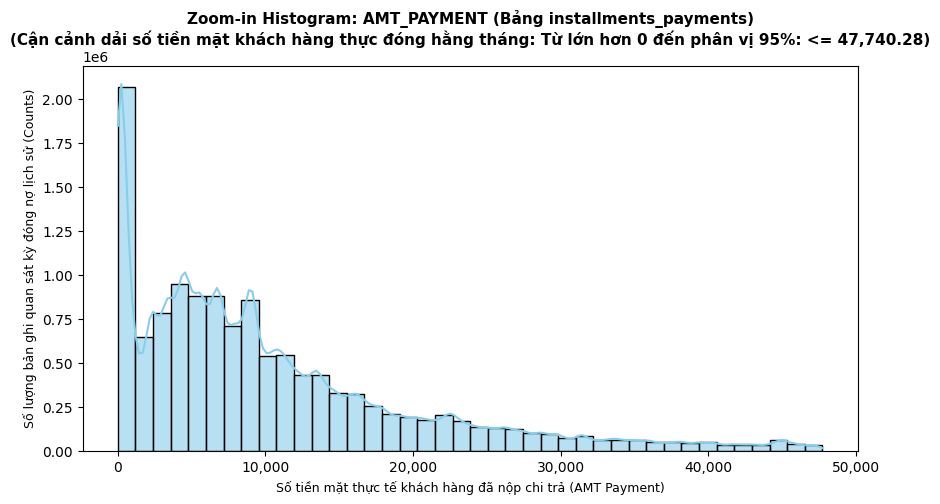

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ TIỀN THỰC ĐẾN ĐÓNG (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_installments_payments
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_PAYMENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_installments_payments[df_installments_payments[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh số tiền nộp (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các kỳ trốn nợ
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng installments_payments)\n(Cận cảnh dải số tiền mặt khách hàng thực đóng hằng tháng: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền mặt thực tế khách hàng đã nộp chi trả (AMT Payment)', fontsize=9)
plt.ylabel('Số lượng bản ghi quan sát kỳ đóng nợ lịch sử (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan dòng tiền
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối

In [188]:
df_previous_application = pd.read_csv(PREV_APP_FILE)


📈 [NUMERICAL] Feature: AMT_ANNUITY
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 372,235 dòng | Tỷ lệ khuyết: 22.29%
-----------------------------------------------------------------


,AMT_ANNUITY
Count (Số lượng dòng thực tế),"1,297,979"
Mean (Trung bình),"15,955.12"
Median (Trung vị),"11,250.00"
Mode (Yếu vị),"2,250.00"
Std Dev (Độ lệch chuẩn),"14,782.14"
Min,0.00
Max,"418,058.15"
IQR (Tứ phân vị),"14,336.64"


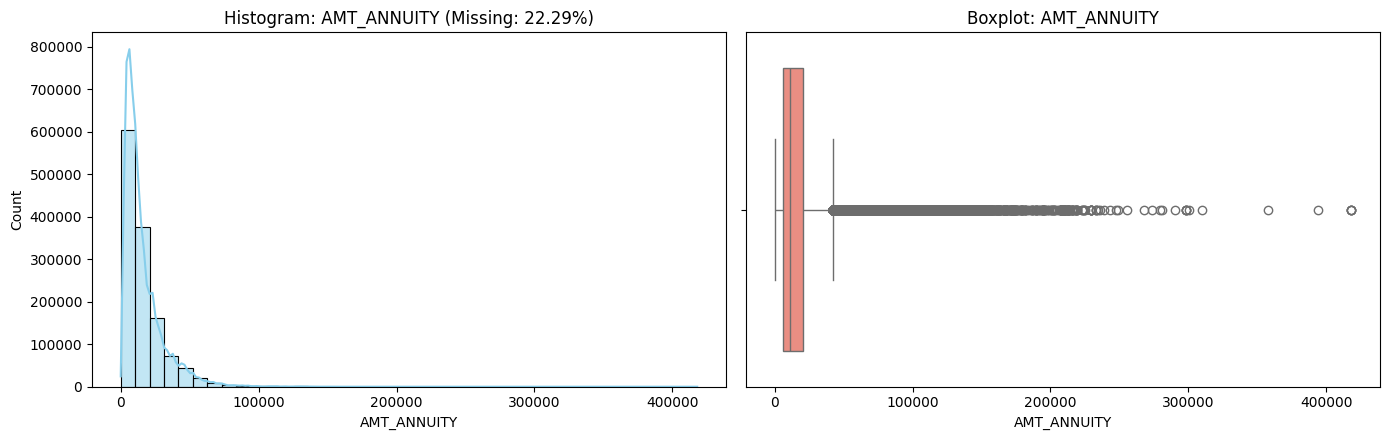

In [190]:
eda_numerical_feature(df_previous_application, 'AMT_ANNUITY')


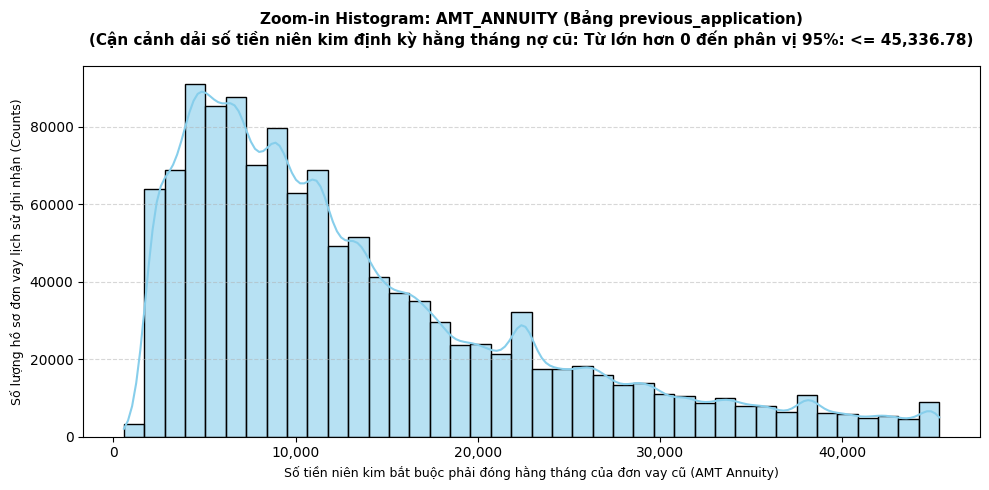

In [191]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN NIÊN KIM ĐƠN VAY CŨ (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_ANNUITY'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh tiền niên kim định kỳ (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các đơn vay bị hủy bỏ từ vòng gửi xe
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số tiền niên kim định kỳ hằng tháng nợ cũ: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền niên kim bắt buộc phải đóng hằng tháng của đơn vay cũ (AMT Annuity)', fontsize=9)
plt.ylabel('Số lượng hồ sơ đơn vay lịch sử ghi nhận (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan dòng tiền
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_APPLICATION
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_APPLICATION
Count (Số lượng dòng thực tế),"1,670,214"
Mean (Trung bình),"175,233.86"
Median (Trung vị),"71,046.00"
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"292,779.76"
Min,0.00
Max,"6,905,160.00"
IQR (Tứ phân vị),"161,640.00"


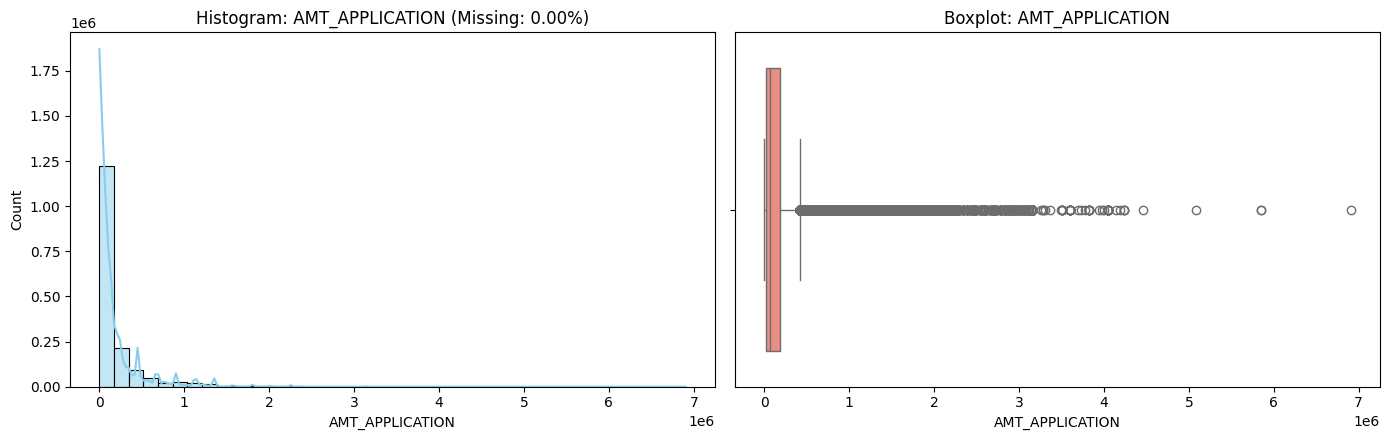

In [192]:
eda_numerical_feature(df_previous_application, 'AMT_APPLICATION')


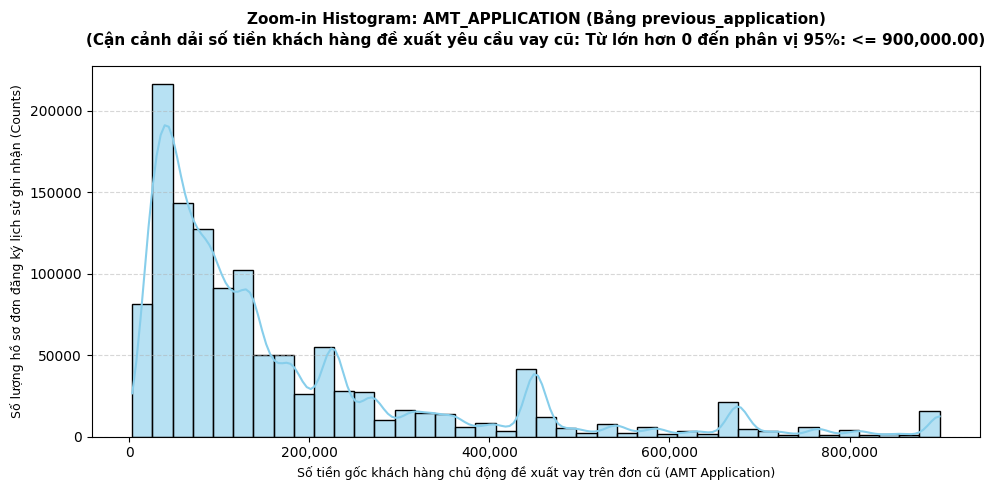

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN SỐ TIỀN ĐỀ XUẤT VAY CŨ (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_APPLICATION'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh số tiền đề xuất vay (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các đơn khởi tạo thẻ nền tĩnh
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số tiền khách hàng đề xuất yêu cầu vay cũ: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền gốc khách hàng chủ động đề xuất vay trên đơn cũ (AMT Application)', fontsize=9)
plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan dòng tiền
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_CREDIT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,AMT_CREDIT
Count (Số lượng dòng thực tế),"1,670,213"
Mean (Trung bình),"196,114.02"
Median (Trung vị),"80,541.00"
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"318,574.62"
Min,0.00
Max,"6,905,160.00"
IQR (Tứ phân vị),"192,258.00"


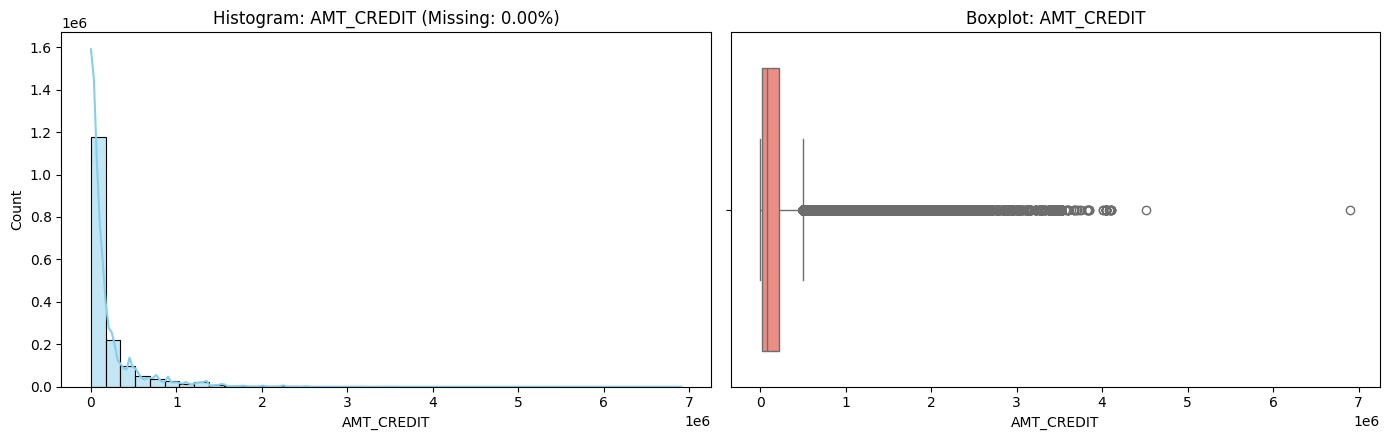

In [194]:
eda_numerical_feature(df_previous_application, 'AMT_CREDIT')


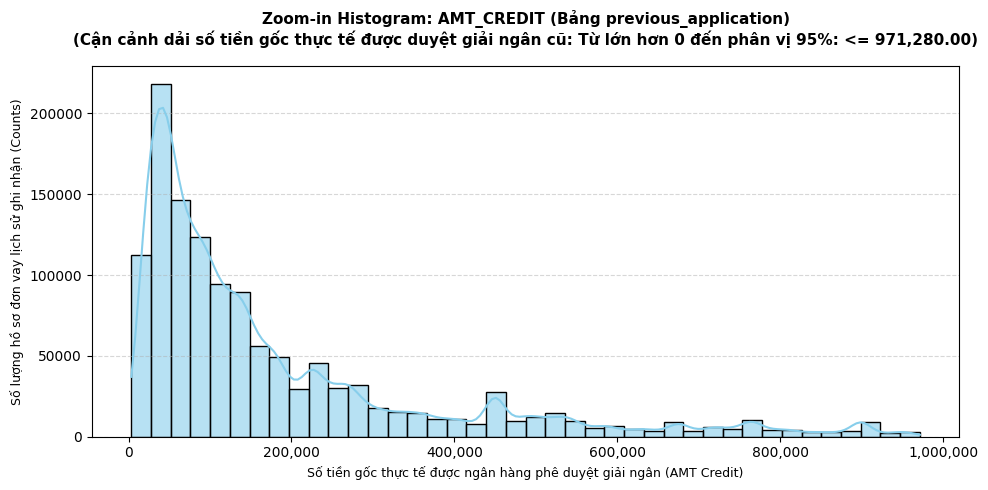

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TIỀN DUYỆT GIẢI NGÂN CŨ (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_CREDIT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự được phê duyệt giải ngân dòng vốn (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các đơn vay dính vết bị từ chối
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số tiền gốc thực tế được duyệt giải ngân cũ: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền gốc thực tế được ngân hàng phê duyệt giải ngân (AMT Credit)', fontsize=9)
plt.ylabel('Số lượng hồ sơ đơn vay lịch sử ghi nhận (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan dòng tiền
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_DOWN_PAYMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 895,844 dòng | Tỷ lệ khuyết: 53.64%
-----------------------------------------------------------------


,AMT_DOWN_PAYMENT
Count (Số lượng dòng thực tế),"774,370"
Mean (Trung bình),"6,697.40"
Median (Trung vị),"1,638.00"
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),"20,921.50"
Min,-0.90
Max,"3,060,045.00"
IQR (Tứ phân vị),"7,740.00"


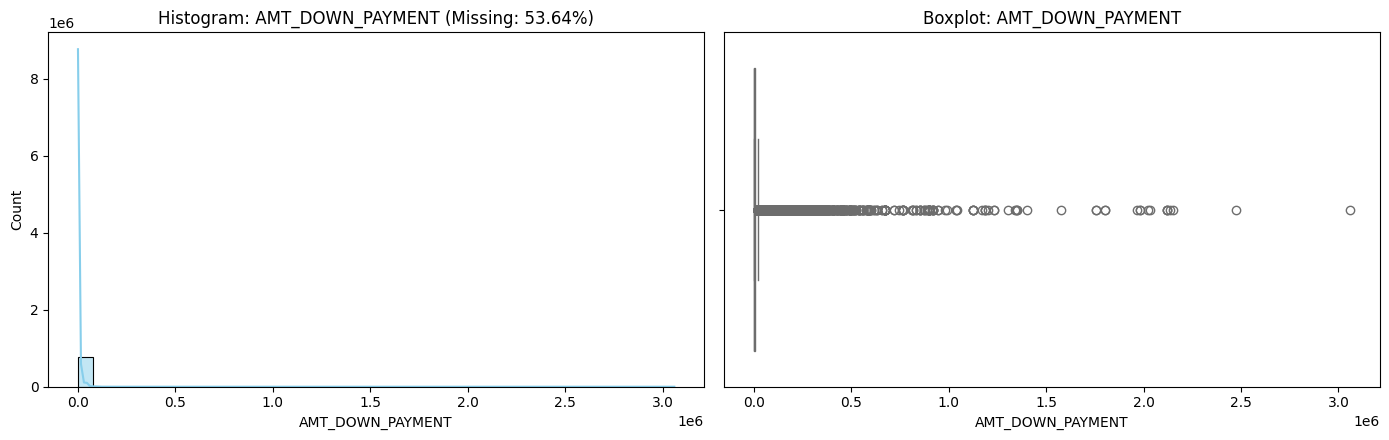

In [196]:
eda_numerical_feature(df_previous_application, 'AMT_DOWN_PAYMENT')


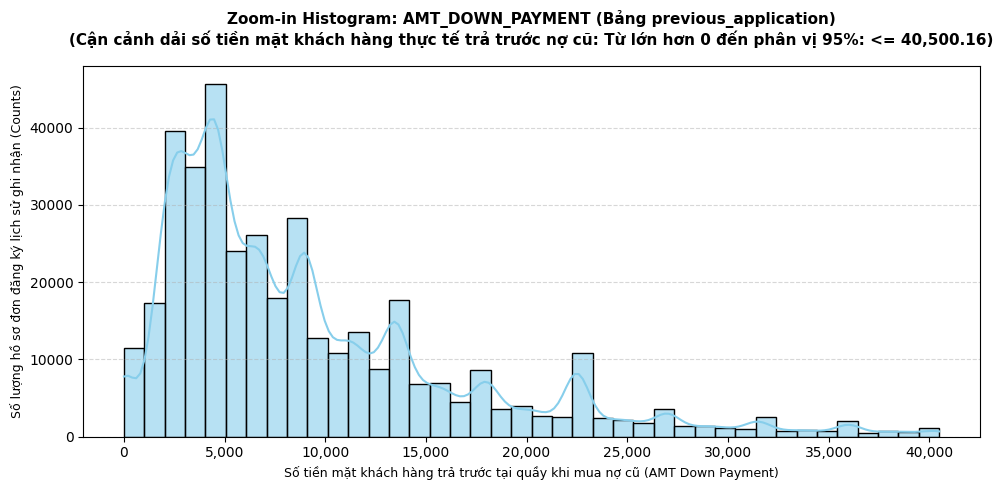

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TIỀN TRẢ TRƯỚC CŨ (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_DOWN_PAYMENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh tiền mặt trả trước (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các gói vay ưu đãi trả trước 0%
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số tiền mặt khách hàng thực tế trả trước nợ cũ: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Số tiền mặt khách hàng trả trước tại quầy khi mua nợ cũ (AMT Down Payment)', fontsize=9)
plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan dòng tiền
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: AMT_GOODS_PRICE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 385,515 dòng | Tỷ lệ khuyết: 23.08%
-----------------------------------------------------------------


,AMT_GOODS_PRICE
Count (Số lượng dòng thực tế),"1,284,699"
Mean (Trung bình),"227,847.28"
Median (Trung vị),"112,320.00"
Mode (Yếu vị),"45,000.00"
Std Dev (Độ lệch chuẩn),"315,396.56"
Min,0.00
Max,"6,905,160.00"
IQR (Tứ phân vị),"183,159.00"


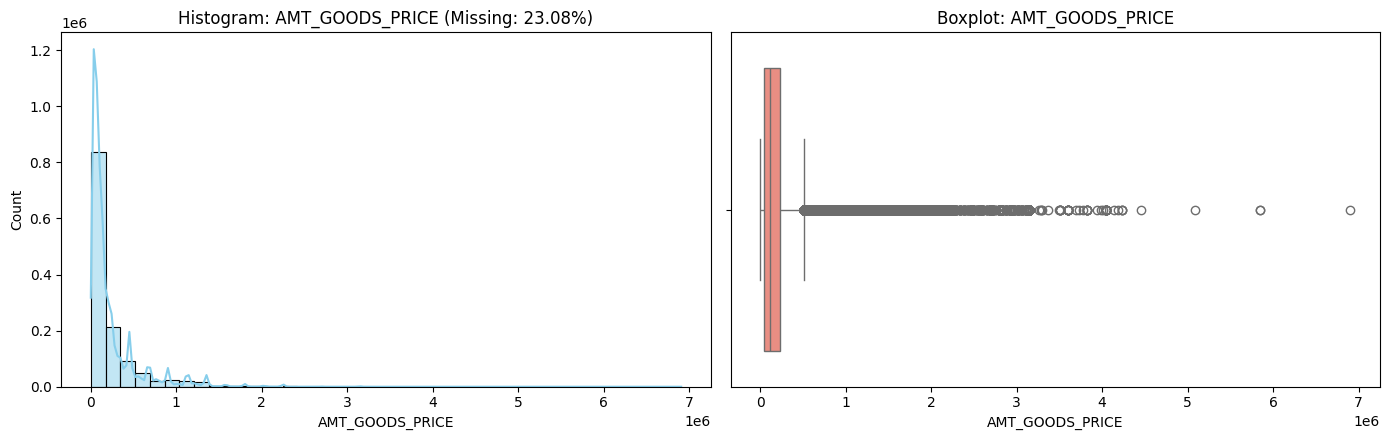

In [198]:
eda_numerical_feature(df_previous_application, 'AMT_GOODS_PRICE')


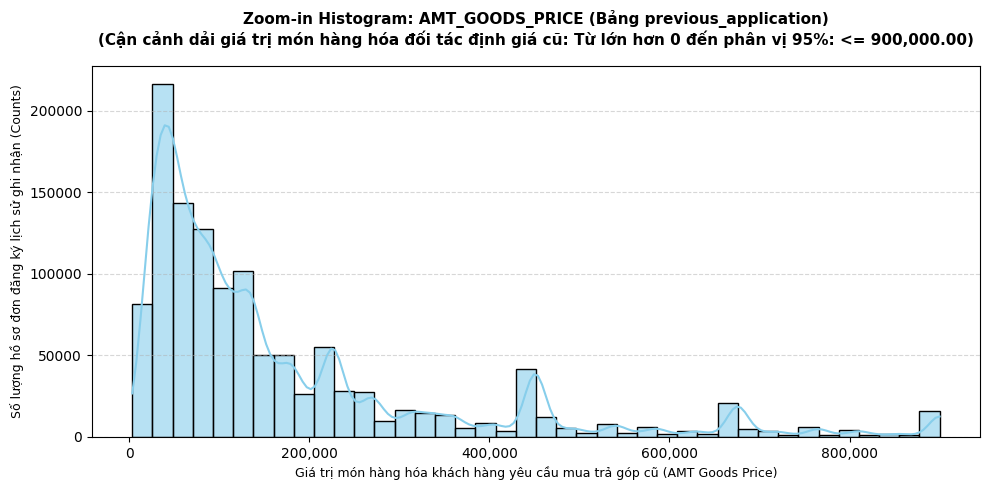

In [199]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN GIÁ TRỊ HÀNG HÓA CŨ (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'AMT_GOODS_PRICE'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh giá trị định giá hàng hóa (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các đơn vay tiền mặt thuần túy
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải giá trị món hàng hóa đối tác định giá cũ: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.2f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Giá trị món hàng hóa khách hàng yêu cầu mua trả góp cũ (AMT Goods Price)', fontsize=9)
plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị dấu phẩy ngăn cách hàng nghìn cho trực quan dòng tiền
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: RATE_DOWN_PAYMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 895,844 dòng | Tỷ lệ khuyết: 53.64%
-----------------------------------------------------------------


,RATE_DOWN_PAYMENT
Count (Số lượng dòng thực tế),"774,370"
Mean (Trung bình),0.08
Median (Trung vị),0.05
Mode (Yếu vị),0.00
Std Dev (Độ lệch chuẩn),0.11
Min,-0.00
Max,1.00
IQR (Tứ phân vị),0.11


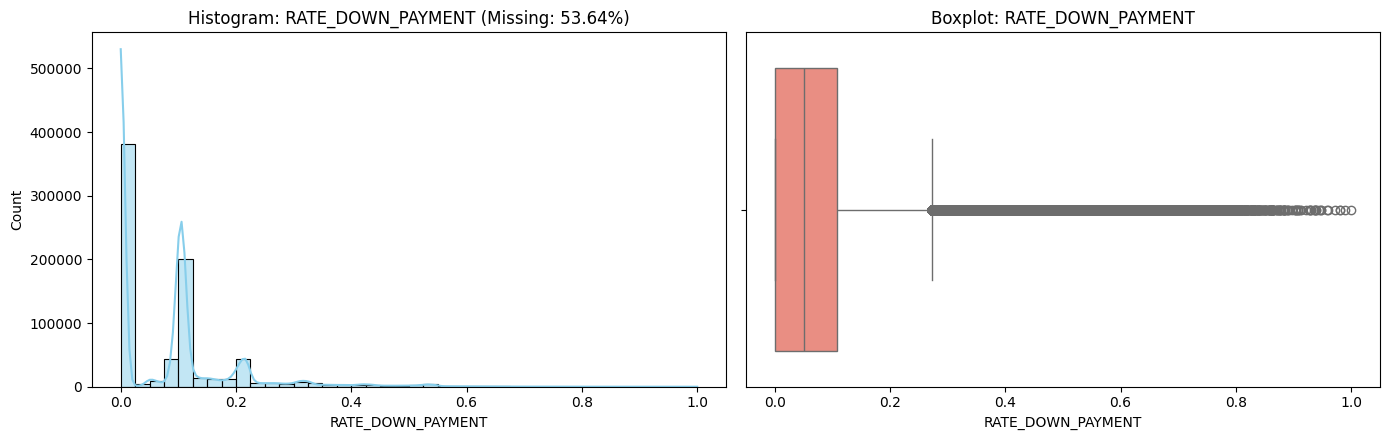

In [200]:
eda_numerical_feature(df_previous_application, 'RATE_DOWN_PAYMENT')


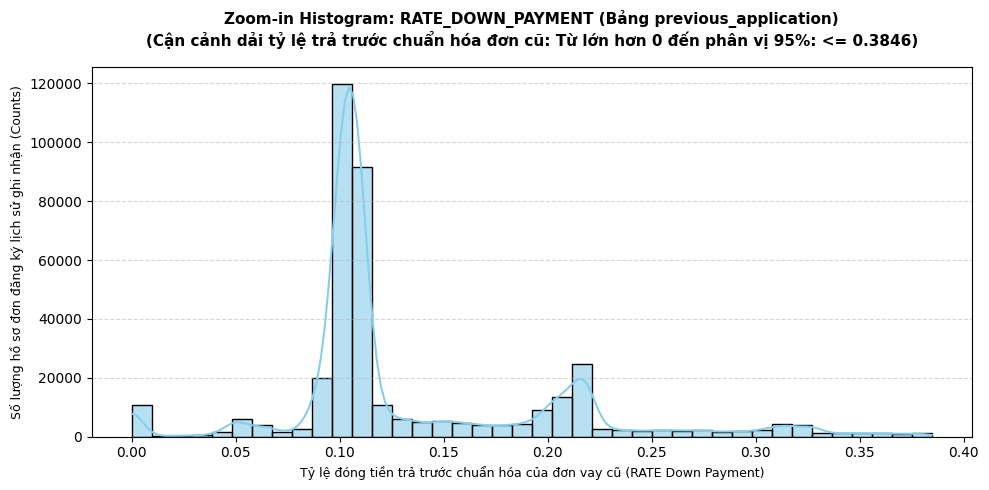

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN TỶ LỆ TRẢ TRƯỚC CŨ (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'RATE_DOWN_PAYMENT'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh tỷ lệ trả trước (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi sự bão hòa của các gói vay ưu đãi trả trước 0%
df_active_draw = df_non_na[df_non_na[target_col] > 0]

# Bước 3: Tính toán phân vị 95% TRÊN NHÓM HOẠT ĐỘNG để tìm ngưỡng trần dải phổ thông
upper_bound_95 = df_active_draw[target_col].quantile(0.95)

# Bước 4: Cô lập dải dữ liệu phổ thông thực tế (lớn hơn 0 và <= Phân vị 95%)
clean_data = df_active_draw[df_active_draw[target_col] <= upper_bound_95][target_col]

# Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
sns.histplot(
    clean_data, 
    bins=40, 
    kde=True, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.6
)

# =========================================================================
# CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
# =========================================================================
plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải tỷ lệ trả trước chuẩn hóa đơn cũ: Từ lớn hơn 0 đến phân vị 95%: <= {upper_bound_95:,.4f})', 
          fontsize=11, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ đóng tiền trả trước chuẩn hóa của đơn vay cũ (RATE Down Payment)', fontsize=9)
plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

# Định dạng nhãn trục hoành hiển thị số thực thập phân rõ nét cho tỷ lệ
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.2f}'))

# Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: RATE_INTEREST_PRIMARY
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,664,263 dòng | Tỷ lệ khuyết: 99.64%
-----------------------------------------------------------------


,RATE_INTEREST_PRIMARY
Count (Số lượng dòng thực tế),"5,951"
Mean (Trung bình),0.19
Median (Trung vị),0.19
Mode (Yếu vị),0.19
Std Dev (Độ lệch chuẩn),0.09
Min,0.03
Max,1.00
IQR (Tứ phân vị),0.03


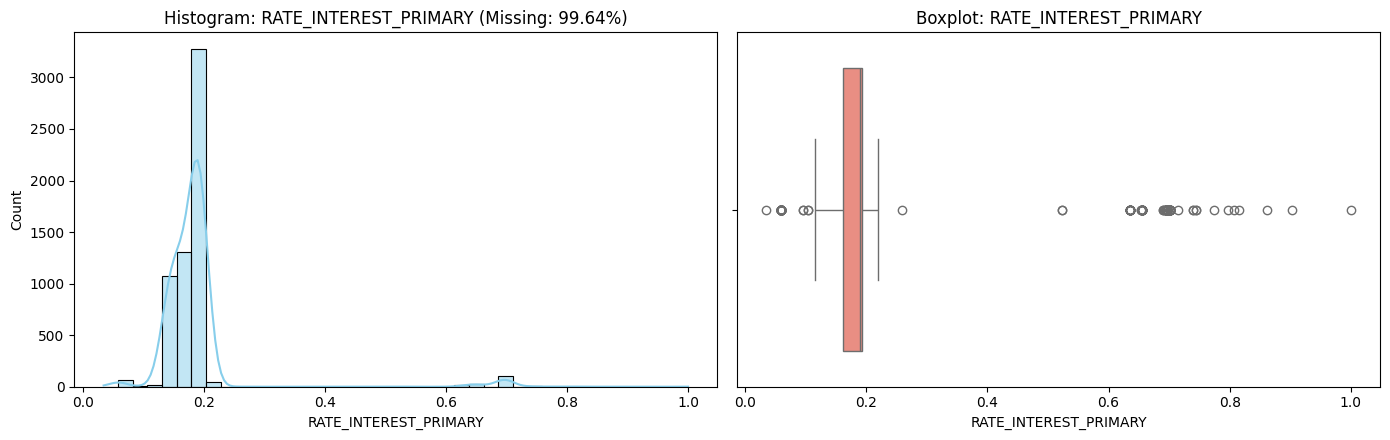

In [202]:
eda_numerical_feature(df_previous_application, 'RATE_INTEREST_PRIMARY')


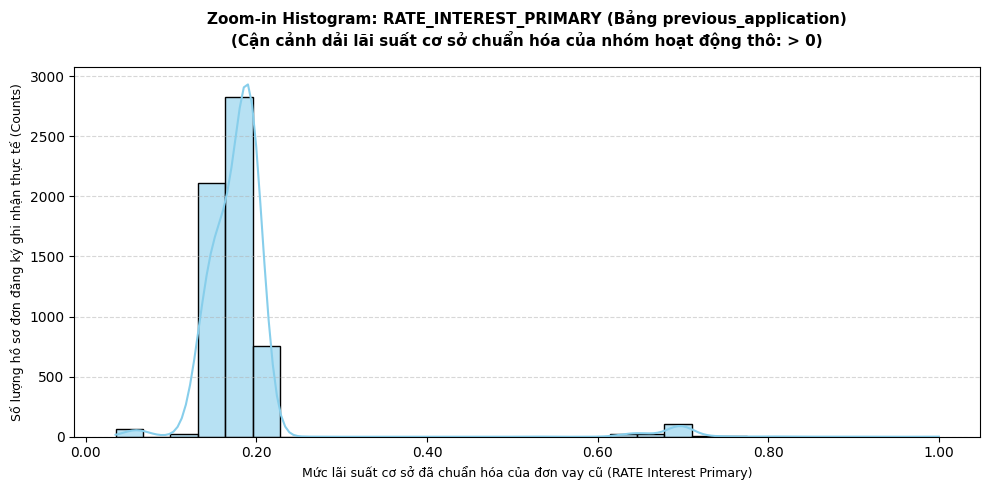

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN LÃI SUẤT CHUẨN HÓA (> 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'RATE_INTEREST_PRIMARY'

# Bước 1: LỘC TỐI HẬU - Loại bỏ hoàn toàn 99.64% dòng khuyết để bảo vệ tiến trình vẽ đồ thị
df_clean_base = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh giá trị lãi suất hợp lệ (lớn hơn 0)
# Giải phóng hoàn toàn trục tung Y khỏi điểm nghẽn khuyết thiếu dữ liệu
clean_data = df_clean_base[df_clean_base[target_col] > 0][target_col]

# Bước 3: Kiểm tra điều kiện dân số hoạt động trước khi vẽ để tránh lỗi trống mảng
if len(clean_data) > 0:
    # Bước 4: Tiến hành vẽ biểu đồ mật độ Histogram kết hợp đường cong KDE mượt mà
    sns.histplot(
        clean_data, 
        bins=30, 
        kde=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.6
    )
    
    # =========================================================================
    # CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ (> 0)
    # =========================================================================
    plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải lãi suất cơ sở chuẩn hóa của nhóm hoạt động thô: > 0)', 
              fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Mức lãi suất cơ sở đã chuẩn hóa của đơn vay cũ (RATE Interest Primary)', fontsize=9)
    plt.ylabel('Số lượng hồ sơ đơn đăng ký ghi nhận thực tế (Counts)', fontsize=9)

    # Định dạng nhãn trục hoành hiển thị tỷ lệ phần trăm thập phân rõ nét
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.2f}'))

    # Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
    plt.grid(axis='y', linestyle='--', alpha=0.5)
else:
    print(f"Cảnh báo hệ thống: Trường thuộc tính {target_col} không đủ dữ liệu hoạt động lớn hơn 0 để kết xuất đồ thị!")

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: RATE_INTEREST_PRIVILEGED
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 1,664,263 dòng | Tỷ lệ khuyết: 99.64%
-----------------------------------------------------------------


,RATE_INTEREST_PRIVILEGED
Count (Số lượng dòng thực tế),"5,951"
Mean (Trung bình),0.77
Median (Trung vị),0.84
Mode (Yếu vị),0.84
Std Dev (Độ lệch chuẩn),0.10
Min,0.37
Max,1.00
IQR (Tứ phân vị),0.14


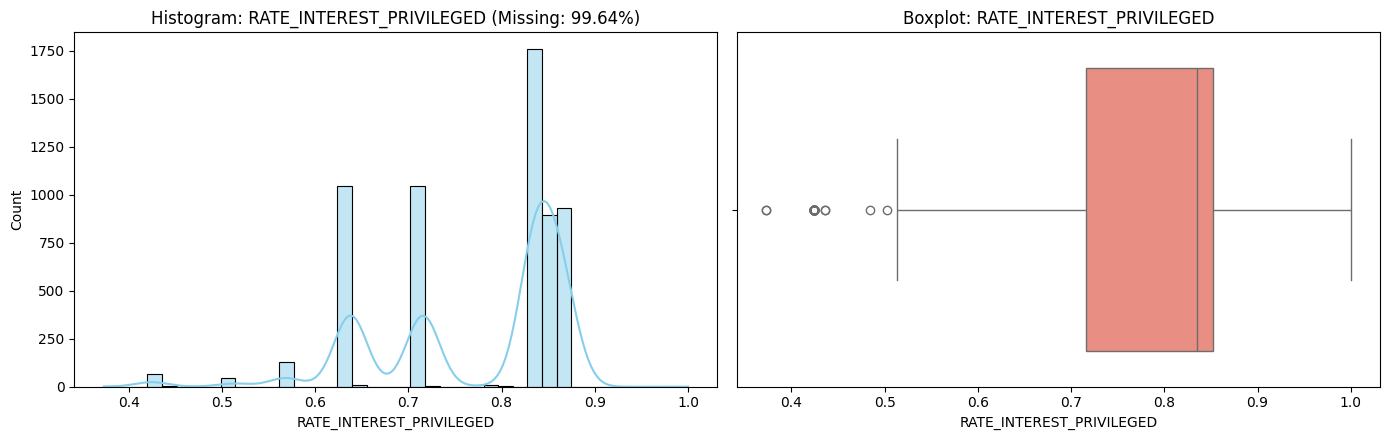

In [204]:
eda_numerical_feature(df_previous_application, 'RATE_INTEREST_PRIVILEGED')


📊 [CATEGORICAL] Feature: NAME_CONTRACT_STATUS | Unique Groups: 4
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,Counts,Percentage (%)
NAME_CONTRACT_STATUS,,
Approved,"1,036,781",62.07
Canceled,"316,319",18.94
Refused,"290,678",17.40
Unused offer,"26,436",1.58


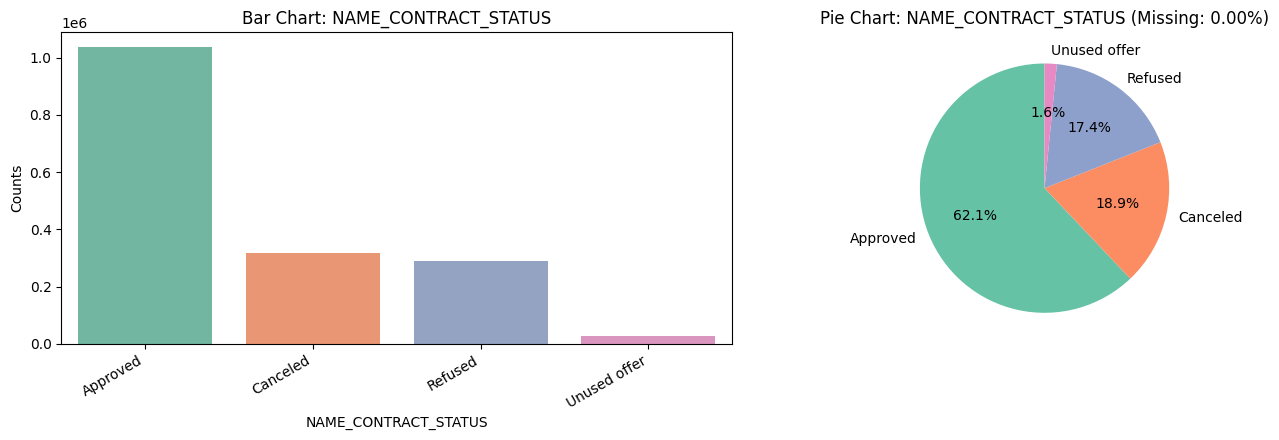

In [207]:
eda_categorical_feature(df_previous_application, 'NAME_CONTRACT_STATUS')


📈 [NUMERICAL] Feature: DAYS_DECISION
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 0 dòng | Tỷ lệ khuyết: 0.00%
-----------------------------------------------------------------


,DAYS_DECISION
Count (Số lượng dòng thực tế),"1,670,214"
Mean (Trung bình),-880.68
Median (Trung vị),-581.00
Mode (Yếu vị),-245.00
Std Dev (Độ lệch chuẩn),779.10
Min,"-2,922.00"
Max,-1.00
IQR (Tứ phân vị),"1,020.00"


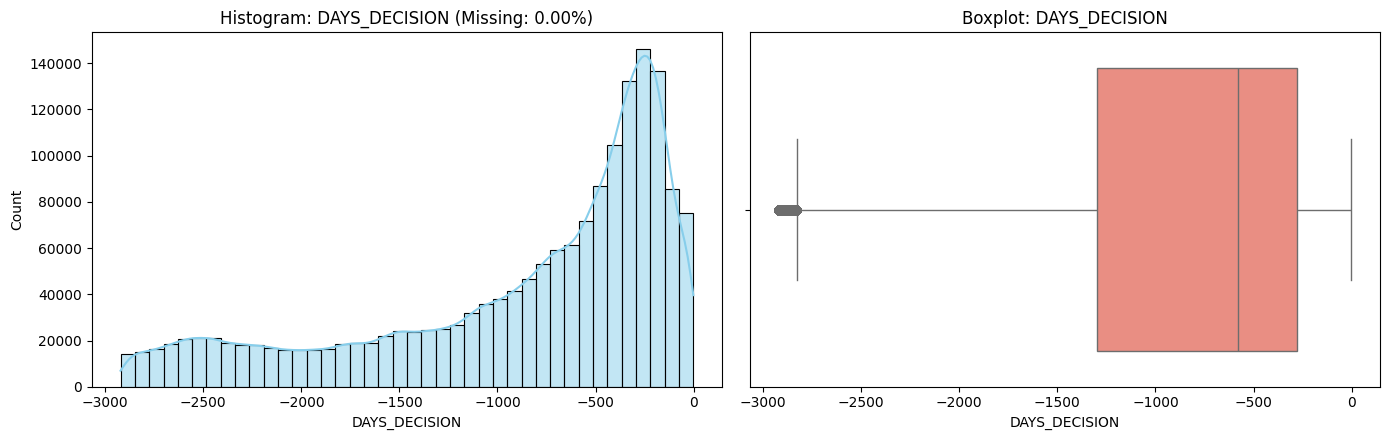

In [208]:
eda_numerical_feature(df_previous_application, 'DAYS_DECISION')


📈 [NUMERICAL] Feature: CNT_PAYMENT
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 372,230 dòng | Tỷ lệ khuyết: 22.29%
-----------------------------------------------------------------


,CNT_PAYMENT
Count (Số lượng dòng thực tế),"1,297,984"
Mean (Trung bình),16.05
Median (Trung vị),12.00
Mode (Yếu vị),12.00
Std Dev (Độ lệch chuẩn),14.57
Min,0.00
Max,84.00
IQR (Tứ phân vị),18.00


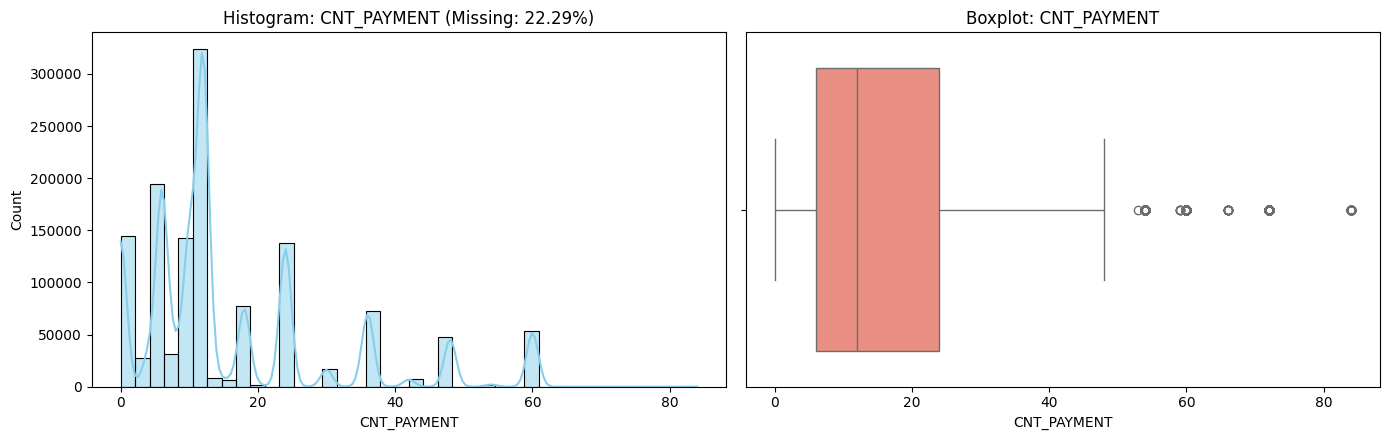

In [209]:
eda_numerical_feature(df_previous_application, 'CNT_PAYMENT')


📈 [NUMERICAL] Feature: DAYS_FIRST_DRAWING
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 673,065 dòng | Tỷ lệ khuyết: 40.30%
-----------------------------------------------------------------


,DAYS_FIRST_DRAWING
Count (Số lượng dòng thực tế),"997,149"
Mean (Trung bình),"342,209.86"
Median (Trung vị),"365,243.00"
Mode (Yếu vị),"365,243.00"
Std Dev (Độ lệch chuẩn),"88,916.12"
Min,"-2,922.00"
Max,"365,243.00"
IQR (Tứ phân vị),0.00


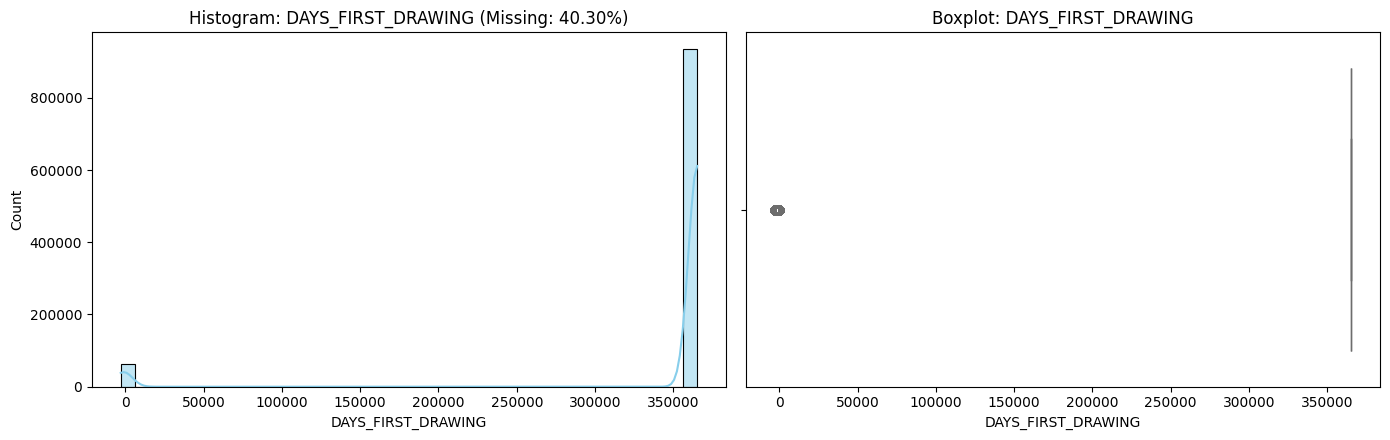

In [211]:
eda_numerical_feature(df_previous_application, 'DAYS_FIRST_DRAWING')


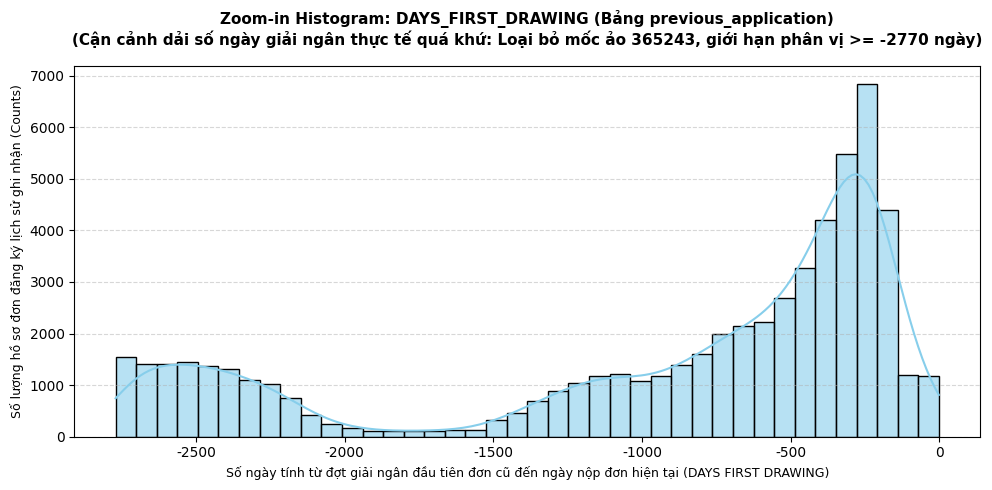

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN NGÀY GIẢI NGÂN ĐẦU TIÊN (< 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'DAYS_FIRST_DRAWING'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh ngày giải ngân thực tế trong quá khứ
# Loại bỏ triệt để điểm nghẽn của mốc giá trị ảo mã hóa hệ thống 365243
df_active_draw = df_non_na[df_non_na[target_col] < 0]

if len(df_active_draw) > 0:
    # Bước 3: Tính toán phân vị 5% trên nhóm số âm (tương đương phân vị 95% trị tuyệt đối) để tìm ngưỡng trần lùi về quá khứ
    lower_bound_5 = df_active_draw[target_col].quantile(0.05)
    
    # Bước 4: Cô lập dải dữ liệu phổ thông thực tế (từ mốc cận ngày nộp đơn về phân vị quá khứ)
    clean_data = df_active_draw[df_active_draw[target_col] >= lower_bound_5][target_col]
    
    # Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
    sns.histplot(
        clean_data, 
        bins=40, 
        kde=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.6
    )
    
    # =========================================================================
    # CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ
    # =========================================================================
    plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số ngày giải ngân thực tế quá khứ: Loại bỏ mốc ảo 365243, giới hạn phân vị >= {int(lower_bound_5)} ngày)', 
              fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Số ngày tính từ đợt giải ngân đầu tiên đơn cũ đến ngày nộp đơn hiện tại (DAYS FIRST DRAWING)', fontsize=9)
    plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

    # Định dạng nhãn trục hoành hiển thị số nguyên ngày âm rõ nét
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

    # Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
    plt.grid(axis='y', linestyle='--', alpha=0.5)
else:
    print(f"Cảnh báo hệ thống: Trường thuộc tính {target_col} không đủ dữ liệu giải ngân thực tế < 0 để kết xuất đồ thị!")

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()


📈 [NUMERICAL] Feature: DAYS_FIRST_DUE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 673,065 dòng | Tỷ lệ khuyết: 40.30%
-----------------------------------------------------------------


,DAYS_FIRST_DUE
Count (Số lượng dòng thực tế),"997,149"
Mean (Trung bình),"13,826.27"
Median (Trung vị),-831.00
Mode (Yếu vị),"365,243.00"
Std Dev (Độ lệch chuẩn),"72,444.87"
Min,"-2,892.00"
Max,"365,243.00"
IQR (Tứ phân vị),"1,217.00"


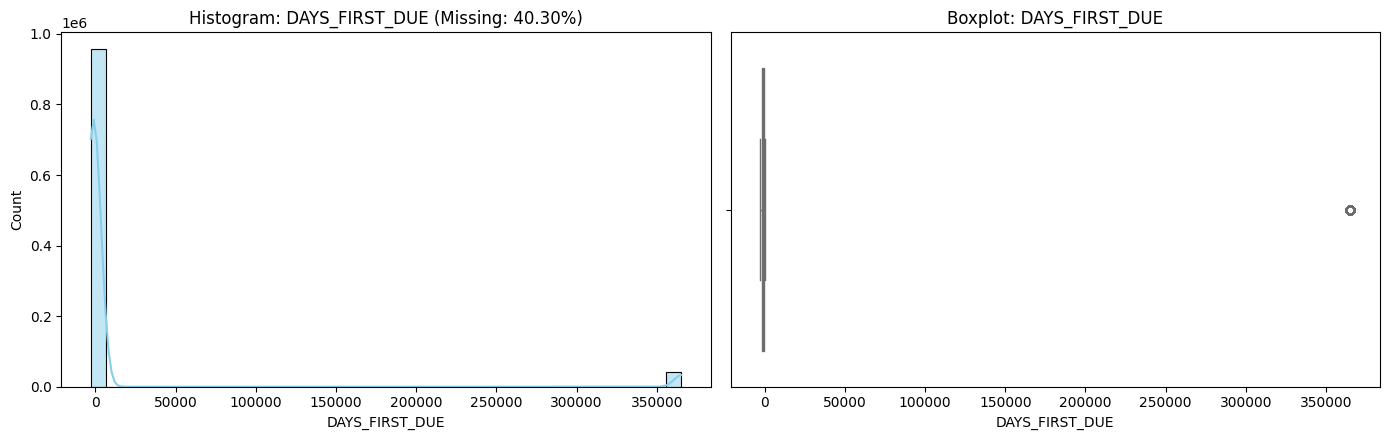

In [213]:
eda_numerical_feature(df_previous_application, 'DAYS_FIRST_DUE')


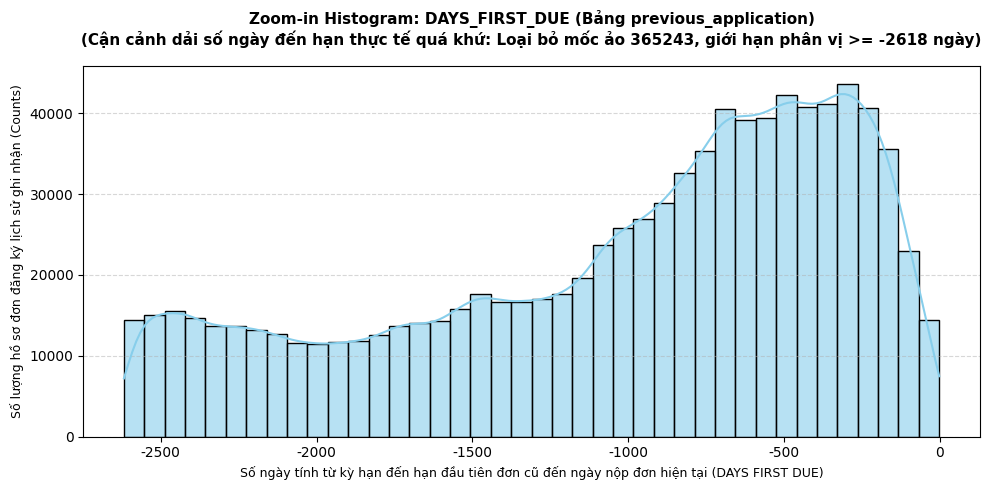

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN NGÀY ĐẾN HẠN ĐẦU TIÊN (< 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'DAYS_FIRST_DUE'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh ngày đến hạn thực tế trong quá khứ
# Loại bỏ triệt để điểm nghẽn của mốc giá trị ảo mã hóa hệ thống 365243
df_active_draw = df_non_na[df_non_na[target_col] < 0]

if len(df_active_draw) > 0:
    # Bước 3: Tính toán phân vị 5% trên nhóm số âm (tương đương phân vị 95% trị tuyệt đối) để tìm ngưỡng trần lùi về quá khứ
    lower_bound_5 = df_active_draw[target_col].quantile(0.05)
    
    # Bước 4: Cô lập dải dữ liệu phổ thông thực tế (từ mốc cận ngày nộp đơn về phân vị quá khứ)
    clean_data = df_active_draw[df_active_draw[target_col] >= lower_bound_5][target_col]
    
    # Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
    sns.histplot(
        clean_data, 
        bins=40, 
        kde=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.6
    )
    
    # =========================================================================
    # CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ
    # =========================================================================
    plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số ngày đến hạn thực tế quá khứ: Loại bỏ mốc ảo 365243, giới hạn phân vị >= {int(lower_bound_5)} ngày)', 
              fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Số ngày tính từ kỳ hạn đến hạn đầu tiên đơn cũ đến ngày nộp đơn hiện tại (DAYS FIRST DUE)', fontsize=9)
    plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

    # Định dạng nhãn trục hoành hiển thị số nguyên ngày âm rõ nét
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

    # Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
    plt.grid(axis='y', linestyle='--', alpha=0.5)
else:
    print(f"Cảnh báo hệ thống: Trường thuộc tính {target_col} không đủ dữ liệu đến hạn thực tế < 0 để kết xuất đồ thị!")

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: DAYS_LAST_DUE_1ST_VERSION
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 673,065 dòng | Tỷ lệ khuyết: 40.30%
-----------------------------------------------------------------


,DAYS_LAST_DUE_1ST_VERSION
Count (Số lượng dòng thực tế),"997,149"
Mean (Trung bình),"33,767.77"
Median (Trung vị),-361.00
Mode (Yếu vị),"365,243.00"
Std Dev (Độ lệch chuẩn),"106,857.03"
Min,"-2,801.00"
Max,"365,243.00"
IQR (Tứ phân vị),"1,371.00"


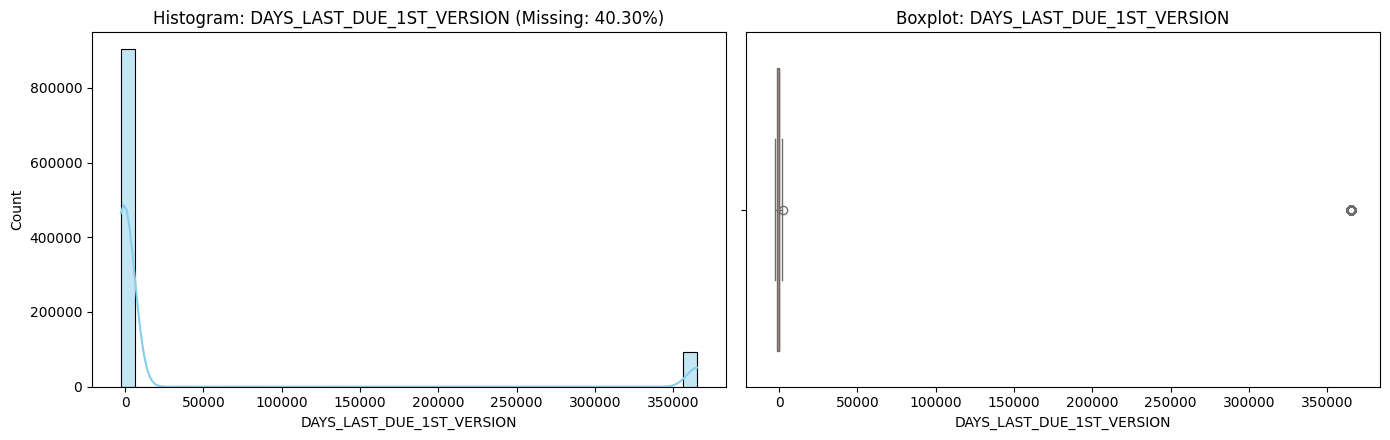

In [215]:
eda_numerical_feature(df_previous_application, 'DAYS_LAST_DUE_1ST_VERSION')


📈 [NUMERICAL] Feature: DAYS_LAST_DUE
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 673,065 dòng | Tỷ lệ khuyết: 40.30%
-----------------------------------------------------------------


,DAYS_LAST_DUE
Count (Số lượng dòng thực tế),"997,149"
Mean (Trung bình),"76,582.40"
Median (Trung vị),-537.00
Mode (Yếu vị),"365,243.00"
Std Dev (Độ lệch chuẩn),"149,647.42"
Min,"-2,889.00"
Max,"365,243.00"
IQR (Tứ phân vị),"1,240.00"


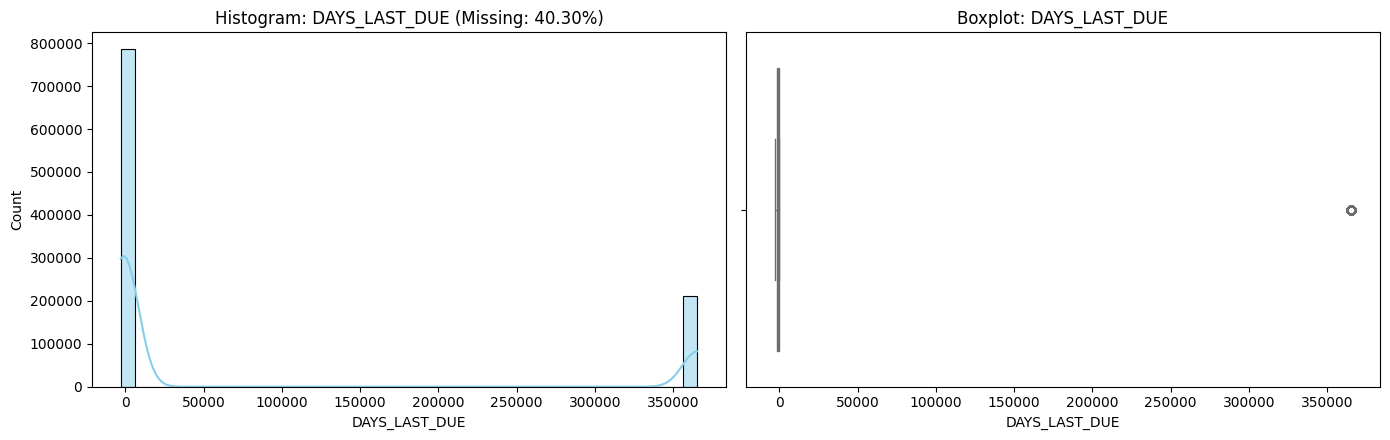

In [217]:
eda_numerical_feature(df_previous_application, 'DAYS_LAST_DUE')


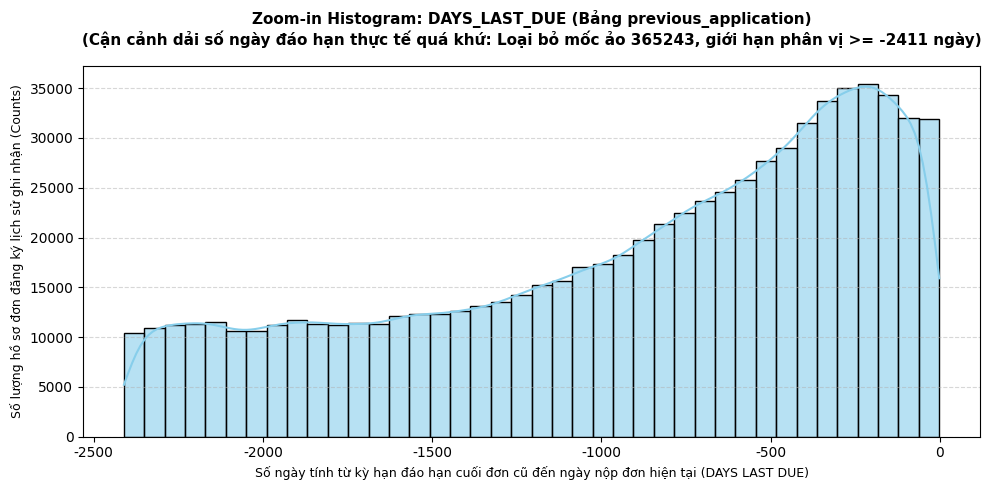

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN NGÀY ĐÁO HẠN KỲ CUỐI (< 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'DAYS_LAST_DUE'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh ngày đáo hạn thực tế trong quá khứ
# Loại bỏ triệt để điểm nghẽn của mốc giá trị ảo mã hóa hệ thống 365243
df_active_draw = df_non_na[df_non_na[target_col] < 0]

if len(df_active_draw) > 0:
    # Bước 3: Tính toán phân vị 5% trên nhóm số âm (tương đương phân vị 95% trị tuyệt đối) để tìm ngưỡng trần lùi về quá khứ
    lower_bound_5 = df_active_draw[target_col].quantile(0.05)
    
    # Bước 4: Cô lập dải dữ liệu phổ thông thực tế (từ mốc cận ngày nộp đơn về phân vị quá khứ)
    clean_data = df_active_draw[df_active_draw[target_col] >= lower_bound_5][target_col]
    
    # Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
    sns.histplot(
        clean_data, 
        bins=40, 
        kde=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.6
    )
    
    # =========================================================================
    # CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ
    # =========================================================================
    plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số ngày đáo hạn thực tế quá khứ: Loại bỏ mốc ảo 365243, giới hạn phân vị >= {int(lower_bound_5)} ngày)', 
              fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Số ngày tính từ kỳ hạn đáo hạn cuối đơn cũ đến ngày nộp đơn hiện tại (DAYS LAST DUE)', fontsize=9)
    plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

    # Định dạng nhãn trục hoành hiển thị số nguyên ngày âm rõ nét
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

    # Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
    plt.grid(axis='y', linestyle='--', alpha=0.5)
else:
    print(f"Cảnh báo hệ thống: Trường thuộc tính {target_col} không đủ dữ liệu đáo hạn thực tế < 0 để kết xuất đồ thị!")

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()

📈 [NUMERICAL] Feature: DAYS_TERMINATION
⚠️ [CẢNH BÁO TRỐNG]: Dòng khuyết: 673,065 dòng | Tỷ lệ khuyết: 40.30%
-----------------------------------------------------------------


,DAYS_TERMINATION
Count (Số lượng dòng thực tế),"997,149"
Mean (Trung bình),"81,992.34"
Median (Trung vị),-499.00
Mode (Yếu vị),"365,243.00"
Std Dev (Độ lệch chuẩn),"153,303.52"
Min,"-2,874.00"
Max,"365,243.00"
IQR (Tứ phân vị),"1,226.00"


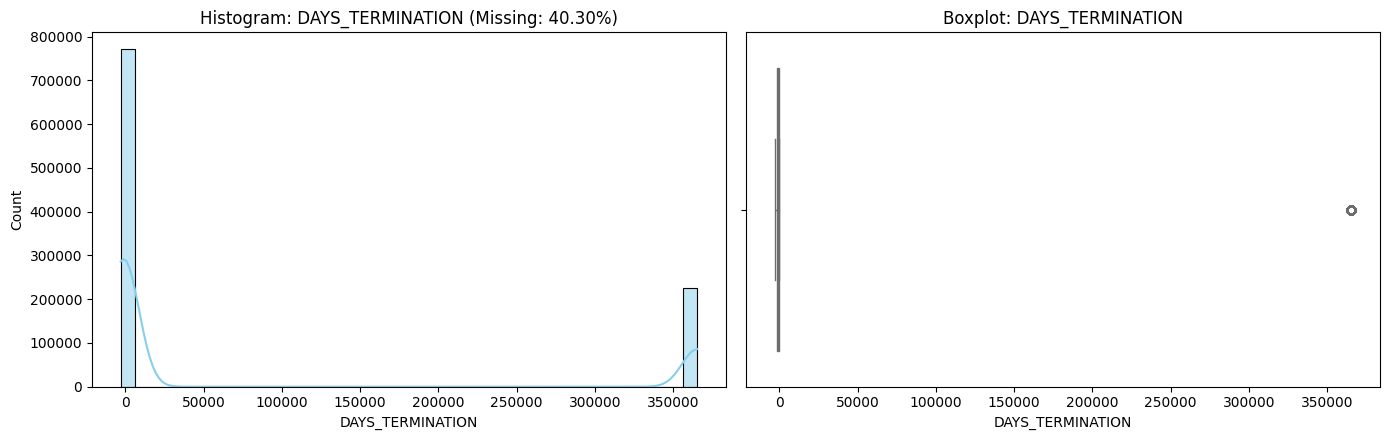

In [219]:
eda_numerical_feature(df_previous_application, 'DAYS_TERMINATION')


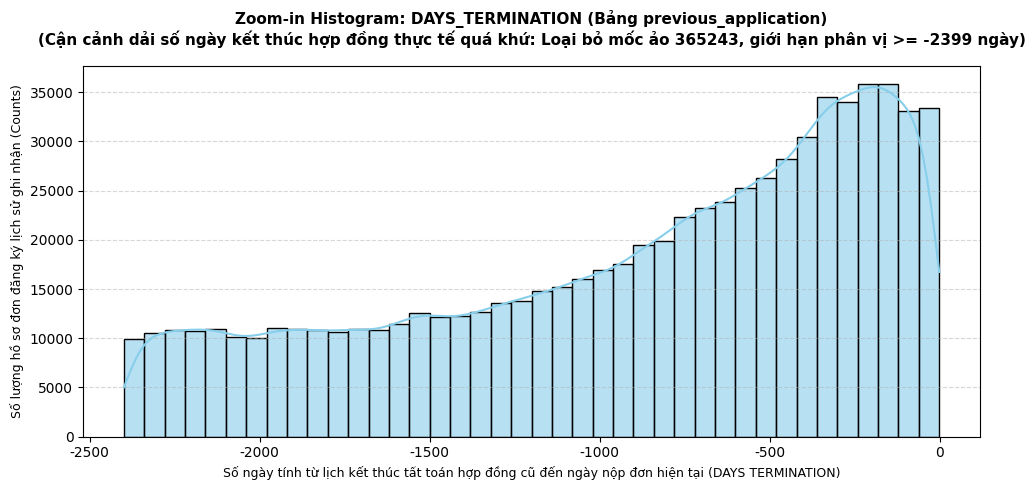

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# ĐOẠN CODE ĐỘC LẬP TRẦN - VẼ BIỂU ĐỒ ZOOM-IN NGÀY KẾT THÚC HỢP ĐỒNG CŨ (< 0)
# BẢNG DỮ LIỆU THỰC TẾ: df_previous_application
# =========================================================================

# Định cấu hình kích thước khung hình tiêu chuẩn đồng bộ cho đồ án
plt.figure(figsize=(10, 5))

# Xác định chính xác tên cột mục tiêu theo cấu trúc bảng của Trí
target_col = 'DAYS_TERMINATION'

# Bước 1: Loại bỏ các giá trị khuyết (NaN) để bảo vệ tiến trình tính toán phân vị không bị lỗi
df_non_na = df_previous_application[df_previous_application[target_col].notna()]

# Bước 2: BÓC TÁCH LÕI - Lọc cô lập các bản ghi thực sự phát sinh ngày kết thúc thực tế trong quá khứ
# Loại bỏ triệt để điểm nghẽn của mốc giá trị ảo mã hóa hệ thống 365243
df_active_draw = df_non_na[df_non_na[target_col] < 0]

if len(df_active_draw) > 0:
    # Bước 3: Tính toán phân vị 5% trên nhóm số âm (tương đương phân vị 95% trị tuyệt đối) để tìm ngưỡng trần lùi về quá khứ
    lower_bound_5 = df_active_draw[target_col].quantile(0.05)
    
    # Bước 4: Cô lập dải dữ liệu phổ thông thực tế (từ mốc cận ngày nộp đơn về phân vị quá khứ)
    clean_data = df_active_draw[df_active_draw[target_col] >= lower_bound_5][target_col]
    
    # Bước 5: Tiến hành vẽ biểu đồ mật độ Histogram tích hợp đường cong KDE mượt mà
    sns.histplot(
        clean_data, 
        bins=40, 
        kde=True, 
        color='skyblue', 
        edgecolor='black', 
        alpha=0.6
    )
    
    # =========================================================================
    # CẤU HÌNH THẨM MỸ HỆ TRỤC CHUYÊN NGHIỆP VÀ CHUẨN HÓA NHÃN CHỮ
    # =========================================================================
    plt.title(f'Zoom-in Histogram: {target_col} (Bảng previous_application)\n(Cận cảnh dải số ngày kết thúc hợp đồng thực tế quá khứ: Loại bỏ mốc ảo 365243, giới hạn phân vị >= {int(lower_bound_5)} ngày)', 
              fontsize=11, fontweight='bold', pad=15)
    plt.xlabel('Số ngày tính từ lịch kết thúc tất toán hợp đồng cũ đến ngày nộp đơn hiện tại (DAYS TERMINATION)', fontsize=9)
    plt.ylabel('Số lượng hồ sơ đơn đăng ký lịch sử ghi nhận (Counts)', fontsize=9)

    # Định dạng nhãn trục hoành hiển thị số nguyên ngày âm rõ nét
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

    # Bật lưới lưới ngang mờ hỗ trợ đối chiếu tần suất cột dữ liệu
    plt.grid(axis='y', linestyle='--', alpha=0.5)
else:
    print(f"Cảnh báo hệ thống: Trường thuộc tính {target_col} không đủ dữ liệu kết thúc thực tế < 0 để kết xuất đồ thị!")

# Tối ưu hóa khoảng biên đồ thị sạch chữ
plt.tight_layout()
plt.show()